# [실습] 배치 기준 브리핑 — 계절 강도와 차분 횟수 결정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 0. 오늘 할 일과 데이터 — 서울 공유자전거 8,760시간

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">시계열 예측 · 첫날</div>
<h1 style="color:#000000;margin:10px 0">이 수요, 그대로 예측 모형에 쓸 수 있는가</h1>
<div style="font-size:1.05em;color:#656565">1년 8,760시간의 시간당 수요에서 계절성의 크기를 측정하고, 정상성 검정으로 예측 모형에 쓸 수 있는 상태인지 판정합니다</div>
</div>

## 오늘 할 일

오늘부터 여러분은 **서울 공유자전거 운영팀의 수요예측 담당자**입니다. 첫날 팀장이 자료 링크와 함께 두 가지를 요청했습니다. **"다음 주 배치 계획을 근거로 짜려고 합니다. 이 수요에 어떤 계절성이 있는지, 그리고 이 데이터를 그대로 예측 모형에 쓸 수 있는지부터 확인해 주십시오."**

첫 물음은 배치 기준을 정하는 **탐색**이고, 둘째 물음은 그 기준을 산출할 모형이 이 계열을 받아들일 수 있는지 확인하는 **정상성 검정**입니다. 오늘은 미션 3개와 과제 1개로 두 답을 만듭니다. 수업에서는 미션 1·2 와 정리를, 방과후에는 미션 3 과 과제를 진행합니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/edemand-1.png" width="640" height="288"/>
<p align="center"><em>▲ 2014년 빅토리아주 30분 단위 전력 수요 — 촘촘한 세로선이 하루 단위 되풀이이고 1월 폭염과 7월 난방의 최댓값이 연 단위 변동이다. 서울 공유자전거 시간당 대여 수요도 하루·1주일·1년 단위의 되풀이가 겹쳐 있다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., otexts.com/fpp3)</em></p>

## 오늘의 데이터

**Seoul Bike Sharing Demand** 는 UCI 머신러닝 저장소가 공개한 서울 공유자전거의 시간당 대여 기록입니다. 한 행이 한 시간이고 2017년 12월 1일 0시부터 2018년 11월 30일 23시까지 8,760행 × 14열입니다. 대여 수요 `count` 에 기상 관측이 함께 있습니다.

`count` 는 실제로 일어난 대여이고, 자전거가 없어 빌리지 못한 수요는 기록되지 않습니다. 그래서 정점 시각의 값은 수요의 아래쪽 경계로 읽습니다.

<img src="https://commons.wikimedia.org/wiki/Special:FilePath/Bicycle-sharing%20station%20in%20Seoul%20Sinseol-dong.jpg?width=1600" width="640" height="539"/>
<p align="center"><em>▲ 지하철 신설동역 출입구 옆 공유자전거 정류소 — 오늘 다룰 8,760시간의 대여 기록이 이런 정류소에서 한 시간에 한 행씩 기록되었다 (출처: Wikimedia Commons, Bicycle-sharing station in Seoul Sinseol-dong)</em></p>

읽어 들일 때 드러나지 않게 어긋나는 함정이 4개 있어 「준비 셀」이 미리 차단합니다.

| 함정 | 그대로 두면 | 「준비 셀」이 하는 일 |
|---|---|---|
| 컬럼 이름에 든 도 기호 `°` | UTF-8 로 읽으면 글자가 깨진다 | `encoding="cp1252"` 로 읽는다 |
| 날짜 `01/12/2017` | 1월 12일로 읽힌다. 실제는 12월 1일이다 | `format="%d/%m/%Y"` 를 지정한다 |
| 이름으로 컬럼 찾기 | 도 기호 때문에 환경마다 어긋난다 | 컬럼 이름을 위치 기반으로 교체한다 |
| 빠진 시각·중복 시각 | 한 행이 1시간이라는 조건이 깨져 시차 24 로 비교하는 값이 24시간 전 값이 아니게 된다 | 등간격인지 확인해 화면에 출력한다 |

**휴무 295시간의 0 은 수요 0 이 아니라 관측이 없다는 뜻입니다.** 삭제·0 유지·보정 3가지 가운데 보정을 골랐습니다. 원본 `count` 는 오늘의 탐색과 검정이 쓰고, 보정 계열 `demand` 는 둘째 날 모형 학습이 처음 씁니다.

휴무 시각은 1주일 전 같은 시각의 값으로, 1주일 전도 휴무이면 1주일 뒤 같은 시각의 값으로 채웁니다. 둘째 단계가 채우는 시각은 2018년 10월 9일 24시간뿐이고, 이 24시간과 값을 가져오는 10월 16일은 둘째 날부터 다섯째 날까지 채점하는 11월 17일 이후 구간보다 앞이라 그 구간의 채점에는 미래 정보가 들어가지 않습니다. 다만 여섯째 날의 평가 구간은 9월 1일부터여서 두 날짜가 그 안에 들어가고, 매일 갱신하는 운영에서는 10월 9일에 10월 16일 관측이 아직 없으므로 과거 값으로 채우는 규칙이 필요합니다.

## 이 노트북을 쓰는 법

**미션마다 코드 셀이 2개입니다.** 앞의 **「준비 셀」**은 그 미션이 쓸 변수를 만들고, 뒤의 **「PROMPT 셀」**은 `PROMPT` 를 내 말로 작성해 AI 튜터에게 지시합니다. AI 코드는 `# --- 여기부터 AI 코드 ---` 행 아래에 삽입됩니다.

**미션 1 과 미션 3, 과제는 아래 5단계를 그대로 따릅니다.**

1. 미션 글을 읽습니다.
2. 「준비 셀」을 실행합니다. 이 셀은 수정하지 않습니다.
3. 만들 것대로 `PROMPT` 를 내 말로 작성합니다.
4. 셀을 클릭한 채 「Claude 도우미」에 "위 PROMPT 대로 코드를 써 줘" 를 요청하고 「이 셀에 넣기」 → ▶ 로 실행합니다.
5. 출력되는 채점 결과를 확인하고, 「❌」 이면 힌트대로 `PROMPT` 를 고쳐 4단계를 다시 합니다.

| 무엇 | 어떻게 |
|---|---|
| 실행 환경 | CPU 로 충분하다 |
| 먼저 실행할 셀 | 맨 위 설치·폰트 셀 한 번. 뒤쪽 미션만 따로 열어도 그 셀 하나면 된다 |
| 채점 | 「PROMPT 셀」을 실행하는 순간 그 셀의 출력 아래에 채점 결과가 출력된다. 기준을 충족하면 완성본 풀이가 열리고, 못 미치면 어긋난 항목과 AI 튜터에 보낼 질문이 나온다 |
| 채점 준비 (Colab) | 연결된 뒤 코드 패널 머리의 「채점 준비됨」이 표시되면 시작한다. 채점 결과가 출력되지 않으면 그 「채점 준비됨」을 누른다 |
| 채점 준비 (내려받은 노트북) | 맨 위의 접힌 `[채점]` 셀을 한 번 ▶ 실행한 다음 시작한다. 코드는 접혀 있어도 실행된다 |
| 예측 질문 | 코드를 실행하기 전에 결과를 하나 고르는 항목이다. 점수와 무관하고, 고른 답은 채점이 여는 완성본 해석에서 확인한다 |
| 퀴즈 | 미션이 끝날 때마다 한 문항이다. 앞 셀의 출력과 그림을 확인해야 풀린다 |
| 막혔을 때 | 같은 말을 되풀이하지 말고 `PROMPT` 에 빠진 조건을 하나 추가한다. 그래도 안 되면 요구를 처음부터 다시 정리해 새 메시지로 보낸다 |

In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "statsmodels==0.14.6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
import warnings                                   # 검정 함수의 경고는 판정 근거라 남긴다
warnings.simplefilter("ignore", FutureWarning)    # 버전 안내만 끈다
warnings.simplefilter("ignore", DeprecationWarning)
warnings.filterwarnings("ignore", "Glyph")        # 폰트에 없는 글자 안내

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다

import matplotlib.dates as mdates


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 60.2 MB/s eta 0:00:00
사용 폰트: NanumGothic | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


In [ ]:
#@title [채점] 이 셀을 먼저 실행하세요 (한 번이면 됩니다)
#   미션의 「PROMPT 셀」을 실행하면 그 셀의 출력과 그림을 붙잡아 실행 결과에 채점 결과를 찍습니다.
#   통과하면 그 자리에서 완성본 풀이가 열리고, 아니면 항목별 힌트와 튜터에 보낼 질문이 나옵니다.
#   읽지 않고 실행만 해도 됩니다 — 기대값과 풀이는 이 셀에만 있고 「PROMPT 셀」에는 없습니다.
import base64
import glob
import io
import json
import re
import shutil
import subprocess
import sys

import matplotlib.font_manager as fm      # 아래 폰트 자급이 쓴다
import matplotlib.pyplot as plt


def _font_bootstrap():
    """한글 폰트 자급 — 맨 위 설치·폰트 셀을 건너뛰어도 그래프의 한글이 깨지지 않게.

    LMS 는 이 셀만 자동 실행하므로 폰트 준비도 여기서 한 번 더 한다. 설치·폰트 셀과 같은
    규칙이라 둘 다 돌아도 결과가 같고, apt-get 이 없는 자리(로컬)에서는 곧바로 지나간다.
    설치한 ttf 는 `addfont` 로 폰트 목록에 직접 넣는다 — 넣지 않으면 목록이 옛 상태라
    한글이 □ 로 깨진다(2026-09-09 Colab 실사고).
    """
    try:
        cands = ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"]
        installed = {f.name for f in fm.fontManager.ttflist}
        if not any(n in installed for n in cands) and shutil.which("apt-get"):
            subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"],
                           check=False, timeout=120)
        # 설치는 파일만 만든다 — 이미 떠 있는 폰트 목록에 addfont 로 넣어야 이름이 보인다.
        # (설치를 건너뛴 자리도 나눔 ttf 가 이미 있으면 이 줄들만으로 잡힌다.)
        for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):
            try: fm.fontManager.addfont(_p)
            except Exception: pass
        try: fm._get_font.cache_clear()
        except Exception: pass
        installed = {f.name for f in fm.fontManager.ttflist}
        _font = next((n for n in cands if n in installed), "DejaVu Sans")
        plt.rcParams["font.family"] = _font
        plt.rcParams["axes.unicode_minus"] = _font in {"Pretendard", "DejaVu Sans"}
    except Exception:
        print("한글 폰트를 못 찾아 그래프 글자가 깨질 수 있습니다 —"
              " 맨 위 설치·폰트 셀을 실행하세요")


_font_bootstrap()


def _dec_json(s):                          # base64(JSON) → 값. 리스트는 원래 튜플이라 되돌립니다
    def _t(v):
        return ({k: _t(x) for k, x in v.items()} if isinstance(v, dict)
                else tuple(_t(x) for x in v) if isinstance(v, list) else v)
    return _t(json.loads(base64.b64decode(s).decode("utf-8")))


# 채점 기준 — base64(JSON), 통과 판정에만 쓴다
_ANS = _dec_json(
               "eyJtMSI6eyJ2YWx1ZXMiOnsi6rOE7KCIIOqwleuPhCDigJQgOOyblCA3NDTsi5zqsIQgwrcg7KO86riwIDI0IjpbMC42NDMsMC42"
               "NTNdLCLqs4TsoIgg6rCV64+EIOKAlCDsnbwg6rOE7Je0IDM2NeydvCDCtyDso7zquLAgNyI6WzAuMDg0LDAuMDk0XX0sInBsb3Qi"
               "Onsia2luZCI6ImJhciIsIm4iOjIsIuy2leudvOuyqCI6dHJ1ZX19LCJtMiI6eyJ2YWx1ZXMiOnsiQURGIOqygOygle2GteqzhOuf"
               "iSDigJQg7JuQ67O4IOyLnOqwhCDqs4Tsl7QiOlstNi45NiwtNi45M10sIktQU1Mg6rKA7KCV7Ya16rOE65+JIOKAlCDsm5Drs7gg"
               "7Iuc6rCEIOqzhOyXtCI6WzcuOTksOC4wMl0sIuqzhOygiOywqOu2hCDtmp/siJggRCI6WzEsMSwi7ZqMIl19LCJwbG90Ijp7Imtp"
               "bmQiOiJiYXIiLCJuIjo0OCwieW1heCI6WzAuODksMC45Ml0sIuy2leudvOuyqCI6dHJ1ZX19LCJtMyI6eyJ2YWx1ZXMiOnsi6rOE"
               "7KCI7LCo67aEIO2bhCBLUFNTIOqygOygle2GteqzhOufiSI6WzAuMDA1LDAuMDEyXSwi6rOE7KCI7LCo67aEIO2bhCDsi5zssKgg"
               "MjQg7J6Q6riw7IOB6rSAIjpbLTAuNDcsLTAuNDVdfSwicGxvdCI6eyJraW5kIjoiYmFyIiwibiI6WzI0LDQwMF0sIm5fYXhlcyI6"
               "Miwi7LaV652867KoIjp0cnVlfX0sIuqzvOygnCI6eyJ2YWx1ZXMiOnsi7J28IOqzhOyXtCAx7LCoIOywqOu2hCDigJQg7Iuc7LCo"
               "IDEg7J6Q6riw7IOB6rSAIjpbLTAuNSwtMC40OV0sIuydvCDqs4Tsl7QgMeywqCDssKjrtoQg4oCUIO2RnOykgO2OuOywqCI6Wzg2"
               "MDAsODY1MCwi64yAL+ydvCJdLCLssKjrtoQg7KCEIOydvCDqs4Tsl7Qg4oCUIEtQU1Mg7Ya16rOE65+JIjpbMS44LDEuODhdLCIx"
               "7LCoIOywqOu2hCDsnbwg6rOE7Je0IOKAlCBLUFNTIO2GteqzhOufiSI6WzAuMTAxLDAuMTA0XX0sInBsb3QiOnsia2luZCI6Imxp"
               "bmUiLCJuX3NlcmllcyI6MSwibl9heGVzIjozLCLstpXrnbzrsqgiOnRydWV9fX0=")
_REVEAL = {                                # 완성본 풀이 — base64, 통과할 때만 디코드해 인쇄합니다
    "m1": ("8J+UkyDrr7jshZggMSDsmYTshLHrs7gg4oCUIEFJIOy9lOuTnCDtlokg7JWE656Y7JeQIOyeiOyWtOyVvCDtlaAg7L2U65Oc7J6F64uI64ukCgrilqAg7J"
           "20IOy9lOuTnOulvCDrtoDrpbgg7ZSE66Gs7ZSE7Yq4IOyYiAoKICAgIOydtOuvuCDrp4zrk6TslrTsoLgg7J6I64qUIGRmLCBhdWcsIGRhaWx5IOulvCDq"
           "t7jrjIDroZwg7JOw6rOgIOuLpOyLnCDrp4zrk6Tsp4DripQg66eQ7JWEIOykmCDigJQgYXVnIOuKlCA47JuUIO2VnCDri6wgNzQ07Iuc6rCE7J24IOyLnO"
           "qwhCDqs4Tsl7TsnbTqs6AgZGFpbHkg64qUIO2VmOujqCDtlanqs4TroZwg66eM65OgCiAgICAzNjXsnbwg6rOE7Je07J207JW8LiDrkZAg6rOE7Je07JeQ"
           "IFNUTCDrtoTtlbTrpbwg7ZWcIOuyiOyUqSDsoIHsmqntlbQg7KSYIOKAlCBhdWcg64qUIHBlcmlvZCDrpbwgMjQg66GcLCBkYWlseSDripQgcGVyaW9kIO"
           "ulvCA3IOuhnCDrkZDqs6Ag65GYIOuLpCByb2J1c3Qg66W8IOy8nOyEnC4KICAgIOu2hO2VtCDqsrDqs7zsl5DshJwg6rOE7KCIIOqwleuPhOulvCDqs4Ts"
           "grDtlbQg7KSYLiDsnpTssKjsnZgg67aE7IKw7J2EIOqzhOygiCDshLHrtoTqs7wg7J6U7LCo66W8IOuNlO2VnCDqsoPsnZgg67aE7IKw7Jy866GcIOuCmO"
           "uIiCDrkqQgMSDsl5DshJwg67qAIOqwkuydtOqzoCwg7J2M7IiY6rCAIOuCmOyYpOuptCAwIOycvOuhnCDsnpjrnbwg7KSYLgogICAg6re4IOuLpOydjCAi"
           "6rOE7KCIIOqwleuPhCDigJQgOOyblCA3NDTsi5zqsIQgwrcg7KO86riwIDI0ID0gKOyIq+yekCkiIOyZgCAi6rOE7KCIIOqwleuPhCDigJQg7J28IOqzhO"
           "yXtCAzNjXsnbwgwrcg7KO86riwIDcgPSAo7Iir7J6QKSIg66W8IOyGjOyImOygkCDslYTrnpggNOyekOumrOq5jOyngCDtlZwg7ZaJ7JSpLAogICAgIuuR"
           "kCDqsJIg7J296riwID0gKOusuOyepSkiIOuPhCDtlZwg7ZaJIHByaW50IO2VtCDspJguIOq3uCDtlonsl5DripQg65GQIOqwkuydhCDqsIHqsIEg7Lih7K"
           "CVIOq1rOqwhOqzvCDtlajqu5gg7KCB7Ja0IOykmC4g7ZaJIOydtOumhOydgCDrlLDsmLTtkZwg7JWIIOq4gOyekCDqt7jrjIDroZwg7I2oIOykmC4g6re4"
           "656Y7ZSE64qUIOuUsSDtlZwg7J6l66eMIOKAlCDrkZAg6rOE7KCIIOqwleuPhOulvCDshLjroZwg66eJ64yAIOuRkAogICAg6rCc66GcIOuCmOuegO2eiC"
           "Dqt7jrpqzqs6Ag66eJ64yAIOydtOumhOydgCDjgIzso7zquLAgMjQgKDjsm5QgNzQ07Iuc6rCEKeOAjSDqs7wg44CM7KO86riwIDcgKOydvCDqs4Tsl7Qg"
           "MzY17J28KeOAjSDroZwg64us6rOgIOyEuOuhnOy2lSDrspTsnITrpbwgMCDsl5DshJwgMSDroZwg65GQ6rOgIOuRkCDstpXsl5Ag652867Ko7J2EIOuLrO"
           "yVhCDspJguCgogICAgZGVmIHNlYXNvbmFsX3N0cmVuZ3RoKHJlcyk6ICAgICAgICAgICAgICAgICAgICAgICMgRl9TID0gMSAtIFZhcijsnpTssKgpIC8g"
           "VmFyKOqzhOygiCDshLHrtoQgKyDsnpTssKgpCiAgICAgICAgcmV0dXJuIG1heCgwLjAsIDEgLSByZXMucmVzaWQudmFyKCkgLyAocmVzLnNlYXNvbmFsIC"
           "sgcmVzLnJlc2lkKS52YXIoKSkKCiAgICBzdGxfaG91ciA9IFNUTChhdWcsIHBlcmlvZD0yNCwgcm9idXN0PVRydWUpLmZpdCgpICAgICAjIDjsm5QgNzQ0"
           "7Iuc6rCEIMK3IOyjvOq4sCAyNAogICAgc3RsX2RheSA9IFNUTChkYWlseSwgcGVyaW9kPTcsIHJvYnVzdD1UcnVlKS5maXQoKSAgICAgIyDsnbwg6rOE7J"
           "e0IDM2NeydvCDCtyDso7zquLAgNwogICAgZnNfaG91ciA9IHNlYXNvbmFsX3N0cmVuZ3RoKHN0bF9ob3VyKQogICAgZnNfZGF5ID0gc2Vhc29uYWxfc3Ry"
           "ZW5ndGgoc3RsX2RheSkKCiAgICBwcmludChmIuqzhOygiCDqsJXrj4Qg4oCUIDjsm5QgNzQ07Iuc6rCEIMK3IOyjvOq4sCAyNCA9IHtmc19ob3VyOi40Zn"
           "0iKQogICAgcHJpbnQoZiLqs4TsoIgg6rCV64+EIOKAlCDsnbwg6rOE7Je0IDM2NeydvCDCtyDso7zquLAgNyA9IHtmc19kYXk6LjRmfSIpCiAgICBwcmlu"
           "dChmIuuRkCDqsJIg7J296riwID0gOOyblCA3NDTsi5zqsITsnZgg7KO86riwIDI0IOuKlCB7ZnNfaG91cjouNGZ9LCAiCiAgICAgICAgICBmIuydvCDqs4"
           "Tsl7QgMzY17J287J2YIOyjvOq4sCA3IOydgCB7ZnNfZGF5Oi40Zn0g7J6F64uI64ukLiIKICAgICAgICAgIGYiIOy4oeyglSDqtazqsITsnbQg64us6528"
           "IOuRkCDqsJLsnYQg64KY64iE7Ja0IOuwsOyImOuhnCDsnb3sp4Ag7JWK7Iq164uI64ukIikKCiAgICBmaWcsIGF4ID0gcGx0LnN1YnBsb3RzKGZpZ3Npem"
           "U9KDgsIDMuNCkpCiAgICBheC5iYXIoWyLso7zquLAgMjQgKDjsm5QgNzQ07Iuc6rCEKSIsICLso7zquLAgNyAo7J28IOqzhOyXtCAzNjXsnbwpIl0sIFtm"
           "c19ob3VyLCBmc19kYXldLAogICAgICAgICAgIGNvbG9yPVsiIzAwQTlGNCIsICIjQjNCM0IzIl0pCiAgICBheC5zZXRfeWxpbSgwLCAxKQogICAgYXguc2"
           "V0X3hsYWJlbCgi6rOE7KCIIOyjvOq4sCIpCiAgICBheC5zZXRfeWxhYmVsKCLqs4TsoIgg6rCV64+EICgwIOyXkOyEnCAxIOyCrOydtCkiKQogICAgcGx0"
           "LnNob3coKQoK7ZW07ISdCgotIOyYiOyDgSAz6rCcIOqwgOyatOuNsCDri7XsnYAg65GQIOuyiOynuOyduCDjgIzso7zquLAgMjQg6rCAIDAuNSDrpbwg64"
           "SY6rOgLCDso7zquLAgNyDsnYAgMC4xIOyXkCDrqrsg66+47Lmc64uk44CNIOyeheuLiOuLpC4g7KO86riwIDI0IOqwgCAwLjY0Nzgg7J206528IDjsm5Qg"
           "NzQ07Iuc6rCE7JeQ7IScIOy2lOyEuOulvCDsoJzsmbjtlZwg67OA64+Z7J2YIOygiOuwmOydhCDrhJjqsowg7ISk66qF7ZWY6rOgLCDso7zquLAgNyDsnY"
           "AgMC4wODk0IOudvCDsnbwg7IiY7JqU7JeQ7IScIDAuMSDsl5Ag66q7IOuvuOy5qeuLiOuLpC4g7Jik64qY7J2YIOyyqyDqsrDroaDsnbQg7Jes6riw7JeQ"
           "7IScIOuCmOyYteuLiOuLpC4g6rOE7KCI7ISx7J2AIOyalOydvOydtCDslYTri4jrnbwg7Iuc6rCB7JeQIOyeiOqzoCwg65GY7Ke4IOuCoCDsmIjsuKEg66"
           "qo7ZiV7J2YIOqzhOygiCDso7zquLDrpbwgbSA9IDI0IOuhnCDqs6DrpbTripQg6re86rGw6rCAIOydtCDrkZAg7Iir7J6Q7J6F64uI64ukLgotIHJvYnVz"
           "dD1UcnVlIOulvCDrubzrqbQg6rCZ7J2AIOqzhOyCsOydtCAwLjg1NzMg6rO8IDAuMzMzOCDroZwg7Luk7KeR64uI64ukLiDqsJXqsbQg7Ji17IWY7J2AIO"
           "2PreyasOuCmCDtnLTrrLQg6rCZ7J2AIOy2qeqyqeydhCDstpTshLjqsIAg7JWE64uI6528IOyelOywqOuhnCDrs7TrgrTripQg7ISk7KCV7J206528LCDr"
           "gYTrqbQg6re4IOy2qeqyqeydtCDstpTshLjsmYAg6rOE7KCIIOyEseu2hOyXkCDtlajqu5gg65Ok7Ja06rCAIOqzhOygiOydmCDruYTspJHsnbQg6rO864"
           "yA7Y+J6rCA65Cp64uI64ukLiDrkZAg7Zi47LacIOuqqOuRkCDsvKAg7LGE66GcIOqzhOyCsO2VtOyVvCDrkZAg6rCS7J20IOqwmeydgCDsobDqsbTsl5Ds"
           "hJwg64KY7Ji164uI64ukLgotIOuRkCDqsJLsnYAg7KeR6rOEIOuLqOychOqwgCDri6Trpbgg6rOE7Je07JeQ7IScIOuCmOyZlOyKteuLiOuLpC4g7KO86r"
           "iwIDI0IOyqveydgCDsi5zqsIQg64uo7JyEIDc0NOqwnOydtOqzoCDso7zquLAgNyDsqr3snYAg7ZWY66OoIO2VqeqzhCAzNjXqsJzsnoXri4jri6QuIOy4"
           "oeyglSDqtazqsITsnYQgMeuFhOycvOuhnCDrp57strAg7J6s66m0IOydtOuhoOydmCDjgIw0LiDqs4TsoIgg6rCV64+EOiDso7zquLAgMjTsmYAg7KO86r"
           "iwIDfsnZgg67mE6rWQ44CN6rCAIOyggeydgCAwLjU3MiDrjIAgMC4wODkg7J206rOgLCDsmKTripgg7Jqw66as6rCAIOy4oeygle2VnCAwLjY0Nzgg7J2A"
           "IDjsm5QgNzQ07Iuc6rCEIOq1rOqwhOydmCDqsJLsnoXri4jri6QuIDjsm5TsnYQg6rOg66W4IOydtOycoOuKlCDqt7gg64us7J2YIO2ctOustOqwgCAw7I"
           "uc6rCE7J206528IOyxhOyatCDqsJLsnbQg6rOE7KCIIOyEseu2hOyXkCDtj6ztlajrkJjsp4Ag7JWK6riwIOuVjOusuOyeheuLiOuLpC4g65GQIOqwkuyd"
           "gCDsp5Hqs4Qg64uo7JyE6rCAIOuLpOultOuvgOuhnCDrgpjriITslrQg67Cw7IiY66GcIOydveyngCDslYrqs6AsIOuztOqzoOyEnOyXkOuPhCDqsIHqsI"
           "Eg6re4IOuLqOychOyXkOyEnCDqt7gg7KO86riw6rCAIOyEpOuqhe2VnCDruYTspJHsnLzroZwg7Lih7KCVIOq1rOqwhOqzvCDtlajqu5gg7KCB7Iq164uI"
           "64ukLgotIOqwmeydgCDsi5zqsIQg6rOE7Je0IDgsNzYw7Iuc6rCEIO2VmOuCmOyXkCDso7zquLAgMjQg7JmAIOyjvOq4sCAxNjgg7J2EIO2VqOq7mCDsoI"
           "HsmqntlbQg7Lih7KCV7ZWY66m0IDAuNjczNyDrjIAgMC4yNzg1IOqwgCDrkKnri4jri6QuIOyjvOq4sCAxNjgg7J2AIOyjvCDri6jsnIQg65CY7ZKA7J20"
           "66W8IOyLnOqwhCDri6jsnITroZwg7IS8IOqwkig3IMOXIDI0KeyeheuLiOuLpC4g7KO86riw66W8IOyXrOufvyDtlZzqurzrsojsl5Ag7KCB7Jqp7ZWY64"
           "qUIOydtCDrtoTtlbTrpbwgTVNUTChtdWx0aXBsZSBTVEwp7J2065286rOgIO2VmOupsCwgU1RMIOydhCDso7zquLDrp4jri6Qg65CY7ZKA7J207ZW0IOyg"
           "geyaqe2VmOuKlCDtmZXsnqXtjJDsnoXri4jri6QuIOydtOuhoOydmCAwLjU3MiDripQg7KO86riwIDI0IOunjCDri6jrj4XsnLzroZwg67aE7ZW07ZWcIO"
           "qwkuydtOqzoCwg7Jes6riwIDAuNjczNyDsnYAg7KO86riwIDI0IOyZgCDso7zquLAgMTY4IOydhCDtlajqu5gg67aE7ZW07ZWcIOqwkuyeheuLiOuLpC4K"
           "LSA47JuUIOu2hO2VtOydmCDsnpTssKjsl5DripQg7JWE7KeBIOq1rOyhsOqwgCDrgqjslYQg7J6I7Iq164uI64ukLiDqs4TsoIgg7ISx67aE7J20IOKIkj"
           "g5MS42IOuMgOyXkOyEnCArMSw2NjAuNSDrjIDquYzsp4Ag6rec7LmZ7KCB7Jy866GcIOyYpOultOuCtOumrOuKlCDtlZztjrgsIOyelOywqOydmCDsnpDq"
           "uLDsg4HqtIDsnYAg7Iuc7LCoIDEg7JeQ7IScIDAuNzUwOSwg7Iuc7LCoIDI0IOyXkOyEnCAwLjIzNTYg7Jy866GcIOuCqOyVhCDsnojsirXri4jri6QuIO"
           "y2lOyEuOyZgCDqs4TsoIgg7ISx67aE7J2EIOu2hOumrO2VmOqzoOuPhCDqtazsobDqsIAg64Ko7JWY64uk64qUIOucu+ydtOqzoCwg6re4IOuCqOydgCDq"
           "tazsobDrpbwg65GY7Ke4IOuCoCDsmIjsuKEg66qo7ZiV7J20IOyEpOuqhe2VmOqyjCDrkKnri4jri6QuCgrsvZTrk5zqsIAg64u17J2EIOunjOuTnOuKlC"
           "DrsKnsi50g4oCUIEZfUyDsnZgg67aE66qo7JeQ7IScIOy2lOyEuOulvCDsoJzsmbjtlojquLAg65WM66y47JeQKOqzhOygiCDshLHrtoTqs7wg7J6U7LCo"
           "66eMIOuCqOq4tOuLpCkg7LaU7IS4IO2BrOq4sOqwgCDri6Trpbgg65GQIOu2hO2VtOulvCDqsJnsnYAg6riw7KSA7Jy866GcIOu5hOq1kO2VoCDsiJgg7J"
           "6I6rOgLCByb2J1c3Q9VHJ1ZSDqsIAg7Lap6rKp7J2EIOyelOywqCDsqr3snLzroZwg67O064K0IOqzhOygiOydmCDruYTspJHsnbQg6rO864yA7Y+J6rCA"
           "65CY7KeAIOyViuqyjCDtlanri4jri6Qu"),
    "m2": ("8J+UkyDrr7jshZggMiDsmYTshLHrs7gg4oCUIEFJIOy9lOuTnCDtlokg7JWE656Y7JeQ7IScIOyImOygle2VtOyVvCDtlojrjZgg6rOz7J2AIO"
           "2MkOyglSDrrLjqtazrpbwg66eM65Oc64qUIOuRkCDtlonsnoXri4jri6QKCuKWoCDsnbQg7L2U65Oc66W8IOu2gOuluCDtlITroaztlITtirgg"
           "7JiICgogICAg7KCE7J6EIOuLtOuLueyekCDsvZTrk5zsl5DshJwg6rKA7KCVIOuRkCDqsJzrpbwg67aA66W064qUIOuRkCDtlonsnYAg6re464"
           "yA66GcIOuRkOqzoCwg7YyQ7KCVIOusuOq1rOulvCDrp4zrk5zripQg65GQIO2WieydtCDti4DroLjsnLzri4gg6rOg7LOQIOykmC4gQURGIOyZ"
           "gCBLUFNTIOuKlCDqt4DrrLTqsIDshKTsnbQg7ISc66GcIOuwmOuMgOudvAogICAg6rCZ7J2AIOOAjHAg6rCAIOyekeycvOuptCDsoJXsg4HjgI"
           "0g6rec7LmZ7J2EIOuRmCDri6Tsl5Ag7JO4IOyImCDsl4bslrQg4oCUIEFERiDripQg6reA66y06rCA7ISk7J20IOOAjOuLqOychOq3vOydtCDs"
           "nojri6Qo67mE7KCV7IOBKeOAjSDrnbzshJwgcCDqsIAg7Jyg7J2Y7IiY7KSA67O064ukIOyekeycvOuptCDsoJXsg4Eg7Kq9IOymneqxsOydtO"
           "qzoCwKICAgIEtQU1Mg64qUIOq3gOustOqwgOyEpOydtCDjgIzsoJXsg4HsnbTri6TjgI0g65287IScIHAg6rCAIOyekeycvOuptCDruYTsoJXs"
           "g4Eg7Kq9IOymneqxsOyVvC4g6re465+s64uIIOuRkCDqsoDsoJXsnZgg6riw6rCBIOyXrOu2gOunjCDrlLDroZwg67CY7ZmY7ZWY6rKMIOqzoO"
           "y5mOqzoCwg6rCBIO2WieyXkCDthrXqs4Trn4nqs7wgcOqwkuqzvCDtlajqu5gKICAgIOOAjOustOyKqCDqsIDshKTsnYQg6riw6rCB7ZaI64qU"
           "7KeALCDqt7jrnpjshJwg7Ja064qQIOyqvSDspp3qsbDsnbjsp4DjgI0g66W8IOyggeyWtCDspJguIO2WiSDsnbTrpoTsnYAgIkFERiDqsoDsoJ"
           "XthrXqs4Trn4kg4oCUIOybkOuzuCDsi5zqsIQg6rOE7Je0IiDqs7wgIktQU1Mg6rKA7KCV7Ya16rOE65+JIOKAlCDsm5Drs7gg7Iuc6rCEIOqz"
           "hOyXtCIKICAgIOuhnCDquIDsnpAg6re464yA66GcIOyNqCDspJguIOq3uOumrOqzoCDrkZAg6riw6rCBIOyXrOu2gOydmCDrhKQg7KGw7ZWp7J"
           "2EIOq3uOuMgOuhnCDsobDqsbTrrLjsnLzroZwg7Jiu6rKoIO2MkOyglSDrrLjqtazsmYAg6rOE7KCI7LCo67aEIO2an+yImCBEIOulvCDsoJXt"
           "lbQg7KSYIOKAlCDrkZgg64ukIOq4sOqwgeydtOuptCDrhLfsp7gg7KGw7ZWp7J206528CiAgICDtjJDsoJXsnYAg44CM6rWs7KGw6rCAIOuCqO"
           "ydjOOAjeydtOqzoCBEIOuKlCAxIO2ajCwgQURGIOunjCDquLDqsIHsnbTrqbQg7LKr7Ke4IOyhsO2VqeydtOudvCDjgIzsoJXsg4Eg7ZWp7J2Y"
           "44CN7J206rOgIEQg64qUIDAg7ZqMLCBLUFNTIOunjCDquLDqsIHsnbTrqbQg65GY7Ke4IOyhsO2VqeydtOudvCDjgIzruYTsoJXsg4Eg7ZWp7J"
           "2Y44CN7J206rOgCiAgICBEIOuKlCAwIO2ajCwg65GYIOuLpCDruYTquLDqsIHsnbTrqbQg7IWL7Ke4IOyhsO2VqeydtOudvCDjgIzspp3qsbAg"
           "67aA7KGx44CN7J206rOgIEQg64qUIDAg7ZqM7JW8LiDsm5Drs7gg7Iuc6rCEIOqzhOyXtCBob3VybHlfYyDroZwg6re4IO2MkOygleydhCDsi6"
           "TtlontlZjqs6AgIuy1nOyihSDtjJDsoJUgOiAo66y46rWsKSIg7JmAICLqs4TsoIjssKjrtoQg7Zqf7IiYIEQgPSAo7Iir7J6QKSDtmowiCiAg"
           "ICDrpbwg7ZWcIO2WieyUqSBwcmludCDtlbQg7KSYLiDqt7jrprzsnYAg7KCE7J6E7J6QIOqyg+ydhCDqt7jrjIDroZwg65GQ6rOgIOyLnOywqC"
           "AyNCDsmYAgNDgg66eJ64yA66eMIOyDieydhCDri6zrpqztlbQg7KSYIOKAlCDsi5zssKggMSDrtoDthLAgNDgg6rmM7KeA7J2YIOyekOq4sOyD"
           "geq0gOydhCDrp4nrjIAgNDjqsJzroZwKICAgIOq3uOumrOqzoCAwIOyXkCDqsIDroZzshKDqs7wgwrExLjk2L+KImlQg7JyE7LmY7J2YIOqwgO"
           "uhnCDsoJDshKAg65GQIOqwnOulvCDquIvqs6Ag65GQIOy2leyXkCDrnbzrsqjsnYQg64uoIOq3uOumvOydtOyVvC4KCiAgICBkZWYgc3RhdGlv"
           "bmFyaXR5X3JlcG9ydCh4LCBhbHBoYT1BTFBIQSk6CiAgICAgICAgc3RhdF9hZGYsIHBfYWRmID0gYWRmdWxsZXIoeCwgYXV0b2xhZz0iQUlDIi"
           "lbOjJdCiAgICAgICAgc3RhdF9rcHNzLCBwX2twc3MgPSBrcHNzKHgsIHJlZ3Jlc3Npb249ImMiLCBubGFncz0iYXV0byIpWzoyXQogICAgICAg"
           "IGFkZl9yZWogPSBwX2FkZiA8IGFscGhhICAgICAgICAgICMg6reA66y06rCA7ISkICLri6jsnITqt7wg7J6I7J2MKOu5hOygleyDgSkiIOydhC"
           "DquLDqsIEg4oaSIOygleyDgSDsqr0g7Kad6rGwCiAgICAgICAga3Bzc19yZWogPSBwX2twc3MgPCBhbHBoYSAgICAgICAgIyDqt4DrrLTqsIDs"
           "hKQgIuygleyDgSIg7J2EIOq4sOqwgSDihpIg67mE7KCV7IOBIOyqvSDspp3qsbAgKEFERiDsmYAg67CY64yAKQogICAgICAgIHByaW50KGYiQU"
           "RGIOqygOygle2GteqzhOufiSDigJQg7JuQ67O4IOyLnOqwhCDqs4Tsl7QgPSB7c3RhdF9hZGY6LjRmfSAgIHDqsJIgPSB7cF9hZGY6LjRnfSAg"
           "ICIKICAgICAgICAgICAgICBmIuKGkiDri6jsnITqt7wg6rCA7ISkIHsn6riw6rCBID0g7KCV7IOBIOyqvSDspp3qsbAnIGlmIGFkZl9yZWogZW"
           "xzZSAn67mE6riw6rCBID0g7Kad6rGwIOu2gOyhsSd9IikKICAgICAgICBwcmludChmIktQU1Mg6rKA7KCV7Ya16rOE65+JIOKAlCDsm5Drs7gg"
           "7Iuc6rCEIOqzhOyXtCA9IHtzdGF0X2twc3M6LjRmfSAgIHDqsJIgPSB7cF9rcHNzOi40Z30gICAiCiAgICAgICAgICAgICAgZiLihpIg7KCV7I"
           "OBIOqwgOyEpCB7J+q4sOqwgSA9IOu5hOygleyDgSDsqr0g7Kad6rGwJyBpZiBrcHNzX3JlaiBlbHNlICfruYTquLDqsIEgPSDspp3qsbAg67aA"
           "7KGxJ30iKQogICAgICAgIHJldHVybiBhZGZfcmVqLCBrcHNzX3JlagoKICAgIGFkZl9yZWosIGtwc3NfcmVqID0gc3RhdGlvbmFyaXR5X3JlcG"
           "9ydChob3VybHlfYykKCiAgICBpZiBhZGZfcmVqIGFuZCBrcHNzX3JlajogICAgICAgICAgICAgICAgICMg64SkIOyhsO2VqeydhCDqt7jrjIDr"
           "oZwg7KGw6rG066y47Jy866GcIOyYruq4tOuLpAogICAgICAgIHZlcmRpY3QsIEQgPSAi64S37Ke4IOyhsO2VqSDigJQg65GYIOuLpCDquLDqsI"
           "EsIOq1rOyhsOqwgCDrgqjsnYwiLCAxCiAgICBlbGlmIGtwc3NfcmVqOgogICAgICAgIHZlcmRpY3QsIEQgPSAi65GY7Ke4IOyhsO2VqSDigJQg"
           "QURGIOu5hOq4sOqwgcK3S1BTUyDquLDqsIEsIOu5hOygleyDgSDtlansnZgiLCAwCiAgICBlbGlmIGFkZl9yZWo6CiAgICAgICAgdmVyZGljdC"
           "wgRCA9ICLssqvsp7gg7KGw7ZWpIOKAlCBBREYg6riw6rCBwrdLUFNTIOu5hOq4sOqwgSwg7KCV7IOBIO2VqeydmCIsIDAKICAgIGVsc2U6CiAg"
           "ICAgICAgdmVyZGljdCwgRCA9ICLshYvsp7gg7KGw7ZWpIOKAlCDrkZgg64ukIOu5hOq4sOqwgSwg7Kad6rGwIOu2gOyhsSIsIDAKCiAgICBwcm"
           "ludChmIuy1nOyihSDtjJDsoJUgOiB7dmVyZGljdH0iKQogICAgcHJpbnQoZiLqs4TsoIjssKjrtoQg7Zqf7IiYIEQgPSB7RH0g7ZqMIikKCiAg"
           "ICByID0gYWNmKGhvdXJseV9jLCBubGFncz00OClbMTpdICAgICAgICAgICMgWzE6XSDroZwg64qYIDEg7J24IOyLnOywqCAwIOydhCDsoJzqsb"
           "DtlZzri6QKICAgIGNvbG9ycyA9IFsiIzAwQTlGNCIgaWYgayBpbiAoMjQsIDQ4KSBlbHNlICIjQjNCM0IzIiBmb3IgayBpbiByYW5nZSgxLCA0"
           "OSldCiAgICBiYW5kID0gMS45NiAvIG5wLnNxcnQobGVuKGhvdXJseV9jKSkgICAgICMg7YyQ7KCV7ISgIMKxMS45Ni/iiJpUCiAgICBmaWcsIG"
           "F4ID0gcGx0LnN1YnBsb3RzKGZpZ3NpemU9KDEwLCAzLjQpKQogICAgYXguYmFyKG5wLmFyYW5nZSgxLCA0OSksIHIsIGNvbG9yPWNvbG9ycywg"
           "d2lkdGg9MC44KSAgICMg6rCV7KGw64qUIOuNp+q3uOumrOyngCDrp5Dqs6Ag7IOJ7Jy866GcCiAgICBheC5heGhsaW5lKDAsIGNvbG9yPSIjNz"
           "U3NTc1IiwgbHc9MC44KQogICAgYXguYXhobGluZShiYW5kLCBjb2xvcj0iIzc1NzU3NSIsIGx3PTAuOCwgbHM9Ii0tIikKICAgIGF4LmF4aGxp"
           "bmUoLWJhbmQsIGNvbG9yPSIjNzU3NTc1IiwgbHc9MC44LCBscz0iLS0iKQogICAgYXguc2V0X3hsYWJlbCgi7Iuc7LCoICjsi5zqsIQpIikKIC"
           "AgIGF4LnNldF95bGFiZWwoIuyekOq4sOyDgeq0gCIpCiAgICBwbHQuc2hvdygpCgrtlbTshJ0KCi0g7JiI7IOBIDPqsJwg6rCA7Jq0642wIOuL"
           "teydgCDrkZAg67KI7Ke47J24IOOAjO2MkOyglSDrrLjqtazrpbwg66eM65Oc64qUIOuRkCDtlokg4oCUIOuRkCDqsoDsoJXsnYQg65iR6rCZ7J"
           "20ICJwIOqwgCDsnpHsnLzrqbQg7KCV7IOBIiDsnLzroZwg7J297Ja07ISc44CNIOyeheuLiOuLpC4g6rKA7KCV7J2EIOu2gOultOuKlCDrkZAg"
           "7ZaJ6rO8IOq3uOumvOydgCDsoITsnoQg7L2U65Oc6rCAIOydtOuvuCDrp57qsowg7J6R7ISx7ZaI6rOgLCDti4DrprAg6rKD7J2AIHAg6rCS7J"
           "2EIOqysOuhoOycvOuhnCDrsJTqvrjripQg65GQIO2Wieu/kOyeheuLiOuLpC4KLSBBREYg7Ya16rOE65+J7J2AIOKIkjYuOTQ3MChwIOuKlCAx"
           "ZS05IOyImOykgCnsnbTrnbwg64uo7JyE6re8IOqwgOyEpOydtCDquLDqsIHrkJjqs6AsIEtQU1Mg7Ya16rOE65+J7J2AIDguMDA1MSDsnbTrnb"
           "wg7KCV7IOBIOqwgOyEpOuPhCDquLDqsIHrkKnri4jri6QuIEtQU1Mg7J2YIDUlIOyehOqzhOqwkuydtCAwLjQ2MyDsnbTrr4DroZwgMTcuM+uw"
           "sOyeheuLiOuLpC4g7J6E6rOE6rCS7J2EIOqyqOyasCDstIjqs7ztlZwg6rCS7J20IOyVhOuLiOudvCDtgazqsowg67KX7Ja064KcIOqwkuyehe"
           "uLiOuLpC4KLSDrkZgg64ukIOq4sOqwgeydgCDrqqjsiJzsnbQg7JWE64uI6528IO2VnCDrrLjsnqXsnLzroZwg7J297Z6Z64uI64ukLiBBREYg"
           "6rCAIOuLqOychOq3vCDqsIDshKTsnYQg6riw6rCB7ZaI7Jy864uIIOyYpOywqO2VreydtCDriITsoIHrkJjslrQg7IiY7KSA7J20IOydtOuPme"
           "2VmOuKlCDruYTsoJXsg4EsIOqzpyDtmZXrpaDsoIEg7LaU7IS464qUIOyVhOuLjOuNsCwg6re466CH64uk6rOgIOygleyDgeydtOudvOqzoOuP"
           "hCDtlaAg7IiYIOyXhuuLpOuKlCDrnLvsnoXri4jri6QuIOustOyXh+ydtCDsoJXsg4HshLHsnYQg6rmo64qU7KeA64qUIOuvuOyFmCAxIOydtC"
           "DsnbTrr7gg7Lih7KCV7ZaI7Iq164uI64ukLiDqs4TsoIgg6rCV64+E6rCAIDAuNjQ3OCDsnbgg7KO86riwIDI0IOyeheuLiOuLpC4g7Iuc6rCB"
           "66eI64ukIO2Pieq3oOydtCDri6TrpbTrqbQg44CM7Y+J6reg7J20IOyLnOygkOyXkCDsnZjsobTtlZjsp4Ag7JWK64qU64uk44CNIOuKlCDsob"
           "DqsbTsnbQg6re464yA66GcIOq5qOyngOq4sCDrlYzrrLjsl5AsIO2VhOyalO2VnCDsspjrpqzripQg66CI67KoIOywqOu2hOydtCDslYTri4jr"
           "nbwgMjTsi5zqsIQg6rOE7KCI7LCo67aEIDHtmozsnbTqs6AgRCA9IDEg7J6F64uI64ukLgotIOyekOq4sOyDgeq0gCDqt7jrprzrj4Qg6rCZ7J"
           "2AIOyCrOyLpOydhCDrs7Tsl6wg7KSN64uI64ukLiDsnpDquLDsg4HqtIDsnYAg7Iuc7LCoIDEg7JeQ7IScIDAuOTAzNCDroZwg7Iuc7J6R7ZW0"
           "IOykhOyWtOuTpOuLpOqwgCDsi5zssKggMjQg7JeQ7IScIDAuNjgxMyDsnLzroZwg64uk7IucIOy7pOyngOqzoCwg6re466a8IOuwliDsi5zssK"
           "ggMTY4KDHso7zsnbwp7JeQ7ISc64+EIDAuNjU1OSDsnoXri4jri6QuIO2VmOujqCDrkqTsmYAgMeyjvOydvCDrkqTsnZgg6rCZ7J2AIOyLnOqw"
           "geqzvCDsl6zsoITtnogg7IOB6rSA7J20IO2BrOuLpOuKlCDrnLvsnbTqs6AsIOyLnOywqCAyNCDsmYAgMTY4IOyXkOyEnCDsnpDquLDsg4HqtI"
           "DsnbQg64uk7IucIOy7pOyngOuKlCDqsoPsnbQg6rOE7KCI7ISx7J2YIOymneqxsOyeheuLiOuLpC4g7YyQ7KCV7ISgIMKxMS45Ni/iiJpUIOuK"
           "lCBUID0gOCw3NjAg7J206528IMKxMC4wMjEg7J206rOgLCDrp4nrjIAgNDjqsJzqsIAg66qo65GQIOq3uCDrsJTquaXsqr3sl5Ag7J6I7Iq164"
           "uI64ukLgotIOyghOyehCDri7Tri7nsnpAg7L2U65Oc6rCAIOychO2XmO2VnCDsnbTsnKDripQgM+qwgOyngOyeheuLiOuLpC4g7Jik66WY6rCA"
           "IOuwnOyDne2VmOyngCDslYrqs6AsIOqysOuhoOydtCDqt7jrn7Trk6/tlZjqs6AsIOygle2Zle2eiCDrsJjrjIDsnoXri4jri6QuIOydtOuMgO"
           "uhnCDsgqzsmqntlZjrqbQg6rOE7KCI7ISx7J20IOyCtOyVhCDsnojripQg7JuQ6rOE7Je07J2EIOq3uOuMgOuhnCDrqqjtmJXsl5Ag7IKs7Jqp"
           "7ZWY6rKMIOuQmOqzoCwg67CY64yA66GcIOydtOuvuCDsspjrpqzqsIAg64Gd64KcIOqzhOyXtOyXkOuKlCDssKjrtoTsnYQg7ZWcIOuyiCDrjZ"
           "Qg7KCB7Jqp7ZWY6rKMIOuQqeuLiOuLpC4g7Ya16rOE65+JIOuRkCDqsJzripQg66ee6rKMIOuCmOyYpOuvgOuhnCDqsJLsnYQg7ZmV7J247ZWY"
           "64qUIOqygOyCsOycvOuhnOuKlCDrsJzqsqzrkJjsp4Ag7JWK7Iq164uI64ukLiDqt4DrrLTqsIDshKQg67Cp7Zal7J2EIOy2nOugpSDrrLjqta"
           "zsl5Ag66qF7Iuc7ZWY64qUIOy2nOugpSDtmJXsi53snbQg7J20IOyYpOulmOulvCDrsJzqsqztlZjqsowg7ZWp64uI64ukLgoK7L2U65Oc6rCA"
           "IOuLteydhCDrp4zrk5zripQg67Cp7IudIOKAlCBw6rCSIDwgYWxwaGEg652864qUIOqwmeydgCDsobDqsbTsnbQg7JWeIO2WieyXkOyEnOuKlC"
           "DjgIzri6jsnITqt7wg6rCA7ISk7J2EIOq4sOqwge2WiOuLpCA9IOygleyDgSDsqr3jgI0sIOuStyDtlonsl5DshJzripQg44CM7KCV7IOBIOqw"
           "gOyEpOydhCDquLDqsIHtlojri6QgPSDruYTsoJXsg4Eg7Kq944CNIOydhCDrnLvtlanri4jri6QuIOuRkCDtlonsnZgg6rKw6rO866W8IOusuO"
           "q1rOuhnCDrsJTqvrjripQg6rOz7JeQ7IScIOuwqe2WpeydhCDqtazrtoTtlbTslbwg64SkIOyhsO2VqSDqsIDsmrTrjbAg66ee64qUIOyhsO2V"
           "qeydtCDsoJXtlbTsp4Dqs6AgRCDqsIAg66ee64qUIOqwkuydtCDrkKnri4jri6QuIOq3uOumvCDsqr3sl5DshJzripQgYWNmKGhvdXJseV9jLC"
           "BubGFncz00OClbMTpdIOydmCBbMTpdIOydtCDripggMSDsnbgg7Iuc7LCoIDAg7J2EIOygnOqxsO2VtCwg66eJ64yAIDQ46rCc6rCAIOyLnOyw"
           "qCAxIOu2gO2EsCA0OCDquYzsp4Drpbwg64KY7YOA64K06rKMIO2VqeuLiOuLpC4g7Iuc7LCoIDAg7J2EIOuCqOq4sOuptCDqt7gg66eJ64yAIO"
           "2VmOuCmOqwgCAxLjAg7J20IOuQmOyWtCDrgpjrqLjsp4DqsIAg64iM66CkIOuztOyeheuLiOuLpC4="),
    "m3": ("8J+UkyDrr7jshZggMyDsmYTshLHrs7gg4oCUIEFJIOy9lOuTnCDtlokg7JWE656Y7JeQIOyeiOyWtOyVvCDtlaAg7L2U65Oc7J6F64u"
           "I64ukCgrilqAg7J20IOy9lOuTnOulvCDrtoDrpbgg7ZSE66Gs7ZSE7Yq4IOyYiAoKICAgIOydtOuvuCDrp4zrk6TslrTsoLgg7J6I64"
           "qUIGRmLCBob3VybHlfYywgQUxQSEEsIGF1dG9jb3JyLCBhY2YsIGFkZnVsbGVyLCBrcHNzIOulvCDqt7jrjIDroZwg7JOw6rOgIOuLp"
           "OyLnCDrp4zrk6Tsp4DripQg66eQ7JWEIOykmCDigJQgaG91cmx5X2Mg64qUCiAgICDsm5Drs7gg7Iuc6rCEIOqzhOyXtOydtOqzoCBh"
           "dXRvY29ycijqs4Tsl7QsIOyLnOywqCkg64qUIOq3uCDsi5zssKjsnZgg7J6Q6riw7IOB6rSAIO2VnCDqsJLsnYQg67CY7ZmY7ZWY64q"
           "UIO2VqOyImOyVvC4gaG91cmx5X2Mg7JeQIDI07Iuc6rCEIOqzhOygiOywqOu2hOydhCDtlZwg67KIIOyggeyaqe2VtCDspJgg4oCUCi"
           "AgICAyNCDtlokg7KCEIOqwkuydhCDrubzqs6Ag7JWe7JeQIOuCqOydgCDqsrDsuKHsnYAg7KCc6rGw7ZWY66m0IOuPvC4g6re4IOuLp"
           "OydjCDslYTrnpgg64SkIO2WieydhCDqsIHqsIEg65Sw66GcIHByaW50IO2VtCDspJguIO2WiSDsnbTrpoTsnYAg65Sw7Ji07ZGcIOyV"
           "iCDquIDsnpAg6re464yA66GcIOyNqCDspJguCiAgICAi6rOE7KCI7LCo67aEIO2bhCBLUFNTIOqygOygle2GteqzhOufiSA9ICjsiKv"
           "snpApIiwgIuywqOu2hCDsoIQgS1BTUyDqsoDsoJXthrXqs4Trn4kgPSAo7Iir7J6QKSIsICLqs4TsoIjssKjrtoQg7ZuEIOyLnOywqC"
           "AyNCDsnpDquLDsg4HqtIAgPSAo7Iir7J6QKSIsCiAgICAi7LCo67aEIOyghCDsi5zssKggMjQg7J6Q6riw7IOB6rSAID0gKOyIq+yek"
           "CkiIOydtOqzoCwg7Ya16rOE65+J7J2AIOuwmO2ZmOqwkuydmCDssqsg6rCS7J2066mwIOyekOq4sOyDgeq0gOydgCDslpHsiJjsl5Dr"
           "j4Qg67aA7Zi46rCAIOu2meqyjCDshozsiJjsoJAg7JWE656YIDTsnpDrpqzroZwg7KCB7Ja0IOykmC4KICAgIOywqOu2hCDqs4Tsl7T"
           "snZgg6ri47J2064+EIOybkOqzhOyXtCDquLjsnbTsmYAg7ZWo6ruYIO2VnCDtlokg7KCB7Ja0IOykmC4g6re4656Y7ZSE64qUIOuCmO"
           "uegO2VnCDtjKjrhJAg65GQIOqwnOuhnCDigJQg7Jm87Kq97J2AIOybkOqzhOyXtCwg7Jik66W47Kq97J2AIDI07Iuc6rCEIOqzhOygi"
           "OywqOu2hCDqs4Tsl7TsnbTqs6AsCiAgICDrkZAg7Yyo64SQIOuqqOuRkCDsi5zssKggMSDrtoDthLAgNDgg6rmM7KeA7J2YIOyekOq4"
           "sOyDgeq0gOydhCDrp4nrjIAgNDjqsJzroZwg6re466as6rOgIOyLnOywqCAyNCDrp4nrjIDrp4wg7IOJ7J2EIOuLrOumrO2VmOqzoCA"
           "wIOyXkCDqsIDroZzshKDqs7wgwrExLjk2L+KImlQg7JyE7LmY7J2YIOqwgOuhnCDsoJDshKAg65GQIOqwnOulvCDquIvqs6Ag7Yyo64"
           "SQ66eI64ukIOygnOuqqeqzvCDrkZAg7LaVIOudvOuyqOydhCDri6zslYQg7KSYLgoKICAgIGRpZmYyNCA9IGhvdXJseV9jLmRpZmYoM"
           "jQpLmRyb3BuYSgpICAgICAgICAgICMgeV90IC0geV8odC0yNCksIOyVniAyNOyLnOqwhOydtCDruaDsoLgg6ri47J206rCAIDI0IOyk"
           "hOyWtOuToOuLpAoKICAgIGtwc3NfZGlmZiA9IGtwc3MoZGlmZjI0LCByZWdyZXNzaW9uPSJjIiwgbmxhZ3M9ImF1dG8iKQogICAga3B"
           "zc19yYXcgPSBrcHNzKGhvdXJseV9jLCByZWdyZXNzaW9uPSJjIiwgbmxhZ3M9ImF1dG8iKQogICAgcHJpbnQoZiLqs4TsoIjssKjrto"
           "Qg7ZuEIEtQU1Mg6rKA7KCV7Ya16rOE65+JID0ge2twc3NfZGlmZlswXTouNGZ9IikKICAgIHByaW50KGYi7LCo67aEIOyghCBLUFNTI"
           "OqygOygle2GteqzhOufiSA9IHtrcHNzX3Jhd1swXTouNGZ9ICAgKDUlIOyehOqzhOqwkiAwLjQ2MykiKQogICAgcHJpbnQoZiLqs4Ts"
           "oIjssKjrtoQg7ZuEIOyLnOywqCAyNCDsnpDquLDsg4HqtIAgPSB7YXV0b2NvcnIoZGlmZjI0LCAyNCk6Ky40Zn0iKQogICAgcHJpbnQ"
           "oZiLssKjrtoQg7KCEIOyLnOywqCAyNCDsnpDquLDsg4HqtIAgPSB7YXV0b2NvcnIoaG91cmx5X2MsIDI0KTorLjRmfSIpCiAgICBwcm"
           "ludChmIuqzhOygiOywqOu2hCDqs4Tsl7Qg6ri47J20ID0ge2xlbihkaWZmMjQpOix9IOqwnCAgICjsm5Dqs4Tsl7Qge2xlbihob3Vyb"
           "HlfYyk6LH0g6rCcKSIpCgogICAgbGFncyA9IG5wLmFyYW5nZSgxLCA0OSkKICAgIGZpZywgYXhlcyA9IHBsdC5zdWJwbG90cygxLCAy"
           "LCBmaWdzaXplPSgxMCwgMy40KSkKICAgIGZvciBheCwgKHNlcmllcywgdGl0bGUpIGluIHppcChheGVzLCBbKGhvdXJseV9jLCAi7Ju"
           "Q6rOE7Je0IiksIChkaWZmMjQsICIyNOyLnOqwhCDqs4TsoIjssKjrtoQg7ZuEIildKToKICAgICAgICBhY2ZfdmFscyA9IGFjZihucC"
           "5hc2FycmF5KHNlcmllcywgZHR5cGU9ZmxvYXQpLCBubGFncz00OClbMTpdICAgICAgICAjIFsxOl0g66GcIOuKmCAxIOyduCDsi5zss"
           "KggMCDsnYQg7KCc6rGwCiAgICAgICAgYmFuZCA9IDEuOTYgLyBucC5zcXJ0KGxlbihzZXJpZXMpKSAgICAgICAgICAgICAgICAgICAg"
           "ICAgICAgICAgICAgICAjIO2MkOygleyEoCDCsTEuOTYv4oiaVAogICAgICAgIGF4LmJhcihsYWdzLCBhY2ZfdmFscywgY29sb3I9WyI"
           "jMDBBOUY0IiBpZiBrID09IDI0IGVsc2UgIiNCM0IzQjMiIGZvciBrIGluIGxhZ3NdLCB3aWR0aD0wLjgpCiAgICAgICAgYXguYXhobG"
           "luZSgwLCBjb2xvcj0iIzc1NzU3NSIsIGx3PTAuOCkKICAgICAgICBheC5heGhsaW5lKGJhbmQsIGNvbG9yPSIjNzU3NTc1IiwgbHc9M"
           "C44LCBscz0iLS0iKQogICAgICAgIGF4LmF4aGxpbmUoLWJhbmQsIGNvbG9yPSIjNzU3NTc1IiwgbHc9MC44LCBscz0iLS0iKQogICAg"
           "ICAgIGF4LnNldF90aXRsZSh0aXRsZSwgZm9udHNpemU9MTEpCiAgICAgICAgYXguc2V0X3hsYWJlbCgi7Iuc7LCoICjsi5zqsIQpIik"
           "KICAgICAgICBheC5zZXRfeWxhYmVsKCLsnpDquLDsg4HqtIAiKQogICAgcGx0LnNob3coKQoK7ZW07ISdCgotIEtQU1Mg7Ya16rOE65"
           "+J7J20IDguMDA1MSDsl5DshJwgMC4wMDgzIOycvOuhnCDrgrTroKTsmZTsirXri4jri6QuIDUlIOyehOqzhOqwkiAwLjQ2MyDsnZggN"
           "TbrtoTsnZggMSDsiJjspIDsnbTrnbwsIOuvuOyFmCAyIOyXkOyEnCDrmpzroLftlZjqsowg6riw6rCB65CY7JeI642YIOOAjOygleyD"
           "geydtOuLpOOAjSDrnbzripQg6rCA7ISk7J2EIOydtOuyiOyXkOuKlCDquLDqsIHtlZjsp4Ag66q77ZWp64uI64ukLiDqsJnsnYAg6rO"
           "E7Je07JeQIEFERiDrpbwg7KCB7Jqp7ZWY66m0IOKIkjE3LjAxNTAocCDripQgMWUtMjkg7IiY7KSAKeycvOuhnCDri6jsnITqt7wg6r"
           "CA7ISk7J2EIOuNlCDqsJXtlZjqsowg6riw6rCB7ZWp64uI64ukLiDrsKntlqXsnbQg67CY64yA7J24IOuRkCDqsoDsoJXsnbQg7LKY7"
           "J2M7Jy866GcIOygleyDgSDsqr3sl5DshJwg7ZWp7J2Y7ZaI6rOgLCDqs4TsoIjssKjrtoTsnbQg7Zqo6rO866W8IOuDiOuLpOuKlCDr"
           "nLvsnoXri4jri6QuCi0g7JiI7IOBIDPqsJwg6rCA7Jq0642wIOuLteydgCDshLgg67KI7Ke47J24IOOAjDAg67O064ukIOyVhOuemOu"
           "hnCDtgazqsowg64K066Ck6rCAIOydjOyImOqwgCDrkJzri6TjgI0g7J6F64uI64ukLiDsi5zssKggMjQg7J6Q6riw7IOB6rSA7J20IC"
           "swLjY4MTMg7JeQ7IScIOKIkjAuNDU3OSDroZwg67aA7Zi46rCAIOuwlOuAjOyXiOqzoCwg7YyQ7KCV7ISgIMKxMC4wMjEg7J2YIOuwl"
           "Oq5peyqveyXkCDsnYzsiJjroZwg64Ko7JWY7Iq164uI64ukLiAwIOycvOuhnCDsgqzrnbzsp4Dsp4Ag7JWK64qUIOqyg+ydtCDsoJXs"
           "g4HsnoXri4jri6QuIOqzhOygiCDshLHrtoTsnYQg67m866m0IOydtOybg+2VnCDso7zquLDrgbzrpqwg67CY64yAIOuwqe2WpeycvOu"
           "hnCDsm4Dsp4Hsl6zshJwg6rOE7KCI7LCo67aE7J20IOyLnOywqCAyNCDsnpDquLDsg4HqtIDsnYQg7J2M7IiY66GcIOunjOuTpOq4sC"
           "DrlYzrrLjsnbTqs6AsIOuRmOynuCDrgqAg6rOE7KCIIOuqqO2YleydtCDsnbQg7J2M7J2YIOyekOq4sOyDgeq0gOydhCDqs4TsoIgg7"
           "J2064+Z7Y+J6regIO2VreycvOuhnCDrqqjtmJXtmZTtlanri4jri6QuCi0g7Iuc7LCoIDE2OCDsnpDquLDsg4HqtIDsnYAgKzAuNjU1"
           "OSDsl5DshJwgKzAuMDYxNiDsnLzroZwg6rGw7J2YIOyCrOudvOyhjOyKteuLiOuLpC4g7KO86riwIDE2OCwg6rOnIOyjvCDri6jsnIQ"
           "g65CY7ZKA7J207J2YIOyDgeuLuSDrtoDrtoTsnbQg7KO86riwIDI0IOulvCDthrXtlbQg7ISk66qF65CY6rOgIOyeiOyXiOuLpOuKlC"
           "DrnLvsnbTrnbwsIOq3uCDqtazsobDrpbwg7KCc6rGw7ZWY66Ck6rOgIOywqOu2hOydhCDtlZwg67KIIOuNlCDsoIHsmqntlaAg7J207"
           "Jyg6rCAIOyXhuyWtOyhjOyKteuLiOuLpC4g7LCo67aE7J2AIOyggeyaqe2VoCDrlYzrp4jri6Qg7Jik7LCo7ZWt7J2YIOu2hOyCsOyd"
           "tCDsu6Tsp4DripQg7Jew7IKw7J2064uIIO2VhOyalO2VnCDtmp/siJjrp4wg7KCB7Jqp7ZWp64uI64ukLgotIOuwmOuMgOuhnCDsi5z"
           "ssKggMSDsnpDquLDsg4HqtIDsnYAgMC45MDM0IOyXkOyEnCAwLjg4MTEg66GcIOqxsOydmCDqt7jrjIDroZwg64Ko7JWY7Iq164uI64"
           "ukLiDqs4TsoIgg7ISx67aE7J2AIOygnOqxsO2WiOyngOunjCDjgIzsp4HsoIQg7Iuc6rCB6rO8IOyDgeq0gOydtCDtgazri6TjgI0g6"
           "4qUIOyEseyniOydgCDqt7jrjIDroZzsnoXri4jri6QuIOydtOqyg+ydgCDqsrDtlajsnbQg7JWE64uI6528IOuqqO2YleydtCDshKTr"
           "qoXtlaAg6rWs7KGw7J6F64uI64ukLiDqs4TsoIgg7ISx67aE7J2EIOu6gCDrkqQg64Ko7J2AIOydtCDqtazsobDrpbwg7J6Q6riw7Zq"
           "M6reAIO2VreqzvCDsnbTrj5ntj4nqt6Ag7ZWt7Jy866GcIOyEpOuqhe2VmOuKlCDqsoPsnbQg65GY7Ke4IOuCoCDtlaAg7J287J6F64"
           "uI64ukLgotIOq4uOydtOuKlCA4LDc2MCDsl5DshJwgOCw3MzYg7Jy866GcIDI0IOykhOyXiOyKteuLiOuLpC4g66eoIOyVniAyNOyLn"
           "OqwhOydgCDruoQg7IOB64yA6rCAIOyXhuyWtCDsgqzrnbzsp4DripQg6rKD7J20IOygleyDgeydtOqzoCwg6re4IOqysOy4oeydhCAw"
           "IOycvOuhnCDssYTsmrDrqbQg6rKA7KCV7J20IOqwgOynnCDqsJIgMjTqsJzrpbwg7ZWo6ruYIOy4oeygle2VmOqyjCDrkKnri4jri6Q"
           "uCgrsvZTrk5zqsIAg64u17J2EIOunjOuTnOuKlCDrsKnsi50g4oCUIGAuZGlmZigyNClgIOuKlCAyNCDtlokg7KCEIOqwkuydhCDtlZ"
           "wg67KIIOu5vOuKlCDsl7DsgrDsnoXri4jri6QuIOugiOuyqCDssKjrtoTsnYQgMjTtmowg65CY7ZKA7J207ZWY64qUIOqyg+ydtCDsl"
           "YTri4jqs6AsIGAuZHJvcG5hKClgIOqwgCDruoQg7IOB64yA6rCAIOyXhuuNmCDslZ4gMjTqsJzrpbwg7KCc6rGw7ZWp64uI64ukLiDq"
           "t7gg65Kk66Gc64qUIOuvuOyFmCAyIOyXkOyEnCDsk7Qg64+E6rWs66W8IOqwmeydgCDsiJzshJzroZwg64uk7IucIOu2gOulvCDrv5D"
           "snoXri4jri6QuIOqzhOygiOywqOu2hOydmCDtmqjqs7zripQg7IOIIOuPhOq1rOqwgCDslYTri4jrnbwg6rCZ7J2AIOyngO2RnOulvC"
           "DssKjrtoQg7KCE6rO8IO2bhOyXkCDrkZAg67KIIOy4oeygle2VmOuKlCDrjbDsl5DshJwg65Oc65+s64Kp64uI64ukLiDtlZwg67KI6"
           "6eMIOy4oeygle2VmOuptCDjgIwwLjAwODMg7J20IOyekeydgCDqsJLsnbTri6TjgI0g6rmM7KeA66eMIOyVjCDsiJgg7J6I6rOgLCDj"
           "gIw4LjAwNTEg7J20IDAuMDA4MyDsnLzroZwg64K066Ck7JmU64uk44CNIOuKlCDrrLjsnqXsnYAg65GQIOuyiCDsuKHsoJXtlbTslbw"
           "g64KY7Ji164uI64ukLg=="),
    "과제": ("8J+TlyDqs7zsoJwg7JmE7ISx67O4IOKAlCBBSSDsvZTrk5wg7ZaJIOyVhOuemOyXkCDsnojslrTslbwg7ZWgIOy9lOuTnOyeheuLiOu"
           "LpAoK4pagIOydtCDsvZTrk5zrpbwg67aA66W4IO2UhOuhrO2UhO2KuCDsmIgKCiAgICDsnbTrr7gg66eM65Ok7Ja07KC4IOyeiOuKlC"
           "BkZiwgZGFpbHlfYywgQUxQSEEsIGF1dG9jb3JyLCBhY2YsIGFkZnVsbGVyLCBrcHNzIOulvCDqt7jrjIDroZwg7JOw6rOgIOuLpOyLn"
           "CDrp4zrk6Tsp4DripQg66eQ7JWEIOykmCDigJQgZGFpbHlfYyDripQKICAgIO2VmOujqCDtlanqs4TroZwg66eM65OgIDM2NeydvCDq"
           "s4Tsl7TsnbTqs6AgYXV0b2NvcnIo6rOE7Je0LCDsi5zssKgpIOuKlCDqt7gg7Iuc7LCo7J2YIOyekOq4sOyDgeq0gCDtlZwg6rCS7J2"
           "EIOuwmO2ZmO2VmOuKlCDtlajsiJjslbwuIGRhaWx5X2Mg66W8IOywqOu2hCDsoIQgwrcgMeywqCDssKjrtoQgwrcKICAgIDLssKgg7L"
           "Co67aEIOyEuCDri6jqs4TroZwg66eM65Ok7Ja0IOykmCDigJQg7LCo67aE7J2AIOuwlOuhnCDslZ4g6rCS7J2EIOu5vOuKlCDqsoPsn"
           "bTqs6Ag66eoIOyVnuyXkCDrgqjsnYAg6rKw7Lih7J2AIOygnOqxsO2VmOuptCDrj7wuIOyVhOuemCDtlokg7J2066aE7J2EIOuUsOyY"
           "tO2RnCDslYgg6riA7J6QIOq3uOuMgOuhnCDsjajshJwKICAgIO2VnCDtlonslKkgcHJpbnQg7ZW0IOykmC4gIuydvCDqs4Tsl7QgMey"
           "wqCDssKjrtoQg4oCUIOyLnOywqCAxIOyekOq4sOyDgeq0gCA9ICjsiKvsnpApIiDripQg67aA7Zi466W8IOu2meyXrCDshozsiJjsoJ"
           "Ag7JWE656YIDTsnpDrpqzroZwsICLsnbwg6rOE7Je0IDHssKgg7LCo67aEIOKAlCDtkZzspIDtjrjssKggPQogICAgKOyIq+yekCkg6"
           "4yAL+ydvCIg7J2AIOyGjOyImOygkCDslYTrnpggMeyekOumrOuhnCDsoIHslrQg7KSYLiDqt7jrpqzqs6Ag7LCo67aEIOyghOqzvCAx"
           "7LCoIOywqOu2hCDrkZAg64uo6rOE7JeQIGFkZnVsbGVyIOyZgCBrcHNzIOulvCDsoIHsmqntlbQgIuywqOu2hCDsoIQg7J28IOqzhOy"
           "XtCDigJQgS1BTUwogICAg7Ya16rOE65+JIiwgIuywqOu2hCDsoIQg7J28IOqzhOyXtCDigJQgQURGIOqygOygle2GteqzhOufiSIsIC"
           "Ix7LCoIOywqOu2hCDsnbwg6rOE7Je0IOKAlCBLUFNTIO2GteqzhOufiSIsICIx7LCoIOywqOu2hCDsnbwg6rOE7Je0IOKAlCBBREYg6"
           "rKA7KCV7Ya16rOE65+JIiDrhKQg7ZaJ7J2EIOqwgeqwgQogICAg7Ya16rOE65+J6rO8IHDqsJLqs7wg7ZWo6ruYIOyggeqzoCwg6re4"
           "IHDqsJLsnYQgQUxQSEEg7JmAIOu5hOq1kO2VtCDslrTripAg6rCA7ISk7J2EIOq4sOqwge2WiOqzoCDslrTripAg7Kq9IOymneqxsOy"
           "duOyngOq5jOyngCDqsJnsnYAg7ZaJ7JeQIOu2meyXrCDspJgg4oCUIEFERiDsnZgg6reA66y06rCA7ISk7J2AIOuLqOychOq3vOydtA"
           "ogICAg7J6I64uk64qUIOqyg+ydtOqzoCBLUFNTIOydmCDqt4DrrLTqsIDshKTsnYAg7KCV7IOB7J20652864qUIOqyg+ydtOudvCDsn"
           "b3ripQg67Cp7Zal7J20IOuwmOuMgOyVvC4g66eI7KeA66eJ7Jy866GcICIy7LCoIOywqOu2hCDsnbwg6rOE7Je0IOKAlCDtkZzspIDt"
           "jrjssKjsmYAg7Iuc7LCoIDEg7J6Q6riw7IOB6rSAIiDsnYQg7ZWcIO2WiQogICAg7KCB7Ja0IOykmC4g6re4656Y7ZSE64qUIO2MqOu"
           "EkCDshLgg6rCc66W8IOychOyVhOuemOuhnCDrsLDsuZjtlbQg7KSYIOKAlCDtjKjrhJDrp4jri6Qg6re4IOqzhOyXtCDtlZjrgpjrpb"
           "wg6rCA64qUIOyEoOycvOuhnCDqt7jrpqzqs6AgMCDsl5Ag6rCA66Gc7ISg7J2EIOq4i+qzoCDtjKjrhJAg7KCc66qp7JeQIOydtOumh"
           "OydhCDsoIHqs6AKICAgIOqwgOuhnOy2leyXkOuKlCDrgqDsp5wsIOyEuOuhnOy2leyXkOuKlCDrjIDsl6wg7IiY7JqUKOuMgC/snbwp"
           "IOudvOuyqOydhCDri6zslYQg7KSYLgoKICAgIGRhaWx5X2QxID0gZGFpbHlfYy5kaWZmKCkuZHJvcG5hKCkgICAgICAgICAgICAgICA"
           "gICAgIyAx7LCoIOywqOu2hCAoMzY07J28KQogICAgZGFpbHlfZDIgPSBkYWlseV9jLmRpZmYoKS5kaWZmKCkuZHJvcG5hKCkgICAgIC"
           "AgICAgICAjIDLssKgg7LCo67aEICgzNjPsnbwpCiAgICBwYW5lbHMgPSBbKCLssKjrtoQg7KCEIiwgZGFpbHlfYyksICgiMeywqCDss"
           "KjrtoQiLCBkYWlseV9kMSksICgiMuywqCDssKjrtoQiLCBkYWlseV9kMildCgogICAgcHJpbnQoZiLsnbwg6rOE7Je0IDHssKgg7LCo"
           "67aEIOKAlCDsi5zssKggMSDsnpDquLDsg4HqtIAgPSB7YXV0b2NvcnIoZGFpbHlfZDEsIDEpOisuNGZ9IikKICAgIHByaW50KGYi7J2"
           "8IOqzhOyXtCAx7LCoIOywqOu2hCDigJQg7ZGc7KSA7Y647LCoID0ge2RhaWx5X2QxLnN0ZCgpOiwuMWZ9IOuMgC/snbwiKQoKICAgIG"
           "ZvciBuYW1lLCBzZXJpZXMgaW4gcGFuZWxzWzoyXTogICAgICAgICAgICAgICAgICAgICAgICAjIOywqOu2hCDsoIQgwrcgMeywqCDss"
           "KjrtoTsl5Ag65GQIOqygOyglQogICAgICAgIGhlYWQgPSAi7LCo67aEIOyghCDsnbwg6rOE7Je0IiBpZiBuYW1lID09ICLssKjrtoQg"
           "7KCEIiBlbHNlICIx7LCoIOywqOu2hCDsnbwg6rOE7Je0IgogICAgICAgIGFkZl9yZXMgPSBhZGZ1bGxlcihzZXJpZXMsIGF1dG9sYWc"
           "9IkFJQyIpCiAgICAgICAga3Bzc19yZXMgPSBrcHNzKHNlcmllcywgcmVncmVzc2lvbj0iYyIsIG5sYWdzPSJhdXRvIikKICAgICAgIC"
           "BwcmludChmIntoZWFkfSDigJQgS1BTUyDthrXqs4Trn4kgPSB7a3Bzc19yZXNbMF06LjRmfSAgIHDqsJIge2twc3NfcmVzWzFdOi4zZ"
           "30gICDihpIg7KCV7IOBIOqwgOyEpCAiCiAgICAgICAgICAgICAgZiJ7J+q4sOqwgSA9IOu5hOygleyDgSDsqr0g7Kad6rGwJyBpZiBr"
           "cHNzX3Jlc1sxXSA8IEFMUEhBIGVsc2UgJ+u5hOq4sOqwgSA9IOymneqxsCDrtoDsobEnfSIpCiAgICAgICAgcHJpbnQoZiJ7aGVhZH0"
           "g4oCUIEFERiDqsoDsoJXthrXqs4Trn4kgPSB7YWRmX3Jlc1swXTouNGZ9ICAgcOqwkiB7YWRmX3Jlc1sxXTouM2d9ICAg4oaSIOuLqO"
           "ychOq3vCDqsIDshKQgIgogICAgICAgICAgICAgIGYieyfquLDqsIEgPSDsoJXsg4Eg7Kq9IOymneqxsCcgaWYgYWRmX3Jlc1sxXSA8I"
           "EFMUEhBIGVsc2UgJ+u5hOq4sOqwgSA9IOymneqxsCDrtoDsobEnfSIpCgogICAgcHJpbnQoZiIy7LCoIOywqOu2hCDsnbwg6rOE7Je0"
           "IOKAlCDtkZzspIDtjrjssKggPSB7ZGFpbHlfZDIuc3RkKCk6LC4xZn0g64yAL+ydvCAgIMK3ICAgIgogICAgICAgICAgZiLsi5zssKg"
           "gMSDsnpDquLDsg4HqtIAgPSB7YXV0b2NvcnIoZGFpbHlfZDIsIDEpOisuNGZ9IikKCiAgICBmaWcsIGF4ZXMgPSBwbHQuc3VicGxvdH"
           "MoMywgMSwgZmlnc2l6ZT0oRklHX1csIDYuMCkpCiAgICBmb3IgYXgsIChuYW1lLCBzZXJpZXMpIGluIHppcChheGVzLCBwYW5lbHMpO"
           "gogICAgICAgIGF4LnBsb3Qoc2VyaWVzLmluZGV4LCBzZXJpZXMudmFsdWVzLCBsdz0wLjcpCiAgICAgICAgYXguYXhobGluZSgwLCBj"
           "b2xvcj0iMC42IiwgbHc9MC44KQogICAgICAgIGF4LnNldF90aXRsZShuYW1lLCBmb250c2l6ZT0xMSkKICAgICAgICBheC5zZXRfeGx"
           "hYmVsKCLrgqDsp5wiKQogICAgICAgIGF4LnNldF95bGFiZWwoIuuMgOyXrCDsiJjsmpQgKOuMgC/snbwpIikKICAgIHBsdC5zaG93KC"
           "kKCvCfk5cg7ZW07ISdIOKAlCDsnbQg7Lac66Cl7J20IOunkO2VmOuKlCDqsoMKICDigKIg7LCo67aEIOyghCDsnbwg7IiY7JqU64qUI"
           "O2RnOykgO2OuOywqCAxMCwyNTguNiDrjIAv7J28IMK3IOyLnOywqCAxIOyekOq4sOyDgeq0gCArMC42NDcwIOydtOqzoCwg65GQIOqy"
           "gOygleydgAogICAgQURGIOKIkjIuNTk2NihwIDAuMDkzNywg67mE6riw6rCBKSDCtyBLUFNTIDEuODM3NSjquLDqsIEpIOuhnCDruYT"
           "soJXsg4Eg7Kq97JeQ7IScIO2VqeydmO2VqeuLiOuLpC4KICAgIOyghOuCoOqzvCDsmKTripjsnbQg7IOB6rSA7J20IOy7pOyEnCDsiJ"
           "jspIDsnbQg7LKc7LKc7Z6IIOydtOuPme2VnOuLpOuKlCDrnLvsnbTqs6AsIOq3uCDsnbTrj5nsnbQg7KCc6rGw7ZWgIOq1rOyhsOyeh"
           "euLiOuLpC4KICDigKIg66CI67KoIOywqOu2hCAx7ZqM66W8IOyggeyaqe2VmOuptCDtkZzspIDtjrjssKjqsIAgOCw2MjIuNCDrjIAv"
           "7J2866GcIOykhOqzoCDsi5zssKggMSDsnpDquLDsg4HqtIDsnbQg4oiSMC40OTUzIOycvOuhnCDrgrTroKTqsIDrqbAsCiAgICBBREY"
           "g4oiSMTMuNjEwMiDCtyBLUFNTIDAuMTAyMyjruYTquLDqsIEpIOycvOuhnCDrkZAg6rKA7KCV7J20IOyymOydjCDsoJXsg4Eg7Kq97J"
           "eQ7IScIO2VqeydmO2VqeuLiOuLpC4KICDigKIg7ZWcIOuyiCDrjZQg7LCo67aE7ZWY66m0IO2RnOykgO2OuOywqOqwgCAxNCw5MzEuN"
           "iDrjIAv7J2866GcIOyYpO2eiOugpCDsu6Tsp4Dqs6Ag7Iuc7LCoIDEg7J6Q6riw7IOB6rSA7J2AIOKIkjAuNjk2OSDquYzsp4AKICAg"
           "IOuCtOugpOqwkeuLiOuLpC4g6re465+w642wIOuRkCDqsoDsoJXsnYAg7J20IOqzhOyXtOuPhCDsoJXsg4HsnLzroZwg7J297Iq164u"
           "I64ukKEFERiDiiJI5LjY1MTggwrcgS1BTUyAwLjA0MTEpLgogICAg6rKA7KCV66eM7Jy866Gc64qUIOqzvOywqOu2hOydhCDtjJDsoJ"
           "XtlZjsp4Ag66q77ZWY6rOgLCDtkZzspIDtjrjssKjsmYAg7Iuc7LCoIDEg7J6Q6riw7IOB6rSA7Jy866GcIO2MkOygle2VqeuLiOuLp"
           "C4KICDigKIg6re4656Y7IScIO2VmOujqCDri6jsnIQg6rOE7Je07J2YIOywqOu2hCDtmp/siJjripQg66CI67KoIOywqOu2hCAx7ZqM"
           "7J6F64uI64ukLiDsi5zqsIQg64uo7JyEIOqzhOyXtOyXkOyEnCAyNOyLnOqwhCDqs4TsoIjssKjrtoQKICAgIDHtmozsmIDrjZgg6rK"
           "D6rO8IOqwmeydgCDqsrDroaDsnYQg7ZWY66OoIOuLqOychCDqs4Tsl7Tsl5DshJwg64uk7IucIO2ZleyduO2VnCDshYjsnoXri4jri6"
           "QuCiAg4oCiIOuwsOy5mCDquLDspIDsnYAg7Iuc6rCB7J6F64uI64ukLiDrr7jshZggMSDsnbQg6rCZ7J2AIOyngO2RnOyduCDqs4Tso"
           "Igg6rCV64+E66GcIOy4oeygle2VnCAwLjY0NzgoOOyblCA3NDTsi5zqsITCt+yjvOq4sCAyNCkg64yACiAgICAwLjA4OTQoMeuFhCAz"
           "NjXsnbzCt+yjvOq4sCA3KSDqsIAg6re86rGw7J206rOgLCDsuKHsoJUg6rWs6rCE7J20IOuLpOultOuLiCDqsrDroaDsnLzroZwg7JO"
           "w64qUIOqyg+ydgCDrsLDsiJjqsIAKICAgIOyVhOuLiOudvCDsiJzsnITsnoXri4jri6QuIO2KuOufreydgCDjgIzspIDruYQg7IWA44"
           "CN7J20IOy2nOugpe2VnCDsi5zqsIEg7ZSE66Gc7YyM7J28IOy1nOqzoCAxOOyLnCAxLDUwMi45IOuMgC/si5zqsITsl5AKICAgIOydt"
           "OultOq4sCDsoITsl5Ag67Cw7LmY7ZWp64uI64ukLg=="),
}
# 항목별 힌트 — base64(JSON)
_HINT = _dec_json(
"eyJtMSI6eyLqs4TsoIgg6rCV64+EIOKAlCA47JuUIDc0NOyLnOqwhCDCtyDso7zquLAgMjQiOlsiU1RMIO2YuOy2nOyXkCDsoITr"
               "i6ztlZwg7J247J6Q67aA7YSwIO2VmOuCmOyUqSDtmZXsnbjtlZjshLjsmpQg4oCUIOy4oeyglSDqtazqsITsnbQgOOyblCA3NDTs"
               "i5zqsITsnbjsp4AsIOyjvOq4sOqwgCAyNOyduOyngCwg6re466as6rOgIOydtOyDgSDqtazqsITsnZgg7Lap6rKp7J2EIOyelOyw"
               "qOuhnCDrs7TrgrTripQg6rCV6rG0IOyYteyFmOydtCDsvJzsoLgg7J6I64qU7KeA7J6F64uI64ukLiDqt7gg7Ji17IWY7J2EIOu5"
               "vOuptCDquLDrs7jqsJIo64GIIOyDge2DnCnsnLzroZwg6rOE7IKw65CY7Ja0IOqzhOygiCDqsJXrj4TqsIAgMC4yIOyvpCDqs7zr"
               "jIDtj4nqsIDrkKnri4jri6QuIOy2nOugpSDtlonsnZgg7J2066aE64+EIOOAjOunjOuTpCDqsoPjgI3snZgg6rW17J2AIOydtOum"
               "hOqzvCDquIDsnpDquYzsp4Ag6rCZ7JWE7JW8IOyxhOygkOydtCDqt7gg7ZaJ7J2EIOydveyKteuLiOuLpCIsIuydtCDsvZTrk5zq"
               "sIAgU1RMIOyXkCDsoITri6ztlZwg7Lih7KCVIOq1rOqwhCDCtyDso7zquLAgwrcg6rCV6rG0IOyYteyFmOydtCDqsIHqsIEg66y0"
               "7JeH7J246rCAIl0sIuqzhOygiCDqsJXrj4Qg4oCUIOydvCDqs4Tsl7QgMzY17J28IMK3IOyjvOq4sCA3IjpbIuyjvOq4sCA3IOyd"
               "gCDtlZjro6gg7ZWp6rOE66GcIOunjOuToCAzNjXsnbwg6rOE7Je07JeQ7IScIOy4oeygle2VqeuLiOuLpCDigJQg7Iuc6rCEIOuL"
               "qOychCDqs4Tsl7Tsl5Ag7KO86riwIDcg7J2EIOyggeyaqe2VmOuptCDjgIw37Iuc6rCEIOyjvOq4sOOAjSDrpbwg7Lih7KCV7ZWY"
               "6rKMIOuQqeuLiOuLpC4g6rOE7Je0IOuRkCDqsJwg6rCA7Jq0642wIOyWtOuKkCDqsoPsl5Ag7KO86riwIDcg7J2EIOyggeyaqe2W"
               "iOuKlOyngCDtmZXsnbjtlZjqs6AsIOydtOyqveuPhCDqsJXqsbQg7Ji17IWY7J2EIOy8oCDssYTroZwg6rOE7IKw7ZWp64uI64uk"
               "Iiwi7J20IOqwkuydtCDslrTripAg6rOE7Je07J2YIOyWtOuKkCDso7zquLDsl5DshJwg64KY7JmU64qU6rCAIl0sInBsb3QiOlsi"
               "66eJ64yA6rCAIDLqsJzsnbjsp4Agwrcg7IS466Gc7LaV7J20IOqzhOygiCDqsJXrj4QoMCDsl5DshJwgMSDsgqzsnbQp7J247KeA"
               "IMK3IOuRkCDstpXsl5Ag652867Ko7J2EIOuLrOyVmOuKlOyngCDssKjroYDroZwg7ZmV7J247ZWY7IS47JqULiDqt7jrprzsnYAg"
               "6rCS6rO8IOqwmeydgCDtlITroaztlITtirjsl5Ag7ZWo6ruYIOyalOyyre2VqeuLiOuLpCIsIuuCtCDqt7jrprzsnZgg7Ja064qQ"
               "IOy2lcK37Ja064qQIOunieuMgOqwgCDquLDspIDqs7wg7Ja06riL64Ks64qU7KeAIl0sImVycm9yIjpbIuyYpOulmCDrrLjsnqUg"
               "7LKrIO2WieydhCDqt7jrjIDroZwgQUkg7Yqc7YSw7JeQIOuztOyXrCDso7zqs6AsIOykgOu5hCDshYDsnbQg66eM65OgIOydtOum"
               "hChkZiDCtyBhdWcgwrcgZGFpbHkp7J2AIOuLpOyLnCDrp4zrk6Tsp4Ag66eQ6rOgIOq3uOuMgOuhnCDsk7Drnbzqs6Ag66qF7Iuc"
               "7ZWY7IS47JqUIiwi7J20IOyYpOulmOqwgCDslrTripAg7L2U65OcIO2WieyXkOyEnCDsmZwg67Cc7IOd7ZaI64qU7KeAIl19LCJt"
               "MiI6eyJBREYg6rKA7KCV7Ya16rOE65+JIOKAlCDsm5Drs7gg7Iuc6rCEIOqzhOyXtCI6WyLqsoDsoJXsnYQg7Ja064qQIOqzhOyX"
               "tOyXkCDsoIHsmqntlojripTsp4DrtoDthLAg7ZmV7J247ZWY7IS47JqUIOKAlCDsm5Drs7gg7Iuc6rCEIOqzhOyXtCA4LDc2MOqw"
               "nOyXkCDsoIHsmqntlbTslbwg7ZWp64uI64ukLiDthrXqs4Trn4nsnYAgcCDqsJLsnbQg7JWE64uI6528IOuwmO2ZmOqwkuydmCDs"
               "sqsg6rCS7J6F64uI64ukLiDqt7jrpqzqs6Ag7Lac66ClIO2WieydmCDsnbTrpoTsnYQg44CMQURGIOqygOygle2GteqzhOufiSDi"
               "gJQg7JuQ67O4IOyLnOqwhCDqs4Tsl7TjgI0g66GcIOq4gOyekOq5jOyngCDqsJnqsowg7KCB7Ja07JW8IOyxhOygkOydtCDqt7gg"
               "7ZaJ7J2EIOydveyKteuLiOuLpCIsIuydtCDthrXqs4Trn4nsnbQg7Ja064qQIOqzhOyXtOydmCDslrTripAg67CY7ZmY6rCS7JeQ"
               "7IScIOuCmOyZlOuKlOqwgCJdLCJLUFNTIOqygOygle2GteqzhOufiSDigJQg7JuQ67O4IOyLnOqwhCDqs4Tsl7QiOlsi7J207Kq9"
               "64+EIOybkOuzuCDsi5zqsIQg6rOE7Je07JeQLCBBREYg7JmAIOqwmeydgCDsgqzslpEo7IOB7IiY64qUIOyeiOqzoCDstpTshLjr"
               "ipQg7JeG64qUIOyqvSnsnLzroZwg7KCB7Jqp7ZWp64uI64ukLiDthrXqs4Trn4nsnYAgcCDqsJLsnbQg7JWE64uI6528IOuwmO2Z"
               "mOqwkuydmCDssqsg6rCS7J206rOgLCBwIOqwkuydgCDsobDtmoztkZwg7ZWY7ZWcIDAuMDEg7JeQ7IScIOupiOy2lOuvgOuhnCDt"
               "gazquLDripQg7Ya16rOE65+J7Jy866GcIOu0heuLiOuLpC4g7Lac66ClIO2WieydmCDsnbTrpoTsnYAg44CMS1BTUyDqsoDsoJXt"
               "hrXqs4Trn4kg4oCUIOybkOuzuCDsi5zqsIQg6rOE7Je044CNIOyeheuLiOuLpCIsIuydtCDthrXqs4Trn4nsnbQg7Ja064qQIOqz"
               "hOyXtOydmCDslrTripAg67CY7ZmY6rCS7JeQ7IScIOuCmOyZlOuKlOqwgCJdLCLqs4TsoIjssKjrtoQg7Zqf7IiYIEQiOlsiMeuL"
               "qCDigJQg7YyQ7KCVIOusuOq1rOulvCDrp4zrk5zripQg65GQIO2WieunjCDrlLDroZwg7J297Ja0IOuztOyEuOyalC4gQURGIOyq"
               "veqzvCBLUFNTIOyqveydtCDquIDsnpAg7ZWY64KYIOuLpOultOyngCDslYrqsowg6rCZ7J2AIO2Yle2DnOyeheuLiOuLpC4g65GQ"
               "IOqygOygleydtCDsoJXrp5Ag6rCZ7J2AIOuwqe2WpeycvOuhnCDsnb3tnojripQg6rKA7KCV7J207JeI64KY7JqUIiwiMuuLqCDi"
               "gJQgS1BTUyDsnZgg6reA66y06rCA7ISk7J2AIOOAjOygleyDgeydtOuLpOOAjSDsnoXri4jri6QuIHAg6rCAIOyekeycvOuptCDq"
               "t7gg6rCA7ISk7J20IOq4sOqwgeuQmOyWtCDjgIzruYTsoJXsg4Eg7Kq9IOymneqxsOOAjSDqsIAg65CY64uIIEFERiDsmYAg67Cp"
               "7Zal7J20IOuwmOuMgOyeheuLiOuLpC4g65GQIOqygOygleydtCDrqqjrkZAg6riw6rCB7J2066m0IOyImOykgOydgCDsoJXsg4Hs"
               "nbjrjbAg64uk66W4IOq1rOyhsOqwgCDrgqjslZjri6TripQg65y77J206rOgLCDqt7gg6rWs7KGw64qUIOuvuOyFmCAxIOydtCDs"
               "uKHsoJXtlZwg7KO86riwIDI0IOyeheuLiOuLpC4gRCDripQg6re4656Y7IScIDAg7J20IOyVhOuLmeuLiOuLpCIsIktQU1Mg7YyQ"
               "7KCVIOusuOq1rOulvCDrp4zrk5zripQg7ZaJ7J20IOq3gOustOqwgOyEpCDrsKntlqXsnYQg7Ja065a76rKMIOydveqzoCDsnojr"
               "ipTqsIAiXSwicGxvdCI6WyLrp4nrjIDqsIAg7JuQ67O4IOyLnOqwhCDqs4Tsl7TsnZgg7J6Q6riw7IOB6rSA7J247KeAIMK3IOyL"
               "nOywqCAxIOu2gO2EsCDsi5zsnpHtlZjripTsp4Agwrcg65GQIOy2leyXkCDrnbzrsqjsnYQg64us7JWY64qU7KeAIOywqOuhgOuh"
               "nCDtmZXsnbjtlZjshLjsmpQuIOyLnOywqCAwIOydmCDsnpDquLDsg4HqtIDsnYAg64qYIDEg7J206528IOq3uCDrp4nrjIDrpbwg"
               "64Ko6riw66m0IOqwgOyepSDrhpLsnYAg66eJ64yA6rCAIDEuMCDsnbQg65CY7Ja0IOq4sOykgOydhCDrspfslrTrgqnri4jri6Qu"
               "IOq3uOumrOqzoCDsiJjsoJXtlZwg7L2U65Oc6rCAIOybkOuemCDsnojrjZgg6re466a87J2EIOyngOyasOyngCDslYrslZjripTs"
               "p4Drj4Qg7ZmV7J247ZWY7IS47JqUIiwi64K0IOq3uOumvOydmCDrp4nrjIDqsIAg7Ja064qQIOqzhOyXtOydmCDslrTripAg7Iuc"
               "7LCo67aA7YSw66W8IOq3uOumsCDqsoPsnbjsp4AiXSwiZXJyb3IiOlsi7Jik66WYIOusuOyepSDssqsg7ZaJ7J2EIOq3uOuMgOuh"
               "nCBBSSDtipzthLDsl5Ag67O07JesIOyjvOqzoCwg7KSA67mEIOyFgOydtCDrp4zrk6Ag7J2066aEKGhvdXJseV9jIMK3IGRhaWx5"
               "X2MgwrcgQUxQSEEp7J2AIOuLpOyLnCDrp4zrk6Tsp4Ag66eQ6rOgIOq3uOuMgOuhnCDsk7Drnbzqs6Ag66qF7Iuc7ZWY7IS47JqU"
               "Iiwi7J20IOyYpOulmOqwgCDslrTripAg7L2U65OcIO2WieyXkOyEnCDsmZwg67Cc7IOd7ZaI64qU7KeAIl19LCJtMyI6eyLqs4Ts"
               "oIjssKjrtoQg7ZuEIEtQU1Mg6rKA7KCV7Ya16rOE65+JIjpbIuqygOygleydhCDslrTripAg6rOE7Je07JeQIOyggeyaqe2WiOuK"
               "lOyngOu2gO2EsCDtmZXsnbjtlZjshLjsmpQg4oCUIOywqOu2hCDsoIQgYGhvdXJseV9jYCDqsIAg7JWE64uI6528IDI0IO2WiSDs"
               "oIQg6rCS7J2EIOu6gCDqs4Tsl7TsnoXri4jri6QuIO2GteqzhOufieydgCBwIOqwkuydtCDslYTri4jrnbwg67CY7ZmY6rCS7J2Y"
               "IOyyqyDqsJLsnoXri4jri6QuIOywqOu2hCDsoIQg6rCS7J2AIOOAjOywqOu2hCDsoIQgS1BTUyDqsoDsoJXthrXqs4Trn4njgI0g"
               "7J20652864qUIOuLpOuluCDtlonsnLzroZwg65Sw66GcIOy2nOugpe2VtOyVvCDssYTsoJDsnbQg65GQIOqwkuydhCDqtazrtoTt"
               "lanri4jri6QiLCLrgrQgS1BTUyDtmLjstpzsnbQg7LCo67aEIOyghOqzvCDssKjrtoQg7ZuEIOykkSDslrTripAg6rOE7Je07J2E"
               "IOuwm+yVmOuKlOqwgCJdLCLqs4TsoIjssKjrtoQg7ZuEIOyLnOywqCAyNCDsnpDquLDsg4HqtIAiOlsi7LCo67aE7J2EIOuqhyDt"
               "lonsnLzroZwg7KCB7Jqp7ZaI64qU7KeA67aA7YSwIO2ZleyduO2VmOyEuOyalCDigJQgMjQg7ZaJIOyghCDqsJLsnYQg67m86rOg"
               "IOunqCDslZ7sl5Ag64Ko7J2AIOqysOy4oeydhCDsoJzqsbDtlZwg6rOE7Je07JeQ7IScIOy4oeygle2VqeuLiOuLpC4g7J20IOqw"
               "kuydgCDtgazquLDqsIAg7JWE64uI6528IOuwqe2WpeydtCDsmpTsoJDsnbTrnbwg7JaR7IiY7JeQ64+EICsg6rCAIO2VqOq7mCDs"
               "tpzroKXrkJjrj4TroZ0g67aA7Zi466W8IOu2meyXrCDsoIHqs6AsIOywqOu2hCDsoIQg6rCS7J2AIOOAjOywqOu2hCDsoIQg7Iuc"
               "7LCoIDI0IOyekOq4sOyDgeq0gOOAjSDsnbTrnbzripQg64uk66W4IO2WieycvOuhnCDrlLDroZwg7Lac66Cl7ZWp64uI64ukIiwi"
               "64K0IOywqOu2hOydtCDrqocg7ZaJIOyghCDqsJLsnYQg67qQ6rOgLCDsnpDquLDsg4HqtIDsnYQg7Ja064qQIOqzhOyXtOyXkOyE"
               "nCDsuKHsoJXtlojripTqsIAiXSwicGxvdCI6WyLtjKjrhJDsnbQgMuqwnOyduOyngCDCtyDsmbzsqr3snbQg7JuQ6rOE7Je07J20"
               "6rOgIOyYpOuluOyqveydtCAyNOyLnOqwhCDqs4TsoIjssKjrtoQg6rOE7Je07J247KeAIMK3IOuRkCDtjKjrhJAg66qo65GQIOun"
               "ieuMgOqwgCDsi5zssKggMSDrtoDthLAg7LWc7IaMIDI0IOq5jOyngOyduOyngCDCtyDtjKjrhJDrp4jri6QgMCDsl5Ag6re47J2A"
               "IOqwgOuhnOyEoOqzvCDrkZAg7LaVIOudvOuyqOydtCDsnojripTsp4Ag7LCo66GA66GcIO2ZleyduO2VmOyEuOyalCIsIuuCtCDq"
               "t7jrprzsnZgg7Ja064qQIO2MqOuEkMK37Ja064qQIOy2leydtCDquLDspIDqs7wg7Ja06riL64Ks64qU7KeAIl0sImVycm9yIjpb"
               "IuyYpOulmCDrrLjsnqUg7LKrIO2WieydhCDqt7jrjIDroZwgQUkg7Yqc7YSw7JeQIOuztOyXrCDso7zqs6AsIOykgOu5hCDshYDs"
               "nbQg66eM65OgIOydtOumhChob3VybHlfYyDCtyBBTFBIQSDCtyBhdXRvY29ycinsnYAg64uk7IucIOunjOuTpOyngCDrp5Dqs6Ag"
               "6re464yA66GcIOyTsOudvOqzoCDrqoXsi5ztlZjshLjsmpQiLCLsnbQg7Jik66WY6rCAIOyWtOuKkCDsvZTrk5wg7ZaJ7JeQ7ISc"
               "IOyZnCDrsJzsg53tlojripTsp4AiXX0sIuqzvOygnCI6eyLsnbwg6rOE7Je0IDHssKgg7LCo67aEIOKAlCDsi5zssKggMSDsnpDq"
               "uLDsg4HqtIAiOlsi7LCo67aE7J2EIOuqhyDtlonsnLzroZwg7KCB7Jqp7ZaI64qU7KeA67aA7YSwIO2ZleyduO2VmOyEuOyalCDi"
               "gJQg7ZWY66OoIOuLqOychCDqs4Tsl7Tsl5DshJwg67CU66GcIOyVniDqsJLsnYAg7KCE64Kg7J2064uIIGAuZGlmZigpYCDrpbwg"
               "7J247J6QIOyXhuydtCDrtoDrpbgg6rOE7Je07J6F64uI64ukLiDsnbjsnpDsl5AgMjQg66W8IOyjvOuptCDrr7jshZggMyDsnZgg"
               "6rCS7J20IOuLpOyLnCDrgpjsmLXri4jri6QuIOydtCDqsJLsnYAg7YGs6riw6rCAIOyVhOuLiOudvCDrsKntlqXsnbQg7JqU7KCQ"
               "7J206528IOyWkeyImOyXkOuPhCArIOqwgCDtlajqu5gg7Lac66Cl65CY64+E66GdIOu2gO2YuOulvCDrtpnsl6wg7KCB6rOgLCDt"
               "lokg7J2066aE7J2AIOOAjOydvCDqs4Tsl7QgMeywqCDssKjrtoQg4oCUIOyLnOywqCAxIOyekOq4sOyDgeq0gOOAjSDsnLzroZwg"
               "6riA7J6Q6rmM7KeAIOqwmeqyjCDsoIHsirXri4jri6QiLCLrgrQg7LCo67aE7J20IOuqhyDtlokg7KCEIOqwkuydhCDrupDqs6As"
               "IOyekOq4sOyDgeq0gOydhCDslrTripAg6rOE7Je07JeQ7IScIOy4oeygle2WiOuKlOqwgCJdLCLsnbwg6rOE7Je0IDHssKgg7LCo"
               "67aEIOKAlCDtkZzspIDtjrjssKgiOlsi7Ja064qQIOqzhOyXtOydmCDtkZzspIDtjrjssKjrpbwg6rOE7IKw7ZaI64qU7KeAIO2Z"
               "leyduO2VmOyEuOyalCDigJQg7LCo67aEIOyghCDqs4Tsl7TsnbQg7JWE64uI6528IDHssKgg7LCo67aEIOqzhOyXtOyeheuLiOuL"
               "pC4g6re466as6rOgIOyLnOqwhCDqs4Tsl7TsnbQg7JWE64uI6528IO2VmOujqCDtlanqs4TroZwg66eM65OgIOydvCDqs4Tsl7Ts"
               "nbTrqbAo7Iuc6rCEIOqzhOyXtOyXkCDsoIHsmqntlZjrqbQg7J6Q66a/7IiY6rCAIO2GteynuOuhnCDri6zrnbzsp5Hri4jri6Qp"
               "LCDsm5Drs7gg64yA7JesIOuMgOyImOydmCDtlZjro6gg7ZWp6rOE7J247KeA64+EIO2ZleyduO2VmOyEuOyalC4g7Zy066y066W8"
               "IOyxhOyatCDrs7TsoJUg6rOE7Je066GcIOqzhOyCsO2VmOuptCDqsJLsnbQg7Ya17Ke466GcIOuLrOudvOynkeuLiOuLpC4g64uo"
               "7JyEIOOAjOuMgC/snbzjgI0g64+EIOqwkuqzvCDtlajqu5gg7Lac66Cl7ZWp64uI64ukIiwi64K0IO2RnOykgO2OuOywqOqwgCDs"
               "lrTripAg6rOE7Je07J2YIOyWtOuKkCDri6jqs4Tsl5DshJwg64KY7JmU64qU6rCAIl0sIuywqOu2hCDsoIQg7J28IOqzhOyXtCDi"
               "gJQgS1BTUyDthrXqs4Trn4kiOlsi6rKA7KCV7J2EIOyWtOuKkCDqs4Tsl7Tsl5Ag7KCB7Jqp7ZaI64qU7KeA67aA7YSwIO2Zleyd"
               "uO2VmOyEuOyalCDigJQg7LCo67aE7ZWY6riwIOyghCDsnbwg6rOE7Je07J6F64uI64ukLiDsi5zqsIQg6rOE7Je07JeQIOyggeya"
               "qe2VmOuptCDrr7jshZggMiDsnZgg6rCS7J20IOuLpOyLnCDrgpjsmKTqs6AsIO2GteqzhOufieydgCBwIOqwkuydtCDslYTri4jr"
               "nbwg67CY7ZmY6rCS7J2YIOyyqyDqsJLsnoXri4jri6QuIOOAjOyWtOuKkCDqsIDshKTsnYQg6riw6rCB7ZaI64qU6rCA44CNIOuP"
               "hCDqsJnsnYAg7ZaJ7JeQIOusuOq1rOuhnCDstpTqsIDtlZjqs6AsIO2WiSDsnbTrpoTsnYAg44CM7LCo67aEIOyghCDsnbwg6rOE"
               "7Je0IOKAlCBLUFNTIO2GteqzhOufieOAjSDsnLzroZwg7KCB7Iq164uI64ukIiwi64K0IEtQU1Mg7Zi47Lac7J20IOyWtOuKkCDq"
               "s4Tsl7TsnYQg67Cb7JWY64qU6rCAIl0sIjHssKgg7LCo67aEIOydvCDqs4Tsl7Qg4oCUIEtQU1Mg7Ya16rOE65+JIjpbIu2Gteqz"
               "hOufieydhCDstpzroKXtlZjshLjsmpQg4oCUIHAg6rCS7J20IOyVhOuLiOudvCDrsJjtmZjqsJLsnZgg7LKrIOqwkuyeheuLiOuL"
               "pC4gS1BTUyDsnZggcCDqsJLsnYAg7KGw7ZqM7ZGcIOyDge2VnCAwLjEg7JeQ7IScIOupiOy2sCDtgazquLDrpbwg7Ya16rOE65+J"
               "7Jy866Gc66eMIOuzvCDsiJgg7J6I7Iq164uI64ukLiDsnbTsqr3snYAgMeywqCDssKjrtoQg6rOE7Je07JeQIOywqOu2hCDsoITq"
               "s7wg6rCZ7J2AIOyCrOyWkSjsg4HsiJjripQg7J6I6rOgIOy2lOyEuOuKlCDsl4bripQg7Kq9KeycvOuhnCDsoIHsmqntlZjqs6As"
               "IO2WiSDsnbTrpoTsnYAg44CMMeywqCDssKjrtoQg7J28IOqzhOyXtCDigJQgS1BTUyDthrXqs4Trn4njgI0g7Jy866GcIOywqOu2"
               "hCDsoIQg7ZaJ6rO8IOq1rOu2hOuQmOqyjCDsoIHsirXri4jri6QiLCLrgrQgS1BTUyDtmLjstpzsnbQg7LCo67aEIOyghOqzvCDs"
               "sKjrtoQg7ZuEIOykkSDslrTripAg6rOE7Je07J2EIOuwm+yVmOuKlOqwgCJdLCJwbG90IjpbIu2MqOuEkOydtCAz6rCc7J247KeA"
               "IMK3IOychOyXkOyEnOu2gO2EsCDssKjrtoQg7KCEIMK3IDHssKgg7LCo67aEIMK3IDLssKgg7LCo67aEIOyInOyduOyngCDCtyDs"
               "hLgg7Yyo64SQIOuqqOuRkCDrkZAg7LaV7JeQIOudvOuyqOydhCDri6zslZjripTsp4Ag7LCo66GA66GcIO2ZleyduO2VmOyEuOya"
               "lC4g7ZWcIOy2leyXkCDshLgg6rOE7Je07J2EIOqyueyzkCDqt7jrpqzrqbQg7J6Q66a/7IiY6rCAIOuLrOudvCDslYTrnpgg65GQ"
               "IOqzhOyXtOydtCDrgqnsnpHtlZjqsowg64iM66a964uI64ukIiwi64K0IOq3uOumvOydmCDslrTripAg7Yyo64SQwrfslrTripAg"
               "7LaV7J20IOq4sOykgOqzvCDslrTquIvrgqzripTsp4AiXSwiZXJyb3IiOlsi7Jik66WYIOusuOyepSDssqsg7ZaJ66eMIOuWvOyW"
               "tCDsnb3snLzshLjsmpQg4oCUIOydtOumhOydhCDsnpjrqrsg7KCB7JeI64qU7KeAKE5hbWVFcnJvciksIOqysOy4oeydtCDrgqjs"
               "lYQg6rOE7IKw7J20IOupiOy3hOuKlOyngChWYWx1ZUVycm9yKSDqsIAg6re4IO2WieyXkCDsoIHtmIAg7J6I7Iq164uI64ukLiDs"
               "pIDruYQg7IWA7J20IOunjOuToCDsnbTrpoQoZGFpbHlfYyDCtyBhdXRvY29ycinsnYAg64uk7IucIOunjOuTpOyngCDslYrsirXr"
               "i4jri6QiLCLsnbQg7Jik66WY6rCAIOyWtOuKkCDsvZTrk5wg7ZaJ7JeQ7IScIOyZnCDrsJzsg53tlojripTsp4AiXX19")
_ASK = {"m1": "full", "m2": "blank",
        "m3": "self", "과제": "bare"}   # 뒤로 갈수록 걷힙니다 — 미션 3 은 뼈대만 남습니다
_ASK_HEAD = {"full": "◼ 튜터에 그대로 보낼 질문 (코드는 고치지 말라고 명시합니다)",
             "blank": "◼ 튜터에 보낼 질문 (빈칸은 내가 채웁니다)",
             "bare": "◼ 튜터에 보낼 질문의 구조 (문장으로 만드는 것은 내 몫입니다)",
             "self": "◼ 스스로 점검할 항목의 구조 (무엇을 명세할지는 내가 정합니다)"}
_ASK_FORM = {"full": "내 PROMPT 는 「{prompt}」 였는데 「{name}」 채점이 ❌ 였습니다."
                     " AI 코드 행 아래 코드를 보고 「{ask}」 에 3~5줄로 답해 주세요. 코드는 고치지 마세요.",
             "blank": "내 PROMPT 는 ____ 였는데 「{name}」 채점이 ❌ 였습니다. AI 코드 행 아래 코드에서"
                      " 「{ask}」 부터 짚고, 어느 코드 행을 무엇으로 고칠지 한 문장으로 답해 주세요.",
             "bare": "무엇을 : {ask} / 어디를 : {name} / 고치지 말 것 : 코드",
             "self": "무엇을 : {ask} / 어디를 : {name} / 다시 볼 곳 : AI 코드 행 아래 코드"}

_FIGS = []                                 # 「PROMPT 셀」이 만든 그림을 모으는 자리
_STATE = {"tag": None, "buf": None, "out": None, "ids0": set()}
_TRY = {}                                  # 미션마다 ❌ 가 몇 번째인지 — 2단 힌트가 이 수를 봅니다
_orig_figure = getattr(plt.figure, "_orig", plt.figure)   # 이 셀을 다시 실행해도 겹겹이 싸이지 않게


def _figure(*a, **k):
    f = _orig_figure(*a, **k)
    _FIGS.append(f)
    return f


_figure._orig = _orig_figure
plt.figure = _figure                       # subplots · pandas · seaborn 도 이 경로를 거칩니다


def _get(name):
    """이름이 살아 있으면 그 값, 없으면 None — 아직 만들지 않은 이름에도 채점이 죽지 않게"""
    return globals().get(name)


def _open_figs():
    """지금 열려 있는 그림들 — 래퍼를 거치지 않고 읽습니다"""
    try:
        return [plt._pylab_helpers.Gcf.figs[n].canvas.figure for n in plt.get_fignums()]
    except Exception:
        return []


def _nums(text):
    """출력 텍스트에서 숫자만 뽑습니다 (천 단위 쉼표 제거, 지수 표기 포함)"""
    picked = []
    for seg in re.findall(r"-?\d[\d,]*\.?\d*(?:[eE][-+]?\d+)?", text or ""):
        try:
            picked.append(float(seg.replace(",", "")))
        except ValueError:
            continue
    return picked


def _value_lines(txt, units):
    """값 채점이 볼 줄만 고릅니다 — 단위가 붙은 줄, 또는 「이름 = 값」 꼴의 줄.

    표를 통째로 띄우면 그 안에 정답이 우연히 섞여 있어, 「값을 골라 단위와 함께 출력한다」 는
    계약을 지키지 않고도 ✅ 가 열립니다. 그래서 단위를 달아 고른 줄이 하나라도 있으면 그
    줄들만 보고, 그런 줄이 아예 없을 때만 출력 전체를 봅니다.
    """
    picked = []
    for line in (txt or "").splitlines():
        if not line.strip():
            continue
        if "=" in line or any(unit and unit in line for unit in units):
            picked.append(line)
    return picked


def _label_lines(val_lines, label):
    """라벨이 든 값줄만 골라, 그 줄에서 라벨 뒤(「=」·「:」 뒤) 토막을 돌려줍니다.

    값줄의 숫자를 한 주머니에 담아 띠와 대조하면 **옆 칸의 값**이 이 칸을 헛통과시킵니다 —
    부호 칸 둘이 같은 띠일 때 한쪽에 찍힌 1 이 다른 칸까지 열어 주던 자리입니다. 그래서
    라벨이 든 줄이 있으면 그 줄의 라벨 뒤만 봅니다(없으면 부르는 쪽이 값줄 전체로 물러납니다).
    라벨 찾기는 정확히 같은 문자열 → 못 찾으면 공백·괄호를 걷어낸 꼴, 두 단입니다.
    """
    def _tighten(txt):                     # 공백과 괄호(안의 말까지) 를 걷어낸 글자 · 원래 자리
        keep, depth = [], 0
        for i, ch in enumerate(txt or ""):
            if ch in "([":
                depth += 1
            elif ch in ")]":
                depth = max(0, depth - 1)
            elif depth == 0 and not ch.isspace():
                keep.append(i)
        return "".join((txt or "")[i] for i in keep), keep

    tight_label = _tighten(label)[0]
    tails = []
    for line in val_lines:
        end = line.find(label) + len(label) if label and label in line else -1
        if end < 0 and tight_label:                       # 2단 — 공백·괄호를 걷어내고 다시 봅니다
            tight_line, keep = _tighten(line)
            at = tight_line.find(tight_label)
            end = (keep[at + len(tight_label) - 1] + 1) if at >= 0 else -1
        if end < 0:
            continue
        tail = line[end:]
        cut_at = [p for p in (tail.find("="), tail.find(":")) if p >= 0]
        tails.append(tail[min(cut_at) + 1:] if cut_at else tail)
    return tails


def _axes(fig):
    """Figure · Axes 어느 쪽을 받아도 축 목록으로 폅니다"""
    if fig is None:
        return []
    axs = getattr(fig, "axes", None)
    if isinstance(axs, list):
        return axs
    return [fig] if hasattr(fig, "get_xlabel") else []


def _seg_lines(ax):
    """`vlines` · `hlines` 로 그은 선 — Line2D 가 아니라 **LineCollection** 이라 `ax.lines` 에 없습니다.

    토막 하나를 `(가로값, 세로값)` 한 쌍으로 펴서 돌려줍니다. 이 길을 열어 두지 않으면
    `plt.vlines(...)` 로 화면에 분명히 그어 놓은 수직선이 「수직선이 아예 없다」 로 판정돼,
    학생이 고칠 곳 없는 결함을 고치러 가게 됩니다.
    """
    picked = []
    for c in getattr(ax, "collections", []):
        get_segs = getattr(c, "get_segments", None)      # LineCollection 에만 있는 메서드입니다
        if get_segs is None:                              # 산점도(PathCollection)·띠(PolyCollection)는 선이 아닙니다
            continue
        try:
            segs = get_segs()
        except Exception:
            continue
        for seg in segs:
            xy = np.asarray(seg, dtype=float).reshape(-1, 2)
            if xy.shape[0] >= 2:
                picked.append((xy[:, 0], xy[:, 1]))
    return picked


def _lines(ax):
    """축의 선을 곡선(점 10개 이상)과 수직선(x 가 같은 두 점)으로 갈라 돌려줍니다"""
    cur, vline = [], []
    cands = []
    for ln in ax.lines:                     # 선 하나가 깨져도 나머지는 살린다 — `axvline(x=날짜)` 처럼 x 가
        try:                                #  Timestamp 인 세로선(add_changepoints_to_plot)은 날짜를 숫자로 바꿔 받는다
            xd = np.asarray(ln.get_xdata(), dtype=float).reshape(-1)
            yd = np.asarray(ln.get_ydata(), dtype=float).reshape(-1)
        except (TypeError, ValueError):
            try:
                import matplotlib.dates as _mdates
                xd = np.asarray(_mdates.date2num(ln.get_xdata()), dtype=float).reshape(-1)
                yd = np.asarray(ln.get_ydata(), dtype=float).reshape(-1)
            except Exception:
                continue
        cands.append((xd, yd))
    cands += _seg_lines(ax)                     # `plt.vlines` 로 그은 수직선도 여기서 합류합니다
    for xd, yd in cands:
        if xd.size >= 10:
            cur.append((xd, yd))
        elif xd.size == 2 and np.isclose(xd[0], xd[1]):
            vline.append(float(xd[0]))
    return cur, vline


def _marker_lines(ax):
    """마커를 찍은 Line2D — `plot(x, y, "o")` 든 `plot(x, y, marker="o")` 든 점으로 셉니다.

    선으로 이으면서 점도 함께 찍은 선(`linestyle` 이 기본 실선)까지 세는 것은, 점추정을 그렇게
    찍은 그림이 「점추정 마커가 0개다」 로 ❌ 나던 자리이기 때문입니다. 점 계수는 linestyle 과
    무관하고, 마커를 달지 않은 선만 점에서 뺍니다.
    """
    picked = []
    for ln in ax.lines:
        marker = str(ln.get_marker()).strip()
        if marker in ("", "None", "none"):     # 마커 없는 선은 점이 아닙니다 — 선 모양은 보지 않습니다
            continue
        if marker in ("|", "_"):               # errorbar 의 capsize 캡은 점이 아닙니다 — 구간 끝을 그은 짧은 선입니다
            continue
        try:                                # 날짜 x 인 선 하나가 나머지 점까지 죽이지 않게 갈라 받는다
            xd = np.asarray(ln.get_xdata(), dtype=float).reshape(-1)
            yd = np.asarray(ln.get_ydata(), dtype=float).reshape(-1)
        except (TypeError, ValueError):
            try:
                import matplotlib.dates as _mdates
                xd = np.asarray(_mdates.date2num(ln.get_xdata()), dtype=float).reshape(-1)
                yd = np.asarray(ln.get_ydata(), dtype=float).reshape(-1)
            except Exception:
                continue
        if xd.size and xd.size == yd.size:
            picked.append((ln, xd, yd))
    return picked


def _diagonal(ax, skip=(), xy=None):
    """y = x 인 기준선이 점이 놓인 범위를 가로지르는가 — 선이 있기만 하면 통과가 아닙니다"""
    drop_ids = {id(ln) for ln in skip}
    cands = [(np.asarray(ln.get_xdata(), dtype=float).reshape(-1),
           np.asarray(ln.get_ydata(), dtype=float).reshape(-1))
          for ln in ax.lines if id(ln) not in drop_ids]
    cands += _seg_lines(ax)                     # LineCollection 으로 그은 y = x 기준선도 셉니다
    for xd, yd in cands:
        if xd.size < 2 or xd.size != yd.size:
            continue
        if not (np.isfinite(xd).all() and np.isfinite(yd).all()):
            continue
        width = float(xd.max() - xd.min())
        if width <= 0:                                    # 수직선은 대각선이 아닙니다
            continue
        if not np.allclose(yd, xd, rtol=1e-3, atol=0.02 * width):
            continue                                   # 세로가 가로를 따라가지 않으면 넘어갑니다
        if xy is not None and getattr(xy, "size", 0):
            pt_span = float(xy[:, 0].max() - xy[:, 0].min())
            overlap = float(min(xd.max(), xy[:, 0].max()) - max(xd.min(), xy[:, 0].min()))
            if pt_span > 0 and overlap < 0.4 * pt_span:          # 점이 놓인 구간을 거의 덮지 못하는 토막 선
                continue
        return True
    return False


def _near(val, ref, factor=1.5):
    """실측값이 기준값의 배수 안에 드는가 — 눈금·표본 차이는 넘어갑니다"""
    try:
        val = float(val)
    except (TypeError, ValueError):
        return False
    if ref == 0:
        return abs(val) < 1e-9
    return val * ref > 0 and abs(ref) / factor <= abs(val) <= abs(ref) * factor


def _plot_gaps(ax, spec):
    """축 하나를 기준과 대조해 어긋난 곳을 문장 목록으로 돌려줍니다 (빈 목록이면 통과)"""
    gaps = []
    if spec.get("kind") == "line":
        cur, vline = _lines(ax)
        want = spec.get("n_series", len(cur))
        if len(cur) != want:
            gaps.append(f"곡선이 {len(cur)}개다 (기준 {want}개)")
        if cur:
            xd, yd = max(cur, key=lambda t: t[0].size)
            lo, hi = spec.get("x_range", (xd.min(), xd.max()))
            slack = 0.2 * (hi - lo)
            if not (xd.min() <= lo + slack and xd.max() >= hi - slack):
                gaps.append(f"가로축이 {xd.min():.3g}~{xd.max():.3g} 만 포함한다 (기준 {lo:g}~{hi:g})")
            if "peak_x" in spec:
                p0, p1 = spec["peak_x"]
                peak = float(xd[yd.argmax()])         # 로그우도면 봉우리가 그 자리에 섭니다
                trough = float(xd[yd.argmin()])         # NLL 로 그렸으면 골짜기가 그 자리입니다
                if not (p0 <= peak <= p1 or p0 <= trough <= p1):
                    gaps.append(f"곡선의 최댓값 위치가 {peak:.4f}, 최솟값 위치가 {trough:.4f} 다"
                                f" (기준 {p0}~{p1} — 둘 중 하나가 이 구간 안에 있어야 합니다)")
        if cur and ("봉우리_x" in spec or "골짜기_x" in spec):
            # 부호가 뜻을 가진 곡선(충격반응) — 위로 솟는 곡선과 아래로 꺼지는 곡선을 따로 봅니다.
            # 반응을 통째로 뒤집어 그리면 봉우리·골짜기의 자리는 그대로라 자리만 봐서는 걸러지지 않습니다
            if "봉우리_x" in spec:
                a0, a1 = spec["봉우리_x"]
                if not any(float(np.nanmax(y)) > 0 and a0 <= float(x[int(np.nanargmax(y))]) <= a1
                           for x, y in cur):
                    gaps.append(f"위로 솟아 {a0:g}~{a1:g} 시간 구간에서 최댓값에 이르는 곡선이 없다"
                                " (부호가 뒤집혔으면 반응을 반대 방향으로 읽은 것입니다)")
            if "골짜기_x" in spec:
                b0, b1 = spec["골짜기_x"]
                if not any(float(np.nanmin(y)) < 0 and b0 <= float(x[int(np.nanargmin(y))]) <= b1
                           for x, y in cur):
                    gaps.append(f"아래로 꺼져 {b0:g}~{b1:g} 시간 구간에서 최솟값에 이르는 곡선이 없다"
                                " (부호가 뒤집혔으면 반응을 반대 방향으로 읽은 것입니다)")
        if "vline_x" in spec:
            v0, v1 = spec["vline_x"]
            if not any(v0 <= v <= v1 for v in vline):
                gaps.append("최댓값 위치를 가리키는 세로선이 기준 구간에 없다"
                            + (f" (지금 {vline[0]:.4f})" if vline else " (세로선이 아예 없다)"))
    elif spec.get("kind") == "bar":
        heights = [float(p.get_height()) for p in ax.patches]
        if "n" in spec:
            n_spec = spec["n"]                          # 정수면 딱 그 개수, 두 값이면 그 사이(예: 시차 24~400)
            n_lo, n_hi = n_spec if isinstance(n_spec, tuple) else (n_spec, n_spec)
            ref_text = f"{n_lo}개" if n_lo == n_hi else f"{n_lo}개 이상 {n_hi}개 이하"
            if not (n_lo <= len(heights) <= n_hi):
                gaps.append(f"막대가 {len(heights)}개다 (기준 {ref_text})")
        elif not heights:                              # 막대 수 기준이 없는 경우에도 빈 축은 통과시키지 않습니다
            gaps.append("막대가 하나도 없다 (이 축에서 막대를 찾지 못했습니다)")
        if heights and "ymax" in spec and not (spec["ymax"][0] <= max(heights) <= spec["ymax"][1]):
            gaps.append(f"가장 높은 막대가 {max(heights):.4f} 다 (기준 {spec['ymax']})")
    elif spec.get("kind") == "scatter":
        markers = _marker_lines(ax)                              # plot(x, y, "o") 로 찍은 점도 셉니다
        pt_sets = [np.asarray(c.get_offsets(), dtype=float).reshape(-1, 2)
              for c in ax.collections if not hasattr(c, "get_segments")]   # 선 묶음은 점으로 세지 않습니다
        pt_sets += [np.column_stack([xd, yd]) for _, xd, yd in markers]
        n_pts = int(sum(p.shape[0] for p in pt_sets))
        if "n_points" in spec:
            n_spec = spec["n_points"]
            n_lo, n_hi = n_spec if isinstance(n_spec, tuple) else (n_spec, n_spec)
            if not (n_lo <= n_pts <= n_hi):
                gaps.append(f"점이 {n_pts}개다 (기준 {n_lo}개 — 칸 하나에 점 하나,"
                            f" 강조로 덧찍는 점은 {n_hi - n_lo}개까지 넘어갑니다)")
        xy = np.vstack([p for p in pt_sets if p.size]) if any(p.size for p in pt_sets) else None
        if xy is not None:
            xy = xy[np.isfinite(xy).all(axis=1)]
        if xy is not None and xy.size:
            xs, ys = xy[:, 0], xy[:, 1]
            if "x_range" in spec:
                lo, hi = spec["x_range"]
                if not (_near(xs.min(), lo) and _near(xs.max(), hi)):
                    gaps.append(f"가로축 값이 {xs.min():.3g}~{xs.max():.3g} 다 (기준 {lo:g}~{hi:g})")
            if "y_range" in spec:
                lo, hi = spec["y_range"]
                if not (_near(ys.min(), lo) and _near(ys.max(), hi)):
                    gaps.append(f"세로축 값이 {ys.min():.4g}~{ys.max():.4g} 다 (기준 {lo:g}~{hi:g})")
            if "ymax" in spec and not (spec["ymax"][0] <= ys.max() <= spec["ymax"][1]):
                gaps.append(f"세로축 최댓값이 {ys.max():.4g} 다"
                            f" (기준 {spec['ymax'][0]:g}~{spec['ymax'][1]:g})")
            if "gap_min" in spec:
                spread = float(np.abs(ys - xs).max())
                if spread < spec["gap_min"]:
                    gaps.append(f"두 축의 값이 가장 크게 벌어진 곳도 {spread:.4f} 뿐이다"
                                f" (기준 {spec['gap_min']:g} 이상)")
        if spec.get("xscale") and ax.get_xscale() != spec["xscale"]:
            gaps.append(f"가로축이 {ax.get_xscale()} 눈금이다 (기준 {spec['xscale']} 눈금)")
        if spec.get("diag") and not _diagonal(ax, skip=[ln for ln, _, _ in markers], xy=xy):
            gaps.append("두 축의 값이 같은 점을 잇는 대각선(y = x)이 점이 놓인 구간에 없다")
    if spec.get("축라벨") and not (ax.get_xlabel().strip() and ax.get_ylabel().strip()):
        gaps.append("가로축·세로축 라벨 중 빈 것이 있다")
    return gaps


def _ref_plot_m1():
    """미션 1 의 참조 그림 — 「준비 셀」의 aug · daily 로 두 계절 강도를 막대 둘로 그립니다"""
    aug_, daily_ = _get("aug"), _get("daily")
    if aug_ is None or daily_ is None:
        return None

    def _fs(res):
        return max(0.0, 1 - res.resid.var() / (res.seasonal + res.resid).var())

    strengths = [_fs(STL(aug_, period=24, robust=True).fit()),
         _fs(STL(daily_, period=7, robust=True).fit())]
    f = _orig_figure(figsize=(FIG_W * 0.8, 3.4))
    a = f.add_subplot(111)
    bars = a.bar(["주기 24\n(8월 744시간)", "주기 7\n(일 계열 365일)"], strengths,
               color=[COL["연회색"], COL["연회색"]])
    bars[int(np.argmax(strengths))].set_color(COL["하늘색"])       # 큰 쪽을 강조로 갈라 둡니다
    a.set_ylim(0, 1)
    a.set_xlabel("계절 주기")
    a.set_ylabel("계절 강도 (0 에서 1 사이)")
    return f


def _ref_plot_m2():
    """미션 2 의 참조 그림 — 「준비 셀」의 hourly_c 로 시차 1~48 자기상관 막대를 그립니다"""
    x = _get("hourly_c")
    if x is None:
        return None
    acf_vals = acf(np.asarray(x, dtype=float), nlags=48)[1:]      # [1:] 로 늘 1 인 시차 0 을 뗍니다
    f = _orig_figure(figsize=(FIG_W * 0.8, 3.4))
    a = f.add_subplot(111)
    colors = [COL["하늘색"] if k in (24, 48) else COL["연회색"] for k in range(1, 49)]
    band = 1.96 / np.sqrt(len(x))                                    # 판정선 ±1.96/√T
    a.bar(np.arange(1, 49), acf_vals, color=colors, width=0.8)        # 24 배수 자리를 강조로 갈라 둡니다
    a.axhline(0, color=COL["회색"], lw=0.8)
    a.axhline(band, color=COL["회색"], lw=0.8, ls="--")
    a.axhline(-band, color=COL["회색"], lw=0.8, ls="--")
    a.set_xlabel("시차 (시간)")
    a.set_ylabel("자기상관")
    return f


def _ref_plot_m3():
    """미션 3 의 참조 그림 — 「준비 셀」의 hourly_c 로 차분 전후 자기상관 막대를 두 패널로 그립니다"""
    x = _get("hourly_c")
    if x is None or not hasattr(x, "diff"):
        return None
    diffed = x.diff(24).dropna()
    f = _orig_figure(figsize=(FIG_W, 3.4))
    for i, (series, title) in enumerate([(x, "원계열"), (diffed, "24시간 계절차분 후")]):
        a = f.add_subplot(1, 2, i + 1)
        acf_vals = acf(np.asarray(series, dtype=float), nlags=48)[1:]   # [1:] 로 늘 1 인 시차 0 을 뗍니다
        colors = [COL["하늘색"] if k == 24 else COL["연회색"] for k in range(1, 49)]
        band = 1.96 / np.sqrt(len(series))                               # 판정선 ±1.96/√T
        a.bar(np.arange(1, 49), acf_vals, color=colors, width=0.8)        # 24 자리를 강조로 갈라 둡니다
        a.axhline(0, color=COL["회색"], lw=0.8)
        a.axhline(band, color=COL["회색"], lw=0.8, ls="--")
        a.axhline(-band, color=COL["회색"], lw=0.8, ls="--")
        a.set_title(title, fontsize=11)
        a.set_xlabel("시차 (시간)")
        a.set_ylabel("자기상관")
    return f


def _ref_plot_asg():
    """과제의 참조 그림 — 「준비 셀」의 daily_c 로 차분 전·1차·2차 세 패널을 그립니다"""
    x = _get("daily_c")
    if x is None or not hasattr(x, "diff"):
        return None
    panels = [("차분 전", x), ("1차 차분", x.diff().dropna()), ("2차 차분", x.diff().diff().dropna())]
    f = _orig_figure(figsize=(FIG_W, 5.4))
    for i, (title, series) in enumerate(panels):
        a = f.add_subplot(3, 1, i + 1)
        a.plot(series.index, np.asarray(series, dtype=float), color=COL["하늘색"], lw=0.7)
        a.axhline(0, color=COL["회색"], lw=0.8)
        a.set_title(title, fontsize=11)
        a.set_xlabel("날짜")
        a.set_ylabel("대여 수요 (대/일)")
    return f


_REF = {"m1": _ref_plot_m1, "m2": _ref_plot_m2,   # 미션마다 참조 그림을 그리는 함수 하나
        "m3": _ref_plot_m3, "과제": _ref_plot_asg}


def _show(fig):
    """채점 훅 안에서 그림을 화면에 올립니다 (인라인 백엔드는 이 시점에 plt.show() 가 듣지 않습니다)"""
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()


def _ref_show(fig, key):
    """내 그림과 참조 그림을 나란히 — 내 그림이 없으면 참조 그림도 띄우지 않습니다"""
    if not _axes(fig) or key not in _REF:
        return
    ref = None
    try:
        ref = _REF[key]()
        if ref is None:
            return
        panels = [(fig, "내 그림"), (ref, "참조 그림")]
        f = _orig_figure(figsize=(FIG_W, 3.4))
        for i, (g, title) in enumerate(panels):
            a = f.add_subplot(1, len(panels), i + 1)
            buf = io.BytesIO()
            (g if hasattr(g, "savefig") else g.figure).savefig(buf, format="png", dpi=110,
                                                               bbox_inches="tight")
            buf.seek(0)
            a.imshow(plt.imread(buf))
            a.axis("off")
            a.set_title(title, fontsize=11)
        _show(f)
        plt.close(f)
    except Exception:
        print("ⓘ 참조 그림을 나란히 놓지 못했습니다 — 위 채점 행은 그대로 유효합니다")
    finally:
        if ref is not None:
            plt.close(ref)


def _one_line(e, n=120):
    """예외를 한 줄로 — 트레이스백 대신 학생이 읽을 문장 하나만 남깁니다"""
    txt = str(e).replace("\n", " ").strip()
    return (txt[:n] + "…") if len(txt) > n else txt



def _prompt1(n=70):
    """지금 셀의 지시 첫 줄 — 튜터에 보낼 질문에 그대로 싣습니다"""
    head_lines = [l.strip() for l in str(_get("PROMPT") or "").split("\n") if l.strip()]
    return (head_lines[0][:n] + "…") if head_lines else "____"


_PROMPT_MIN = 30
_PROMPT_PLACEHOLDERS = ("", "목표", "쓸 변수", "출력", "목표 —", "쓸 변수 —", "출력 —", "TODO",
                    "여기에 내 말로 적습니다")


def _strip(txt):
    """빈칸·줄표·가운뎃점을 떼어 낸 알맹이 — 자리표시자 대조는 이 꼴로 합니다"""
    return re.sub(r"[\s—·:,\-]+", "", str(txt or ""))


_PLACEHOLDERS_STRIPPED = {_strip(t) for t in _PROMPT_PLACEHOLDERS}


def _prompt_missing():
    """지시 칸이 아직 내 말로 채워지지 않았으면 사유 한 줄, 채워졌으면 None"""
    try:
        txt = str(_ip.user_ns.get("PROMPT", _get("PROMPT")) or "").strip()
    except Exception:
        txt = str(_get("PROMPT") or "").strip()
    stripped = _strip(txt)                          # 길이보다 먼저 본다 — 견본을 그대로 둔 자리가 있다
    if not stripped:
        return "PROMPT 입력란이 비어 있습니다"
    if stripped in _PLACEHOLDERS_STRIPPED:
        return "PROMPT 입력란이 자리표시자·견본 그대로입니다"
    if len(txt) < _PROMPT_MIN:
        return f"PROMPT 입력란이 {len(txt)}자뿐입니다 (최소 {_PROMPT_MIN}자)"
    return None


def _reveal_show(txt):
    """완성본 코드와 해설 — **평문 그대로** 찍는다.

    LMS 렌더러 계약: 「🔓 정답이 열렸습니다 …」 줄부터 채점 표를 닫는 `─` 구분선 줄까지를
    출력 패널이 「🔓 완성본 풀이 보기」 상자로 접는다. 접힘의 표지가 이 **평문 마커**라
    HTML `details` 로 싣지 않는다 — 마커도 이 함수도 바꾸지 않는다.
    """
    print(txt)


def judge(key, text="", figs=(), error=None):
    """출력 텍스트와 그림을 기준과 대조해 채점 표를 찍습니다 — 통과하면 완성본 풀이를 엽니다"""
    spec = _ANS.get(key)
    if spec is None:                       # 기준이 아직 없는 미션은 조용히 넘어갑니다
        return None
    head_label = ("미션 " + key[1:]) if key[:1] == "m" and key[1:].isdigit() else key
    failed, passed = [], True
    print("\n" + "─" * 54)
    print(f"◼ {head_label} 채점 결과")
    reason = _prompt_missing()                        # 값·그래프보다 먼저 — 내 말로 시킨 자리가 있는가
    _locked = bool(reason)
    if reason and key != "m2":
        print(f"❌ {reason} — 짧게 시켜도 됩니다. 다만 무엇을 어떤 단위로 출력할지까지 적으면 한 번에 통과할 확률이 높습니다")
        print("   PROMPT 입력란을 채우기 전에는 값·그래프 채점도, 완성본 풀이도 열지 않습니다")
        print("─" * 54)
        return False
    elif reason:                                   # 함정 미션만은 전임자 코드의 진단이 먼저다
        print(f"ⓘ {reason} — 아래 채점 결과는 전임 담당자 코드의 진단입니다."
              " 고칠 지시를 PROMPT 에 쓰세요")
    if error is not None:                   # 오류가 나면 값·그래프 채점은 뜻이 없습니다
        print(f"❌ 실행 오류 — {type(error).__name__}: {_one_line(error)}")
        hint, question = _HINT.get(key, {}).get("error", ("", "이 오류가 어느 코드 행에서 왜 났는지"))
        if hint:
            print(f"   힌트 : {hint}")
        form = _ASK.get(key, "full")
        print(_ASK_HEAD[form])
        print("  " + _ASK_FORM[form].format(name="실행 오류", prompt=_prompt1(), ask=question))
        print("─" * 54)
        return False
    txt = text or ""
    if not txt.strip():
        print("❌ 출력이 없습니다 — 값을 print 하도록 프롬프트의 출력 형식에 적으세요")
    units = [str(ref[2]) for ref in spec.get("values", {}).values() if len(ref) > 2]
    val_lines = _value_lines(txt, units)                    # 단위·「=」 가 붙은 줄이 있으면 그 줄만 봅니다
    nums = _nums("\n".join(val_lines)) if val_lines else _nums(txt)
    table_flood = not val_lines and len(nums) > 30        # 골라낸 자리 없이 숫자만 잔뜩 = 표를 통째로 띄운 모양
    if table_flood:
        print(f"❌ 값 — 단위도 「이름 = 값」 도 없이 숫자가 {len(nums)}개 나왔습니다 — 표를"
              " 통째로 띄우면 어느 숫자가 답인지 채점이 고르지 못합니다."
              " 값은 「이름 = 숫자 단위」 한 행으로 출력하세요")
        nums = []
    for label, ref in spec.get("values", {}).items():
        lo, hi = float(ref[0]), float(ref[1])
        unit = ref[2] if len(ref) > 2 else ""
        tail = _label_lines(val_lines, label) if nums else []   # 이 라벨이 든 행의 「=」 뒤만 — 옆 칸과 안 섞이게
        fell_back = bool(nums) and not tail             # 라벨이 든 행이 없을 때만 값줄 전체로 물러납니다
        hits = [v for v in (_nums("\n".join(tail)) if tail else nums) if lo <= v <= hi]
        if hits:
            print(f"✅ {label} — 출력에서 {hits[0]:,.6g} 를 찾았습니다")
            if unit and unit not in txt:
                print(f"   ⓘ 단위 「{unit}」 도 값과 함께 출력하면 보고서에 그대로 옮길 수 있습니다")
        elif table_flood:
            passed = False
            failed.append((label, label))
            print(f"❌ {label} — 「이름 = 숫자 {unit}」 한 행으로 골라 출력하면 채점이 읽습니다")
        else:
            passed = False
            failed.append((label, label))
            _prev_fail = _TRY.get(key, 0)              # 결정 16 — 첫 ❌ 에는 기준 범위를 감춘다
            print(f"❌ {label} — 기준에 닿는 숫자를 출력에서 찾지 못했습니다"
                  + (f" (기준 범위 {lo:g} ~ {hi:g})" if _prev_fail else ""))
            if fell_back:                            # 라벨 행을 못 찾아 값줄 전체를 본 자리
                print(f"   ⓘ 라벨 「{label}」 이 든 행을 찾지 못해 값줄 전체에서 찾았습니다"
                      " — 「이름 = 숫자 단위」 한 행으로 출력하면 그 행만 보고 채점합니다")
    plot_spec = spec.get("plot")
    if plot_spec:
        axs = [a for f in figs for a in _axes(f)]
        if not axs:
            passed = False
            failed.append(("그래프", "plot"))
            print("❌ 그래프 — 그림을 찾지 못했습니다 (그래프 한 장도 같은 프롬프트에 함께 시킵니다)")
        else:
            need_axes = int(plot_spec.get("n_axes", 1))   # 패널 두 장을 나란히 요구하는 기준이면 2 입니다
            ok_axes, gaps = 0, None
            for ax in axs:                 # 기준에 맞는 축이 필요한 수만큼 있으면 통과입니다
                try:
                    this_gaps = _plot_gaps(ax, plot_spec)
                except Exception as e:
                    this_gaps = [f"그림에서 데이터를 뽑다 걸렸습니다 ({type(e).__name__})"]
                if not this_gaps:
                    ok_axes += 1
                    if ok_axes >= need_axes:
                        break
                elif gaps is None or len(this_gaps) < len(gaps):
                    gaps = this_gaps
            if ok_axes < need_axes:
                passed = False
                failed.append(("그래프", "plot"))
                extra_msgs = [f"기준에 맞는 패널이 {ok_axes}개다 (기준 {need_axes}개)"] if need_axes > 1 else []
                print("❌ 그래프 — " + " · ".join(extra_msgs + (gaps or [])))
            else:
                print("✅ 그래프 — 기준대로 그렸습니다")
            _ref_show(figs[0] if figs else None, key)
    tbl = _HINT.get(key, {})
    attempt = _TRY[key] = _TRY.get(key, 0) + (1 if failed else 0)
    for name, hkey in failed:
        tiers = tbl.get(hkey, ("",))
        tier = tiers[:-1] if len(tiers) > 2 else tiers[:1]   # 2단 힌트는 마지막 원소가 튜터에 물을 것입니다
        hint = tier[min(attempt, len(tier)) - 1] if tier else ""
        if hint:
            print(f"   힌트({name}) : {hint}")
    if failed:
        form = _ASK.get(key, "full")
        print(_ASK_HEAD[form])
        for name, hkey in failed:
            question = (tbl.get(hkey, ("", ""))[-1] if len(tbl.get(hkey, ("",))) > 1 else "") \
                or "이 항목이 왜 ❌ 로 남는지"
            print("  " + _ASK_FORM[form].format(name=name, prompt=_prompt1(), ask=question))
    elif _locked:                                  # 값·그림은 닿았지만 내 말로 시킨 자리가 아직 비었습니다
        print("ⓘ 값과 그림은 기준에 닿았습니다 — PROMPT 에 고칠 지시를 내 말로 쓰고"
              " 다시 실행하면 완성본 풀이가 열립니다")
    else:
        print("🔓 정답이 열렸습니다 — 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줘 보세요")
        _reveal_show(base64.b64decode(_REVEAL[key]).decode("utf-8"))
    print("─" * 54)
    return passed and not _locked


class _Tee:
    """「PROMPT 셀」의 출력을 화면과 버퍼 양쪽으로 흘려보냅니다"""

    def __init__(self, orig, buf):
        self._o, self._b = orig, buf

    def write(self, s):
        self._b.write(s)
        return self._o.write(s)

    def flush(self):
        self._o.flush()

    def __getattr__(self, n):
        return getattr(self._o, n)


def _tag(src):
    """첫 줄이 `# 미션 N — 프롬프트`·`# 과제 — 프롬프트` 인 셀만 채점 대상입니다"""
    head_line = (src or "").split("\n")[0]
    m = re.match(r"\s*#\s*(미션\s*(\d+)|과제)\b", head_line)
    if not m or "프롬프트" not in head_line:                           # 「준비 셀」(`# 미션 N · 준비`)은 대상이 아닙니다
        return None
    return "m" + m.group(2) if m.group(2) else "과제"


def _pre(info=None):
    """「PROMPT 셀」면 출력 버퍼를 걸고 그림 목록을 비웁니다"""
    try:
        tag = _tag(getattr(info, "raw_cell", ""))
        _STATE["tag"] = tag
        if tag is None or tag not in _ANS:
            return
        _FIGS.clear()
        _STATE["ids0"] = {id(f) for f in _open_figs()}
        _STATE["buf"], _STATE["out"] = io.StringIO(), sys.stdout
        sys.stdout = _Tee(sys.stdout, _STATE["buf"])
    except Exception:
        pass


def _post(result=None):
    """「PROMPT 셀」이 끝나면 출력을 되돌리고 그 셀의 출력·그림으로 채점합니다"""
    tag, buf, out = _STATE.get("tag"), _STATE.get("buf"), _STATE.get("out")
    _STATE["tag"], _STATE["buf"], _STATE["out"] = None, None, None
    if out is not None:
        sys.stdout = out
    if tag is None or tag not in _ANS:
        return
    seen = {id(f) for f in _FIGS}
    figs_all = list(_FIGS) + [f for f in _open_figs()
                         if id(f) not in seen and id(f) not in _STATE.get("ids0", set())]
    txt = buf.getvalue() if buf is not None else ""
    last_val = getattr(result, "result", None)       # 셀 마지막 표현식의 값 — print 없이 표로 띄운 값도 읽습니다
    if last_val is not None:
        try:
            txt = txt + "\n" + str(last_val)
        except Exception:
            pass
    try:
        judge(tag, txt, figs_all, error=getattr(result, "error_in_exec", None))
    except Exception as e:
        print(f"(채점을 마치지 못했습니다 — {type(e).__name__}: {_one_line(e)})")


try:
    _ip = get_ipython()
    for _ev, _fn in (("pre_run_cell", _pre), ("post_run_cell", _post)):
        for _old in list(_ip.events.callbacks[_ev]):
            if getattr(_old, "__name__", "") == _fn.__name__:
                _ip.events.unregister(_ev, _old)     # 이 셀을 다시 실행해도 채점은 한 번만 찍힙니다
        _ip.events.register(_ev, _fn)
    print("채점 준비 완료 — 미션의 「PROMPT 셀」을 실행하면 실행 결과(출력)에 채점 결과가 찍힙니다")
except Exception:
    print("채점 준비 완료 (IPython 밖이라 훅 없이 judge() 만 올렸습니다)")

## 1. 주기 24 와 주기 7 의 계절 강도 비교

시간이 모자라면 미션 1 만 합니다. 미션 2 와 3 은 시간이 남을 때 합니다.

### 미션 1 [필수] — 주기 24 와 주기 7 의 계절 강도 측정

#### 할 일 — 미션 1 (25분)

1. 맨 위 「이 노트북을 쓰는 법」의 5단계를 그대로 진행합니다.

팀장의 첫 물음은 배치 기준을 요일에 둘지 시각에 둘지입니다. 어느 구간을 그리느냐에 따라 크게 보이는 주기가 달라져 눈으로는 정하지 못하므로, 이론의 「4. 계절 강도: 주기 24와 주기 7의 비교」가 정의한 지표 하나로 두 주기가 각각 얼마나 설명하는지를 측정합니다.

**이 미션의 질문** — 시각 주기 24 와 요일 주기 7 은 각각 그 집계 단위에서 계열을 얼마나 설명합니까?

**쓸 수 있는 이름** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `aug` | 2018년 8월 시간당 수요, 744시간 | 고정 |
| `daily` | 일 수요, 하루 합계 365일 | 고정 |
| `df` | 표 전체, 8,760시간 | 고정 |

한 시간에 한 값씩 있는 계열은 산문에서 **시간당 수요**로 부릅니다. 코드와 채점 라벨에서는 원본 시간 계열 `hourly_c` 입니다.

하루 합계로 만든 365일 계열은 산문에서 **일 수요**로 부릅니다. 값 행과 막대, 「준비 셀」 출력에 나오는 「일 계열」은 채점과 화면이 쓰는 이름입니다.

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 모두 출력되게 합니다.

1. **계절 강도 — 8월 744시간 · 주기 24** — 무차원 · 소수점 아래 4자리 · `aug` 를 주기 24 로 STL 분해해 계산한 값
   - **계절 강도** — 추세를 뺀 나머지 변동 가운데 계절 성분이 설명하는 비중입니다. 계산은 계절 성분과 잔차의 합에서 잔차가 차지하는 비중을 1 에서 뺍니다. 분모에 추세는 들어가지 않습니다. 1 에 가까우면 대부분을 설명하고 0 에 가까우면 거의 설명하지 못하며, 단위가 없습니다(무차원)
   - **STL 분해** — 국소회귀로 계열을 추세·계절 성분·잔차 셋으로 나누는 절차입니다. 이상 구간의 충격을 추세가 아니라 잔차로 보내는 강건 옵션을 켜고 계산합니다
2. **계절 강도 — 일 계열 365일 · 주기 7** — 무차원 · 소수점 아래 4자리 · `daily` 를 주기 7 로 STL 분해해 계산한 값
   - 주기 7 은 시간당 수요가 아니라 일 수요에 적용합니다. 이쪽도 강건 옵션을 켭니다
3. **덧붙일 한 행** — 두 값을 각각 그 집계 단위에서 그 주기가 설명한 비중으로 읽은 한 행입니다. 값마다 측정 구간을 함께 적고, 측정 구간이 다른 두 값을 나누어 배수로 읽지 않습니다. 채점 대상이 아니라 완성본과 비교할 내용입니다
4. **그래프 한 장** — 가로축은 계절 주기, 세로축은 계절 강도인 막대 그래프
   - 막대 2개의 이름은 「주기 24 (8월 744시간)」 과 「주기 7 (일 계열 365일)」
   - 막대 이름에서 측정 구간을 빼지 않습니다. 빼면 두 값이 같은 조건에서 나온 것처럼 읽힙니다
   - 세로축 범위는 0 에서 1, 가로축 이름은 「계절 주기」, 세로축 이름은 「계절 강도 (0 에서 1 사이)」

**출력 형식** — 값 2개를 위의 굵은 이름 그대로 「이름 = 값」 형태로 한 행씩 `print` 합니다. 채점은 그 이름이 있는 행만 읽습니다.

**통과 기준** — 계절 강도 2개가 각각 자기 이름을 가진 행으로 출력되고 막대 2개 그림이 위 요구를 갖추면 통과입니다.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `aug` 와 `daily` 는 이미 있으니 다시 만들지 말라고 적습니다.
- **분해 사양** — 어느 계열에 어느 주기를 적용하는지, 두 호출 모두 강건 옵션을 켠다는 것.
- **계절 강도의 식** — 분모가 계절 성분과 잔차의 합이라는 것.
- **출력** — 값 2개의 행 이름을 위의 굵은 이름 그대로 쓰고 소수점 아래 4자리로 적을 것.
- **그래프** — 막대 2개의 이름, 세로축 범위, 가로축과 세로축 이름.

**막히면** — AI 튜터에게 「STL 분해 결과에서 계절 강도를 어떻게 계산하나요」 처럼 질문합니다.

#### 예상 적기

> **[예측] 8월 744시간을 주기 24 로 측정한 계절 강도와, 일 수요 365일을 주기 7 로 측정한 계절 강도는 어떻게 나올까요?**
>
> 1. 주기 24 가 0.5 에 못 미치고, 주기 7 은 0.1 을 넘는다
> 2. 주기 24 가 0.5 를 넘고, 주기 7 은 0.1 에 못 미친다
> 3. 둘 다 0.3 근처다. 요일도 시각만큼 계열을 설명한다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 뒤에 그렇게 판단한 근거를 한 문장 적어 둡니다. 채점이 끝나면 완성본 해석에 답이 있습니다.

<details class="lms-extra"><summary>배경 — 계절 강도를 쓰는 이유와 8월 구간의 선택</summary>

둘째 날 예측 모형에 전달할 계절 주기 m 이 24 인지 7 인지가 이 두 숫자로 정해집니다.

8월을 고른 이유는 그 달에 휴무가 0시간이라 채운 값이 계절 성분에 포함되지 않기 때문입니다. 강건 옵션을 끄면 폭우나 휴무 같은 충격이 추세와 계절 성분에 함께 들어가 두 값이 모두 커집니다.

계절 강도에 널리 쓰는 판정 기준은 없습니다. 이론의 「4. 계절 강도: 주기 24와 주기 7의 비교」는 「그 주기의 평균으로 예측하면 오차가 몇 % 주는가」로 읽었습니다.

8월 744시간을 8월 평균 876대/시간 하나로 예측하면 제곱평균제곱근오차가 573대/시간입니다. 시각별 평균 24개로 예측하면 355대/시간이라 38.0% 줍니다. 1년 365일을 전체 평균 16,910대/일 하나로 예측하면 그 오차가 10,245대/일입니다. 요일별 평균 7개로 예측해도 10,202대/일이라 0.4% 줄 뿐입니다.

이 교안에서는 오차가 10% 넘게 줄면 그 계절 항을 넣고, 2% 아래면 빼기로 정합니다(문헌의 공통 기준이 아니라 이 교안의 기준입니다).

<img src="https://www.statsmodels.org/stable/_images/examples_notebooks_generated_stl_decomposition_10_0.png" width="640" height="479"/>
<p align="center"><em>▲ 같은 계열을 강건 옵션을 켠 채(파랑)와 끈 채(주황)로 STL 분해한 대비 — 위에서부터 원계열·추세·계절 성분·잔차이고, 2009년 급락 구간에서 두 추세가 달라진다. 강건 분해는 그 충격을 추세로 흡수하지 않고 맨 아래 잔차로 보낸다 (출처: statsmodels 공식 예제 "Seasonal-Trend decomposition using LOESS")</em></p>

</details>

<details class="lms-extra"><summary>자세히 — AI 튜터에 맡길 작업과 직접 확인할 작업</summary>

왼쪽은 문법과 형식이라 맡겨도 되는 작업이고, 오른쪽은 **틀려도 오류가 발생하지 않아** 사람이 확인해야 하는 작업입니다. 코드 안의 변수 이름은 무엇으로 지어도 되고, 채점이 읽는 것은 셀이 출력한 행과 그림입니다.

| AI 튜터에 맡길 작업 | 내가 반드시 확인할 작업 |
|---|---|
| STL 호출 코드와 인자 채우기 | 강건 옵션이 **두 호출 모두**에 켜져 있는가 |
| 계절 강도 식을 함수로 옮기기 | 분모가 계절 성분과 잔차의 합인가, 추세가 포함되지는 않았는가 |
| 막대 2개를 그리고 이름 지정하기 | 주기 24 를 **시간당 수요**에, 주기 7 을 **일 수요**에 적용했는가 |

</details>

In [2]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 탐색기에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요

raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다

_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다 (요일 효과를 지키려고)
_y = _y.fillna(_y.shift(-24 * 7))         # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
df["demand"] = _y                         # 보정 계열 — 모형 학습이 쓸 열 (원본 count 는 그대로 둔다)
df["is_imputed"] = df["functioning"].eq("No")

aug = df["count"].loc["2018-08"]          # 쓸 변수 1 — 8월 한 달 시간 계열 (그 달 휴무 0시간)
daily = df["count"].resample("D").sum()   # 쓸 변수 2 — 하루 합계로 만든 일 계열

print(f"행 x 열 : {df.shape[0]:,} x {df.shape[1]}   기간 {df.index.min()} ~ {df.index.max()}")
print(f"시각 간격 종류 {dict(df.index.to_series().diff().value_counts())}  "
      f"(한 종류면 빠진 시각 없음) · 중복 시각 {int(df.index.duplicated().sum())}건")
print(f"원본 count 평균 {df['count'].mean():.2f} 대/시간  →  "
      f"보정 demand 평균 {df['demand'].mean():.2f} 대/시간")
print(f"채운 시간 {int(df['is_imputed'].sum())}시간 / "
      f"{df.index[df['is_imputed']].normalize().nunique()}일   "
      f"보정 계열 결측 {int(df['demand'].isna().sum())}건")
print(f"8월 시간 계열 {len(aug)}시간 (그중 휴무 {int(df.loc['2018-08', 'is_imputed'].sum())}시간)"
      f" · 일 계열 {len(daily)}일")
print("쓸 수 있는 이름 : df (표 전체) · df['count'] (원본 대여 수요, 대) · df['demand'] (보정 수요, 대)"
      " · aug (8월 한 달 시간 계열) · daily (하루 합계 일 계열)")

행 x 열 : 8,760 x 16   기간 2017-12-01 00:00:00 ~ 2018-11-30 23:00:00
시각 간격 종류 {Timedelta('0 days 01:00:00'): np.int64(8759)}  (한 종류면 빠진 시각 없음) · 중복 시각 0건
원본 count 평균 704.60 대/시간  →  보정 demand 평균 737.85 대/시간
채운 시간 295시간 / 13일   보정 계열 결측 0건
8월 시간 계열 744시간 (그중 휴무 0시간) · 일 계열 365일
쓸 수 있는 이름 : df (표 전체) · df['count'] (원본 대여 수요, 대) · df['demand'] (보정 수요, 대) · aug (8월 한 달 시간 계열) · daily (하루 합계 일 계열)


계절강도_주기24_8월744시간 = 0.6478
계절강도_주기7_일365일 = 0.0894
8월 744시간(시간 계열 · 주기 24) 기준으로는 추세를 뺀 나머지 변동의 64.8%를 하루 주기가 설명하고, 365일(일 계열 · 주기 7) 기준으로는 추세를 뺀 나머지 변동의 8.9%를 요일 주기가 설명한다 — 두 값은 측정 구간이 달라 나누어 배수로 읽지 않는다.

──────────────────────────────────────────────────────
◼ 미션 1 채점 결과
✅ 계절 강도 — 8월 744시간 · 주기 24 — 출력에서 0.6478 를 찾았습니다
✅ 계절 강도 — 일 계열 365일 · 주기 7 — 출력에서 0.0894 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
🔓 정답이 열렸습니다 — 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줘 보세요
🔓 미션 1 완성본 — AI 코드 행 아래에 있어야 할 코드입니다

■ 이 코드를 부른 프롬프트 예

    이미 만들어져 있는 df, aug, daily 를 그대로 쓰고 다시 만들지는 말아 줘 — aug 는 8월 한 달 744시간인 시간 계열이고 daily 는 하루 합계로 만든
    365일 계열이야. 두 계열에 STL 분해를 한 번씩 적용해 줘 — aug 는 period 를 24 로, daily 는 period 를 7 로 두고 둘 다 robust 를 켜서.
    분해 결과에서 계절 강도를 계산해 줘. 잔차의 분산을 계절 성분과 잔차를 더한 것의 분산으로 나눈 뒤 1 에서 뺀 값이고, 음수가 나오면 0 으로 잘라 줘.
    그 다음 "계절 강도 — 8월 744시간 · 주기 24 = (숫자)" 와 "계절 강도 — 일 계열 365일 · 주기 7 = (숫자)" 를 소수점 아래 4자리까지 한 행씩,
    "두 값 읽기 = (문장)" 도 한 행 print 해 줘. 그 행에는 두 값을 각각 측정 구간과 함께 적어 줘. 행 이름은 따옴표 안 글자 그대로 써 줘. 그래프는 딱 한 장만 — 두 계절

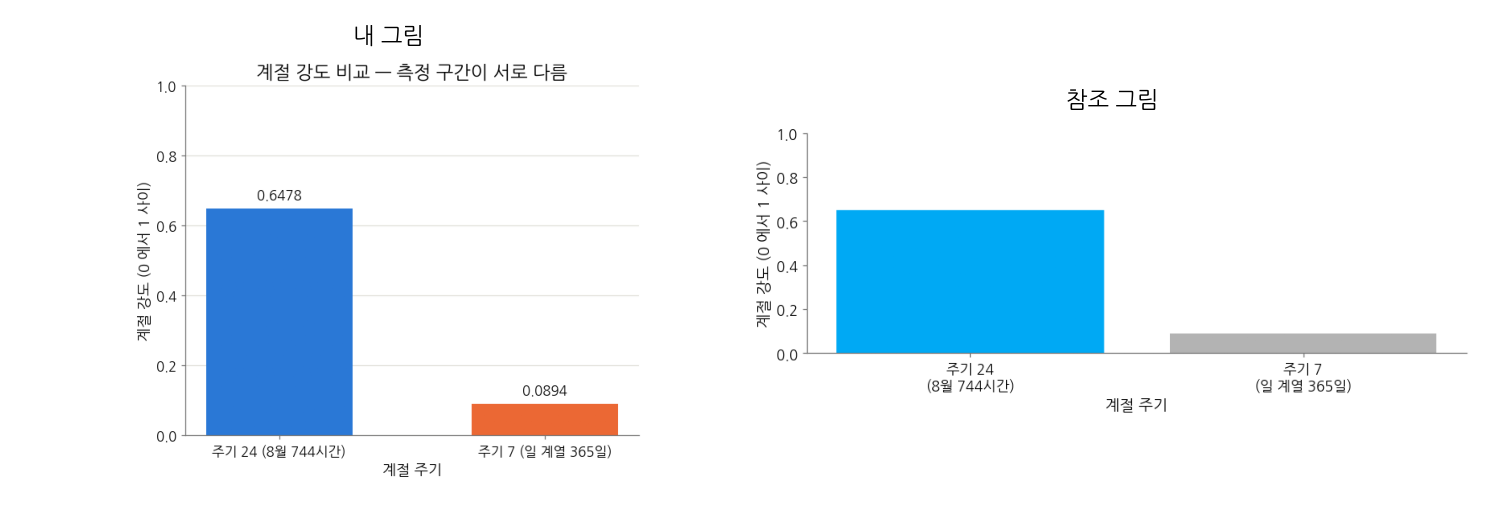

In [3]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
너는 서울 공유자전거 운영팀의 수요예측 담당자야. 첫날 팀장이 자료 링크와 함께 두 가지를 요청했어. "다음 주 배치 계획을 근거로 짜려고 합니다. 이 수요에 어떤 계절성이 있는지, 그리고 이 데이터를 그대로 예측 모형에 쓸 수 있는지부터 확인해 주십시오."
첫 물음은 배치 기준을 정하는 탐색이고, 둘째 물음은 그 기준을 산출할 모형이 이 계열을 받아들일 수 있는지 확인하는 정상성 검정이야.

출력 형식은 값 2개를 위의 굵은 이름 그대로 「이름 = 값」 형태로 한 행씩 `print` 해줘.

1. 일단 계절 강도를 출력해줘 8월 744시간 · 주기 24 — 무차원 · 소수점 아래 4자리 · `aug` 를 주기 24 로 STL 분해해 계산한 값, 이때 `aug`	2018년 8월 시간당 수요, 744시간, `daily`	일 수요, 하루 합계 365일	고정, `df` 표 전체, 8,760시간. 이 세개는 이미 있으니까 출력하지마.
2. 그리고 또 다른 계절 강도— 일 계열 365일 · 주기 7 — 무차원 · 소수점 아래 4자리 · `daily` 를 주기 7 로 STL 분해해 계산한 값을 출력해줘
3. 그리고 두 값을 각각 그 집계 단위에서 그 주기가 설명한 비중으로 읽은 한 행을 출력해주되, 값마다 측정 구간을 함께 적고, 측정 구간이 다른 두 값을 나누어 배수로 읽지 않게 해줘. 채점 대상이 아니라 완성본과 비교할 내용이야.
4. 마지막은 그래프 인데 아래를 포함시켜서 출력해줘 — 가로축은 계절 주기, 세로축은 계절 강도인 막대 그래프
   * 막대 2개의 이름은 「주기 24 (8월 744시간)」 과 「주기 7 (일 계열 365일)」
   * 막대 이름에서 측정 구간을 빼지 않습니다. 빼면 두 값이 같은 조건에서 나온 것처럼 읽힙니다
   * 세로축 범위는 0 에서 1, 가로축 이름은 「계절 주기」, 세로축 이름은 「계절 강도 (0 에서 1 사이)」
"""
# --- 여기부터 AI 코드 ---
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# ── 1. 계절 강도 — 시간 계열(aug) · 주기 24 · 8월 744시간 ──────────────
stl_시간 = STL(aug, period=24, robust=True).fit()
분산_잔차_시간 = stl_시간.resid.var()
분산_계절잔차_시간 = (stl_시간.seasonal + stl_시간.resid).var()
계절강도_주기24_8월744시간 = max(0.0, 1 - 분산_잔차_시간 / 분산_계절잔차_시간)

print(f"계절강도_주기24_8월744시간 = {계절강도_주기24_8월744시간:.4f}")

# ── 2. 계절 강도 — 일 계열(daily) · 주기 7 · 365일 ─────────────────────
stl_일 = STL(daily, period=7, robust=True).fit()
분산_잔차_일 = stl_일.resid.var()
분산_계절잔차_일 = (stl_일.seasonal + stl_일.resid).var()
계절강도_주기7_일365일 = max(0.0, 1 - 분산_잔차_일 / 분산_계절잔차_일)

print(f"계절강도_주기7_일365일 = {계절강도_주기7_일365일:.4f}")

# ── 3. 비교용 한 행 (채점 대상 아님 — 완성본과 대조용) ──────────────────
print(
    f"8월 744시간(시간 계열 · 주기 24) 기준으로는 추세를 뺀 나머지 변동의 "
    f"{계절강도_주기24_8월744시간*100:.1f}%를 하루 주기가 설명하고, "
    f"365일(일 계열 · 주기 7) 기준으로는 추세를 뺀 나머지 변동의 "
    f"{계절강도_주기7_일365일*100:.1f}%를 요일 주기가 설명한다 "
    f"— 두 값은 측정 구간이 달라 나누어 배수로 읽지 않는다."
)

# ── 4. 막대그래프 — 계절 주기별 계절 강도 비교 ─────────────────────────
막대이름 = ["주기 24 (8월 744시간)", "주기 7 (일 계열 365일)"]
막대값 = [계절강도_주기24_8월744시간, 계절강도_주기7_일365일]
색상 = ["#2a78d6", "#eb6834"]  # 범주형 슬롯 1(blue)·2(orange)

fig, ax = plt.subplots(figsize=(6, 5))
막대 = ax.bar(막대이름, 막대값, color=색상, width=0.55)

for rect, v in zip(막대, 막대값):
    ax.text(rect.get_x() + rect.get_width() / 2, v + 0.02,
             f"{v:.4f}", ha="center", va="bottom", fontsize=11)

ax.set_ylim(0, 1)
ax.set_xlabel("계절 주기")
ax.set_ylabel("계절 강도 (0 에서 1 사이)")
ax.set_title("계절 강도 비교 — 측정 구간이 서로 다름")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

> **[문제] 미션 1 에서 받은 코드는 STL 을 두 번 호출합니다. 그 두 호출이 무엇을 어떻게 다르게 두었을 때만 두 계절 강도를 비교할 수 있나요?**
>
> 1. 두 호출 모두 8월 시간 계열에 걸고 주기만 24 와 7 로 달리 준다
> 2. 주기 24 는 8월 시간 계열에, 주기 7 은 하루 합계 일 계열에 걸고, 이상 구간을 잔차로 보내는 강건 옵션은 두 호출 모두에 켜 둔다
> 3. 강건 옵션은 값이 큰 주기 24 호출에만 켜면 된다

## 2. ADF·KPSS 정상성 판정과 계절차분 횟수 D

### 미션 2 [선택] — ADF·KPSS 판정 방향의 오류 수정 (함정 미션)

#### 할 일 — 미션 2 (20분)

1. 「준비 셀」을 실행한 뒤 「PROMPT 셀」을 고치지 말고 **그대로 ▶ 로 실행해** 전임 담당자 코드의 채점 결과를 확인합니다. `PROMPT` 가 비어 있어도 이 채점은 출력됩니다.
2. 그다음은 맨 위 「이 노트북을 쓰는 법」의 5단계와 같습니다.

미션 1 에서 팀장 질문의 첫 부분에 답했습니다. 계절성은 요일이 아니라 시각에 있었습니다. 남은 둘째 부분이 이 미션입니다.

**정상성**은 이론의 「6. 정상성: 언제 측정해도 같은 값이 나오는 성질」이 정의한 성질이고, 눈이 아니라 **ADF** 와 **KPSS** 두 검정으로 판정합니다.

아래 표의 `ALPHA` 는 미리 정한 유의수준이고, p값이 이보다 작으면 그 검정의 귀무가설을 기각합니다. 두 검정은 **귀무가설이 서로 반대**여서 한쪽만 보면 「아니라는 증거가 있다」 와 「증거가 없다」 를 구분하지 못하므로 둘을 함께 씁니다.

ADF 통계량은 직전 값이 그대로 전달되는 정도입니다. 8,760시간에서 5% 임계값은 −2.86 이고, 통계량이 그보다 더 음수이면 기각입니다.

KPSS 통계량은 평균을 뺀 값의 누적합이 0 에서 멀어진 정도입니다. 5% 임계값은 0.463 이고, 통계량이 그보다 크면 기각입니다.

**이 미션의 질문** — 이 계열을 그대로 예측 모형에 쓸 수 있습니까?

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `hourly_c` | 시간당 수요 8,760시간, 단위 대/시간. 이론에서 `hourly` 로 부른 계열입니다 | 고정 |
| `daily_c` | 일 수요 365일, 단위 대/일. 미션 1 의 `daily` 와 같은 계열입니다 | 고정. 과제에서 씁니다 |
| `ALPHA` | 두 검정에 같이 쓰는 유의수준 | 고정 |

#### 틀린 곳 찾기

「여기부터 AI 코드」 행 아래 코드를 한 행씩 읽습니다.

> **[예측] AI 코드 행 아래 코드는 에러 없이 돌아가는데 답이 틀렸습니다. 틀린 곳은 어디이고 왜일까요?**
>
> 1. 검정을 부르는 두 행 — `adfuller` 와 `kpss` 에 전달한 인자가 서로 달라서
> 2. 판정 문구를 만드는 두 행 — 두 검정을 똑같이 "p 가 작으면 정상" 으로 읽어서
> 3. D 를 정하는 행 — 두 판정을 하나로 묶는 방식이 틀려서
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 항목에 근거 한 문장을 적어 둡니다.

#### 고칠 것

검정을 부르는 두 행은 그대로 두고, 아래 4개가 나오도록 그 뒤를 수정합니다.

1. **ADF 검정통계량 — 원본 시간 계열** — 무차원 · 소수점 아래 4자리 · 시간당 수요 `hourly_c` 에 적용한 값
   - 지금 — `ADF  통계량 = …   p값 = …   → 정상` 이라는 행으로 찍힙니다. 행 이름이 위 굵은 이름과 다르고, 통계량 뒤에는 결론만 있어 무엇을 기각했는지도 알 수 없습니다
   - 수정 후 — 행 이름을 굵은 이름 그대로 `ADF 검정통계량 — 원본 시간 계열` 로 바꾸고, 같은 행에 「단위근 가설을 기각했는가, 그래서 어느 쪽 증거인가」 를 추가합니다. ADF 의 귀무가설은 「단위근이 있다(비정상)」 이고, **단위근**은 값이 한 방향으로 표류해 평균이 제자리로 복귀하지 않는 성질입니다
2. **KPSS 검정통계량 — 원본 시간 계열** — 무차원 · 소수점 아래 4자리 · 같은 계열에 적용한 값
   - 지금 — `KPSS 통계량 = …   p값 = …   → 정상` 이라는 행으로 찍힙니다. 행 이름이 위 굵은 이름과 다르고, 이어지는 결론은 검정이 실제로 말하는 것과 반대입니다
   - 수정 후 — 행 이름을 `KPSS 검정통계량 — 원본 시간 계열` 로 바꾸고, 귀무가설이 「정상이다」 라는 것을 반영해 기각 문구의 방향을 바꿉니다
3. **계절차분 횟수 D** — 단위 회 · 정수 · 아래 조합표를 그대로 조건문으로 옮겨 정합니다. 넷째 조합의 1 회는 남은 구조가 계절 성분일 때의 값입니다
   - 지금 — 이 행의 이름만은 굵은 이름과 이미 같습니다. 다만 판정 문구 2개가 모두 「정상」 인지만 보고 D 를 정하고, 맨 아래 「최종 판정 :」 행이 미션 1 의 측정 결과와 어긋나는 결론을 출력합니다
   - 수정 후 — 「최종 판정 :」 행은 네 조합 가운데 어디에 해당하는지를 적는 행으로 바꿉니다
4. **그래프 한 장** — 가로축은 시차(시간), 세로축은 자기상관인 막대 그래프
   - 전임 코드가 그린 막대는 시차 1 부터 48 까지 48개이고 늘 1 인 시차 0 은 제외합니다. 이 막대를 그대로 두고 시차 24 와 48 막대의 색만 바꿉니다
   - 자기상관 0 에 가로선 하나를 긋고, **판정선 ±1.96/√T** 위치에 가로 점선 2개를 더 긋습니다. 판정선은 자기상관이 0 과 구별되는지를 판정하는 선이고 이론의 「5. 자기상관과 ACF」가 정의했습니다. 이 계열은 8,760시간이라 판정선이 ±0.021 입니다
   - 가로축 이름 「시차 (시간)」, 세로축 이름 「자기상관」

#### ADF·KPSS 판정 조합표

이론의 「7. ADF와 KPSS: 귀무가설이 반대인 두 검정」의 조합표와 행 순서까지 같고, D 만 여기에 함께 적었습니다. 표의 「다음 행동」 에 나오는 두 차분은 빼는 대상이 다릅니다. **레벨 차분**은 바로 앞 값을 빼는 연산이고, **계절차분**은 한 주기 전 값, 곧 이 시간당 수요에서는 24시간 전 같은 시각의 값을 빼는 연산입니다.

| 조합 | ADF | KPSS | 판정 | 다음 행동 | D |
|---|---|---|---|---|---|
| 첫째 | 기각 | 비기각 | 정상 합의 | 그대로 모형으로 | 0 회 |
| 둘째 | 비기각 | 기각 | 비정상 합의 | 레벨 차분 뒤 재검정 | 0 회 |
| 셋째 | 비기각 | 비기각 | 증거 부족 | 표본·사양 재검토 | 0 회 |
| 넷째 | 기각 | 기각 | 구조가 남음 | 남은 구조가 계절 성분이면 계절차분 뒤 재검정 | 1 회 |

이 표의 D 는 계절차분 횟수입니다. 레벨 차분 횟수 d 는 ADF 가 단위근 가설을 기각했는지로 따로 정하며, 오늘 이 시간당 수요에서는 0 입니다.

**출력 형식** — 값 3개를 위의 굵은 이름 그대로 「이름 = 값 단위」 형태로 한 행씩 `print` 합니다. 채점은 그 이름이 있는 행만 읽습니다.

**통과 기준** — 값 3개가 각각 자기 이름을 가진 행으로 출력되고 막대 48개 그림이 위 요구를 갖추면 통과입니다.

#### 프롬프트에 넣을 것(힌트)

- **고칠 곳** — 검정을 부르는 두 행은 그대로 두고 판정 문구를 만드는 두 행을 무엇으로 바꿀지.
- **두 귀무가설** — ADF 는 「단위근이 있다(비정상)」, KPSS 는 「정상이다」 라 읽는 방향이 반대라는 것.
- **손대지 말 범위** — `hourly_c` 와 `ALPHA` 는 다시 만들지 말고, 이미 그려진 막대 48개 그림도 지우지 말라는 것.
- **출력** — 값 3개의 행 이름과 기각 문구를 위에 적은 대로 쓸 것.

**막히면** — AI 튜터에게 「귀무가설이 서로 반대인 두 검정의 결과를 하나의 판정으로 어떻게 묶나요」 처럼 질문합니다.

<details class="lms-extra"><summary>배경 — 눈으로는 정상성을 판정하지 못하는 예</summary>

아래 계열은 평균 수준이 한 방향으로 표류하지는 않는데 최댓값이 규칙적인 간격으로 되풀이됩니다. 이 시간당 수요도 같은 형태이고, 이런 계열은 그림만으로 정상인지 아닌지 판정되지 않습니다.

<img src="https://www.statsmodels.org/stable/_images/examples_notebooks_generated_stationarity_detrending_adf_kpss_8_1.png" width="640" height="428"/>
<p align="center"><em>▲ 태양 흑점 활동 계열 — statsmodels 공식 문서가 ADF·KPSS 두 검정을 나란히 실행해 보일 때 쓰는 예시다. 가로축은 연도, 세로축은 흑점 수다 (출처: statsmodels 공식 문서, Stationarity and detrending (ADF/KPSS))</em></p>

이론이 값까지 제시한 **계절차분 횟수 D** 를 오늘 직접 재현하고 근거를 확인합니다.

</details>

<details class="lms-extra"><summary>자세히 — 기존 코드를 수정하는 미션의 진행 방법</summary>

현업에서 AI 와 일하는 가장 흔한 방식도 빈 화면에서 시작하는 것이 아니라 기존 코드를 수정하는 것입니다.

수정할 코드가 이미 있을 때는 프롬프트에 적을 항목이 달라집니다. **고칠 곳 · 수정 후의 모습 · 손대지 말 범위**를 한 번에 적습니다.

</details>

In [4]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                 # 이 미션만 따로 열어도 이 셀만으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 탐색기에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다

ALPHA = 0.05                              # 유의수준 — 두 검정에 같은 값을 씁니다
hourly_c = df["count"].astype(float)      # 쓸 변수 1 — 원본 시간 계열 (대/시간)
daily_c = df["count"].resample("D").sum()  # 쓸 변수 2 — 하루 합계로 만든 일 계열 (대/일)

print(f"시간 계열 {len(hourly_c):,}개  평균 {hourly_c.mean():.1f} 대/시간  "
      f"표준편차 {hourly_c.std():.1f}")
print(f"일 계열   {len(daily_c):,}개  평균 {daily_c.mean():,.1f} 대/일  "
      f"표준편차 {daily_c.std():,.1f}")
print(f"유의수준 ALPHA = {ALPHA}")
print()
print("ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거")
print("KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거")
print("쓸 수 있는 이름 : df (표 전체) · hourly_c (원본 시간 계열, 대/시간)"
      " · daily_c (일 계열, 대/일) · ALPHA (유의수준)")

시간 계열 8,760개  평균 704.6 대/시간  표준편차 645.0
일 계열   365개  평균 16,910.4 대/일  표준편차 10,258.6
유의수준 ALPHA = 0.05

ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거
KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거
쓸 수 있는 이름 : df (표 전체) · hourly_c (원본 시간 계열, 대/시간) · daily_c (일 계열, 대/일) · ALPHA (유의수준)


/tmp/ipykernel_5124/384178737.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat_kpss, p_kpss = kpss(x, regression="c", nlags="auto")[:2]
ADF 검정통계량 — 원본 시간 계열 = -6.9470   (p = 9.915e-10, α = 0.05)   단위근 가설을 기각 → 정상 쪽 증거
KPSS 검정통계량 — 원본 시간 계열 = 8.0051   (p = 0.01, α = 0.05)   정상 가설을 기각 → 비정상 쪽 증거
계절차분 횟수 D = 1 회
최종 판정 : ADF 기각 · KPSS 기각 — 두 답의 방향이 반대 → 남은 구조를 보고 그에 맞는 차분을 고른다

──────────────────────────────────────────────────────
◼ 미션 2 채점 결과
✅ ADF 검정통계량 — 원본 시간 계열 — 출력에서 -6.947 를 찾았습니다
✅ KPSS 검정통계량 — 원본 시간 계열 — 출력에서 8.0051 를 찾았습니다
✅ 계절차분 횟수 D — 출력에서 1 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
🔓 정답이 열렸습니다 — 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줘 보세요
🔓 미션 2 완성본 — AI 코드 행 아래에서 수정해야 했던 곳은 판정 문구를 만드는 두 행입니다

■ 이 코드를 부른 프롬프트 예

    전임 담당자 코드에서 검정 두 개를 부르는 두 행은 그대로 두고, 판정 문구를 만드는 두 행이 틀렸으니 고쳐 줘. ADF 와 KPSS 는 귀무가설이 서로 반대라
    같은 「p 가 작으면 정상」 규칙을 둘 다에 쓸 수 없어 — ADF 는 귀무가설이 「단위근이 있다(비정상)」 라서

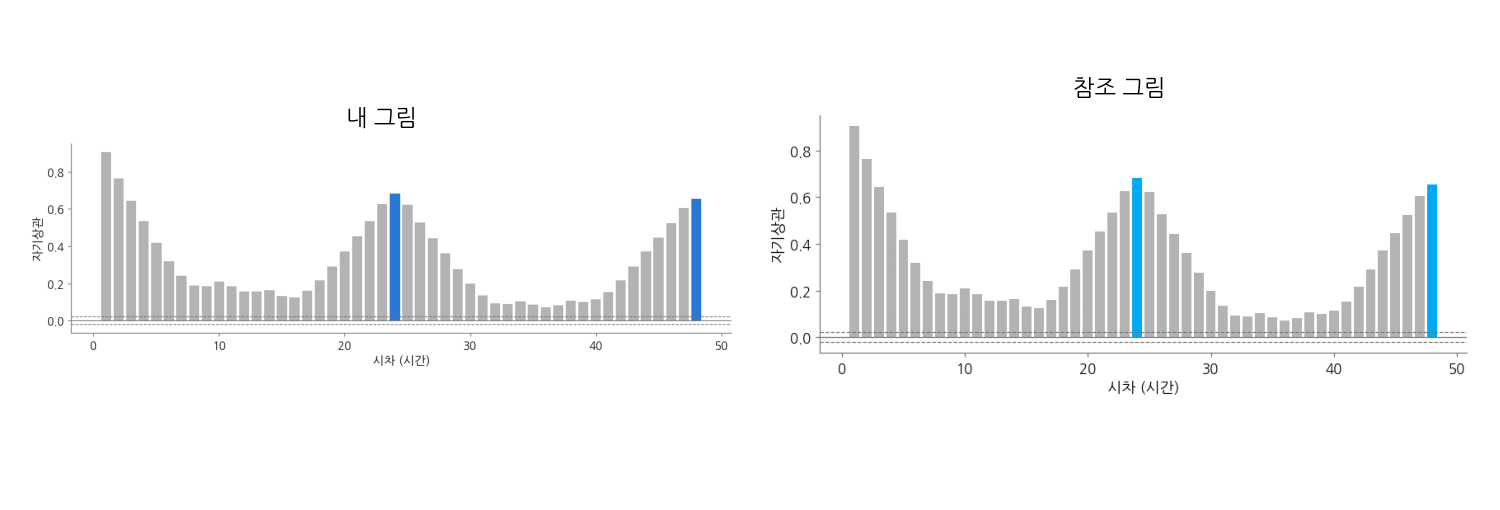

In [5]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 행 아래를 다시 씁니다.
PROMPT = """
def is_stationary_wrong(x, alpha=ALPHA):
    stat_adf, p_adf = adfuller(x, autolag="AIC")[:2]
    stat_kpss, p_kpss = kpss(x, regression="c", nlags="auto")[:2]
    verdict_adf = "정상" if p_adf < alpha else "비정상"
    verdict_kpss = "정상" if p_kpss < alpha else "비정상"
    print(f"ADF  통계량 = {stat_adf:.4f}   p값 = {p_adf:.4g}   → {verdict_adf}")
    print(f"KPSS 통계량 = {stat_kpss:.4f}   p값 = {p_kpss:.4g}   → {verdict_kpss}")
    return verdict_adf == "정상" and verdict_kpss == "정상"


ok = is_stationary_wrong(hourly_c)
D = 0 if ok else 1
print(f"계절차분 횟수 D = {D} 회")
print("최종 판정 :", "정상 — 그대로 모형에 넣어도 됩니다" if ok else "비정상 — 계절차분이 필요합니다")

r = acf(hourly_c, nlags=48)[1:]
fig, ax = plt.subplots(figsize=(FIG_W, 3.4))
ax.bar(np.arange(1, 49), r, color=COL["연회색"], width=0.8)
ax.axhline(0, color=COL["회색"], lw=0.8)
ax.set_xlabel("시차 (시간)")
ax.set_ylabel("자기상관")
plt.show()

해당 코드를 아래와 같이 수정해야해

1. 지금은 `ADF 통계량 = … p값 = … → 정상`  이라는 행으로 찍히고 있어. 행 이름이 위 굵은 이름과 다르고, 통계량 뒤에는 결론만 있어 무엇을 기각했는지도 알 수 없어. 그래서 행 이름은 굵은 이름 그대로 `ADF 검정통계량 — 원본 시간 계열` 로 바꾸고, 같은 행에 「단위근 가설을 기각했는가, 그래서 어느 쪽 증거인가」 를 추가해줘. 
2. 지금은 `KPSS 통계량 = … p값 = … → 정상` 이라는 행으로 찍히고 있어. 행 이름이 위 굵은 이름과 다르고, 이어지는 결론은 검정이 실제로 말하는 것과 반대야. 그래서 행 이름을 `KPSS 검정통계량 — 원본 시간 계열` 로 바꾸고, 귀무가설이 「정상이다」 라는 것을 반영해 기각 문구의 방향을 바꿔줘
3. 계절차분 횟수 D행의 이름만은 굵은 이름과 이미 같습니다. 다만 판정 문구 2개가 모두 「정상」 인지만 보고 D 를 정하고, 맨 아래 「최종 판정 :」 행이 미션 1 의 측정 결과와 어긋나는 결론을 출력하고 있어. 그래서 「최종 판정 :」 행은 네 조합 가운데 어디에 해당하는지를 적는 행으로 바꿔줘
4. 마지막은 그래프 한 장 — 가로축은 시차(시간), 세로축은 자기상관인 막대 그래프를 출력해줘
   * 전임 코드가 그린 막대는 시차 1 부터 48 까지 48개이고 늘 1 인 시차 0 은 제외했어. 이 막대를 그대로 두고 시차 24 와 48 막대의 색만 바꿔줘
   * 자기상관 0 에 가로선 하나를 긋고, 판정선 ±1.96/√T 위치에 가로 점선 2개를 더 그어줘. 판정선은 자기상관이 0 과 구별되는지를 판정하는 선이고 이론의 「5. 자기상관과 ACF」가 정의했어. 이 계열은 8,760시간이라 판정선이 ±0.021 이야.
   * 가로축 이름 「시차 (시간)」, 세로축 이름 「자기상관」


출력 형식은 값 3개를 위의 굵은 이름 그대로 「이름 = 값 단위」 형태로 한 행씩 `print` 해줘
"""
# --- 여기부터 AI 코드 ---
def is_stationary_wrong(x, alpha=ALPHA):
    stat_adf, p_adf = adfuller(x, autolag="AIC")[:2]
    stat_kpss, p_kpss = kpss(x, regression="c", nlags="auto")[:2]

    reject_adf = p_adf < alpha      # H0: 단위근이 있다(비정상) — 기각하면 정상 쪽 증거
    reject_kpss = p_kpss < alpha    # H0: 정상이다 — 기각하면 비정상 쪽 증거 (ADF와 반대 방향)

    # ── 1. ADF ──────────────────────────────────────────────
    판정_adf = "기각 → 정상 쪽 증거" if reject_adf else "비기각 → 비정상 쪽(단위근 가설 유지)"
    print(f"ADF 검정통계량 — 원본 시간 계열 = {stat_adf:.4f}   "
          f"(p = {p_adf:.4g}, α = {alpha})   단위근 가설을 {판정_adf}")

    # ── 2. KPSS ─────────────────────────────────────────────
    판정_kpss = "기각 → 비정상 쪽 증거" if reject_kpss else "비기각 → 정상 쪽(정상 가설 유지)"
    print(f"KPSS 검정통계량 — 원본 시간 계열 = {stat_kpss:.4f}   "
          f"(p = {p_kpss:.4g}, α = {alpha})   정상 가설을 {판정_kpss}")

    # ── 3. 네 조합 가운데 어디에 해당하는지 ────────────────────
    if reject_adf and not reject_kpss:
        조합, 조치, ok = "ADF 기각 · KPSS 비기각 — 둘 다 정상 쪽 증거", "그대로 다음 단계로 간다", True
    elif not reject_adf and reject_kpss:
        조합, 조치, ok = "ADF 비기각 · KPSS 기각 — 둘 다 비정상 쪽 증거", "차분한 뒤 다시 검정한다", False
    elif not reject_adf and not reject_kpss:
        조합, 조치, ok = "ADF 비기각 · KPSS 비기각 — 어느 쪽도 판정하지 못함", "표본이 짧아 증거가 모자란 것 — 구간을 늘려 다시 본다", False
    else:
        조합, 조치, ok = "ADF 기각 · KPSS 기각 — 두 답의 방향이 반대", "남은 구조를 보고 그에 맞는 차분을 고른다", False

    D = 0 if ok else 1
    print(f"계절차분 횟수 D = {D} 회")
    print(f"최종 판정 : {조합} → {조치}")

    return ok


ok = is_stationary_wrong(hourly_c)

# ── 4. ACF 막대그래프 — 시차 24·48 강조, 0선·판정선 추가 ────────
T = len(hourly_c)
판정선 = 1.96 / np.sqrt(T)   # 이 계열은 T=8,760 → 약 ±0.021

r = acf(hourly_c, nlags=48)[1:]
막대색 = [("#2a78d6" if lag in (24, 48) else COL["연회색"]) for lag in range(1, 49)]

fig, ax = plt.subplots(figsize=(FIG_W, 3.4))
ax.bar(np.arange(1, 49), r, color=막대색, width=0.8)
ax.axhline(0, color=COL["회색"], lw=0.8)
ax.axhline(판정선, color=COL["회색"], lw=0.8, ls="--")
ax.axhline(-판정선, color=COL["회색"], lw=0.8, ls="--")
ax.set_xlabel("시차 (시간)")
ax.set_ylabel("자기상관")
plt.show()

> **[문제] 미션 2 에서 수정한 뒤의 코드가 두 검정의 판정을 만드는 방식으로 맞는 것은?**
>
> 1. 두 검정 모두 `p값 < ALPHA` 면 "정상"으로 읽는다 — 같은 유의수준을 썼으니 결론 방향도 같다
> 2. 같은 `p값 < ALPHA` 를 ADF 에서는 "단위근 가설을 기각 = 정상 쪽 증거"로, KPSS 에서는 "정상 가설을 기각 = 비정상 쪽 증거"로 읽는다
> 3. `kpss(..., regression="c")` 의 `"c"` 를 `"ct"` 로 바꾸면 판정 방향이 반대가 된다 — 방향은 그 인자가 정한다

## 3. 계절차분 전후의 검정과 자기상관 대조

### 미션 3 [선택] — 24시간 계절차분 적용과 전후 대조

#### 할 일 — 미션 3 (25분)

1. 이 미션에는 프롬프트 힌트가 없습니다. 미션 1 과 2 에서 쓴 도구를 어떤 순서로 부를지 스스로 적습니다.

미션 2 의 두 검정이 지시한 변환은 24시간 계절차분 1회였습니다. 그 변환을 실제로 적용해 효과가 있었는지 확인하는 것이 이 미션입니다. 확인 방법은 새 도구가 아니라 같은 지표를 차분 전과 후에 한 번씩 측정해 비교하는 것입니다.

**이 미션의 질문** — 24시간 계절차분을 1회 적용하면 무엇이 달라집니까?

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `hourly_c` | 시간당 수요 8,760시간, 단위 대/시간 | 고정 |
| `ALPHA` | 유의수준 | 고정 |
| `autocorr(계열, 시차)` | 그 시차의 자기상관 한 값을 반환하는 함수 | 그대로 부른다 |
| `acf` · `adfuller` · `kpss` | 자기상관과 두 검정을 부르는 함수 | 그대로 부른다 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 모두 출력되게 합니다. 값 4개는 **서로 다른 행**으로 출력합니다. 차분 전 값과 차분 후 값을 한 행에 함께 적으면 채점이 어느 숫자가 답인지 판별하지 못합니다.

1. **계절차분 후 KPSS 검정통계량** — 무차원 · 소수점 아래 4자리 · 24시간 계절차분한 계열에 적용한 값입니다. 통계량은 p 값이 아니라 반환값의 첫 값입니다
2. **차분 전 KPSS 검정통계량** — 같은 자릿수 · 시간당 수요 `hourly_c` 에 적용한 값
3. **계절차분 후 시차 24 자기상관** — 무차원 · 소수점 아래 4자리 · 양수에도 부호가 함께 출력되도록 적습니다. 이 값은 크기가 아니라 방향이 요점입니다
4. **차분 전 시차 24 자기상관** — 같은 자릿수 · 같은 부호 표기 · 시간당 수요에서 측정한 값
5. **덧붙일 한 행** — 차분한 계열의 길이를 원계열 길이와 함께 적습니다. 채점 대상이 아니라 완성본과 비교할 값입니다
6. **그래프 한 장, 패널 2개** — 두 패널 모두 가로축은 시차(시간), 세로축은 자기상관인 막대 그래프
   - 왼쪽은 원계열이고 제목은 「원계열」, 오른쪽은 24시간 계절차분한 계열이고 제목은 「24시간 계절차분 후」
   - 막대는 패널마다 시차 1 부터 최소 24 까지이고, 늘 1 인 시차 0 은 제외합니다
   - 0 에 가로선 하나와 **판정선 ±1.96/√T** 위치의 가로 점선 2개를 긋고, 가로축 이름은 「시차 (시간)」, 세로축 이름은 「자기상관」 입니다

**출력 형식** — 값 4개를 위의 굵은 이름 그대로 「이름 = 값」 형태로 한 행씩 `print` 합니다. 채점은 그 이름이 있는 행만 읽습니다.

**통과 기준** — 채점이 읽는 값은 1번과 3번이고 2번과 4번은 비교에 쓰는 값입니다. 값 2개가 각각 자기 이름을 가진 행으로 출력되고 패널 2개 그림이 위 요구를 갖추면 통과입니다.

**막히면** — AI 튜터에게 「24시간 전 같은 시각의 값을 빼는 차분은 레벨 차분과 어떻게 다른가요」 처럼 질문합니다.

#### 예상 적기

미션 2 의 자기상관 그림에서 시차 24 막대는 주변보다 높았습니다.

> **[예측] 24시간 계절차분을 적용한 뒤 자기상관을 다시 측정하면, 시차 24 의 막대는 어디로 갈까요?**
>
> 1. 0.3 근처로, 절반쯤 줄어든 값으로 남는다
> 2. 0 근처로 사라진다
> 3. 0 보다 아래로 크게 내려가 음수가 된다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 뒤에 그렇게 되는 근거를 한 문장 적어 둡니다. 근거로 쓸 설명은 이론의 「8. 차분: 비정상을 정상으로 바꾸는 변환」에 있습니다.

<details class="lms-extra"><summary>배경 — 계절차분의 계산과 다른 계열의 차분 사례</summary>

계절차분은 이론의 「8. 차분: 비정상을 정상으로 바꾸는 변환」이 정의한 연산입니다. 24시간 전 같은 시각의 값을 빼서 시각마다 다른 평균을 상쇄하고, 맨 앞 24시간은 뺄 값이 없어 사라지므로 차분한 계열은 원계열보다 24개 짧습니다.

<img src="https://www.statsmodels.org/stable/_images/examples_notebooks_generated_stationarity_detrending_adf_kpss_20_1.png" width="640" height="426"/>
<p align="center"><em>▲ 태양 흑점 계열을 레벨 차분한 뒤 다시 그린 그림 — 평균 수준이 높게 유지되던 구간이 사라지고 값이 0 을 중심으로 오르내린다 (출처: statsmodels 공식 문서, Stationarity and detrending (ADF/KPSS))</em></p>

statsmodels 문서는 이 차분 계열에 두 검정을 다시 적용해 ADF −14.86 과 KPSS 0.0212(5% 임계값 0.463)를 얻고 정상으로 읽습니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/usemployment2-1.png" width="640" height="352"/>
<p align="center"><em>▲ 미국 고용 계열에 12개월 계절차분을 한 번 적용한 뒤의 모습 — 위는 차분한 계열, 아래 왼쪽은 자기상관(ACF), 오른쪽은 부분자기상관(PACF)이다. 계절차분 뒤에도 ACF 막대가 오른쪽 끝까지 천천히만 줄어들어 저자들은 레벨 차분을 한 번 더 적용한다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., otexts.com/fpp3)</em></p>

위 그림은 월 단위 계열이라 계절 주기가 24 가 아니라 12 입니다. **부분자기상관(PACF)** 은 중간 시차를 거친 간접 상관을 제거한 직접 상관이며, 둘째 날에 정의부터 다시 다룹니다.

</details>

In [6]:
# 미션 3 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 3 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                 # 이 미션만 따로 열어도 이 셀만으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 탐색기에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다

ALPHA = 0.05                              # 유의수준 — 미션 2 와 같은 값을 씁니다
hourly_c = df["count"].astype(float)      # 쓸 변수 1 — 원본 시간 계열 (대/시간)


def autocorr(x, k):                       # 쓸 변수 2 — 시차 k 자기상관 한 값
    """statsmodels acf 로 시차 0 부터 k 까지를 구한 뒤 k 번째 자리만 돌려줍니다"""
    return float(acf(np.asarray(x, dtype=float), nlags=k)[k])


print(f"시간 계열 {len(hourly_c):,}개  평균 {hourly_c.mean():.1f} 대/시간  "
      f"표준편차 {hourly_c.std():.1f}")
print(f"유의수준 ALPHA = {ALPHA}")
print()
print("KPSS 귀무가설: 정상이다 → 통계량이 5% 임계값 0.463 보다 작으면 기각하지 못한다 = 정상 쪽")
print("검정 도구 : adfuller(계열, autolag=\"AIC\") · kpss(계열, regression=\"c\", nlags=\"auto\")"
      " — 반환값의 첫 값이 통계량")
print("쓸 수 있는 이름 : df (표 전체) · hourly_c (원본 시간 계열, 대/시간) · ALPHA (유의수준)"
      " · autocorr(계열, 시차) · acf · adfuller · kpss")

시간 계열 8,760개  평균 704.6 대/시간  표준편차 645.0
유의수준 ALPHA = 0.05

KPSS 귀무가설: 정상이다 → 통계량이 5% 임계값 0.463 보다 작으면 기각하지 못한다 = 정상 쪽
검정 도구 : adfuller(계열, autolag="AIC") · kpss(계열, regression="c", nlags="auto") — 반환값의 첫 값이 통계량
쓸 수 있는 이름 : df (표 전체) · hourly_c (원본 시간 계열, 대/시간) · ALPHA (유의수준) · autocorr(계열, 시차) · acf · adfuller · kpss


/tmp/ipykernel_5124/1350901006.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat_after = kpss(hourly_diff24, regression="c", nlags="auto")[0]
계절차분 후 KPSS 검정통계량 = 0.0083
/tmp/ipykernel_5124/1350901006.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat_before = kpss(hourly_c, regression="c", nlags="auto")[0]
차분 전 KPSS 검정통계량 = 8.0051
계절차분 후 시차 24 자기상관 = -0.4579
차분 전 시차 24 자기상관 = +0.6813
계열 길이 — 원계열 8760시간 · 24시간 계절차분 후 8736시간

──────────────────────────────────────────────────────
◼ 미션 3 채점 결과
✅ 계절차분 후 KPSS 검정통계량 — 출력에서 0.0083 를 찾았습니다
✅ 계절차분 후 시차 24 자기상관 — 출력에서 -0.4579 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
🔓 정답이 열렸습니다 — 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줘 보세요
🔓 미션 3 완성본 — AI 코드 행 아래에 있어야 할 코드입니다

■ 이 코드를 부른 프롬프트 예

    이미 만들어져 있는 df, hourl

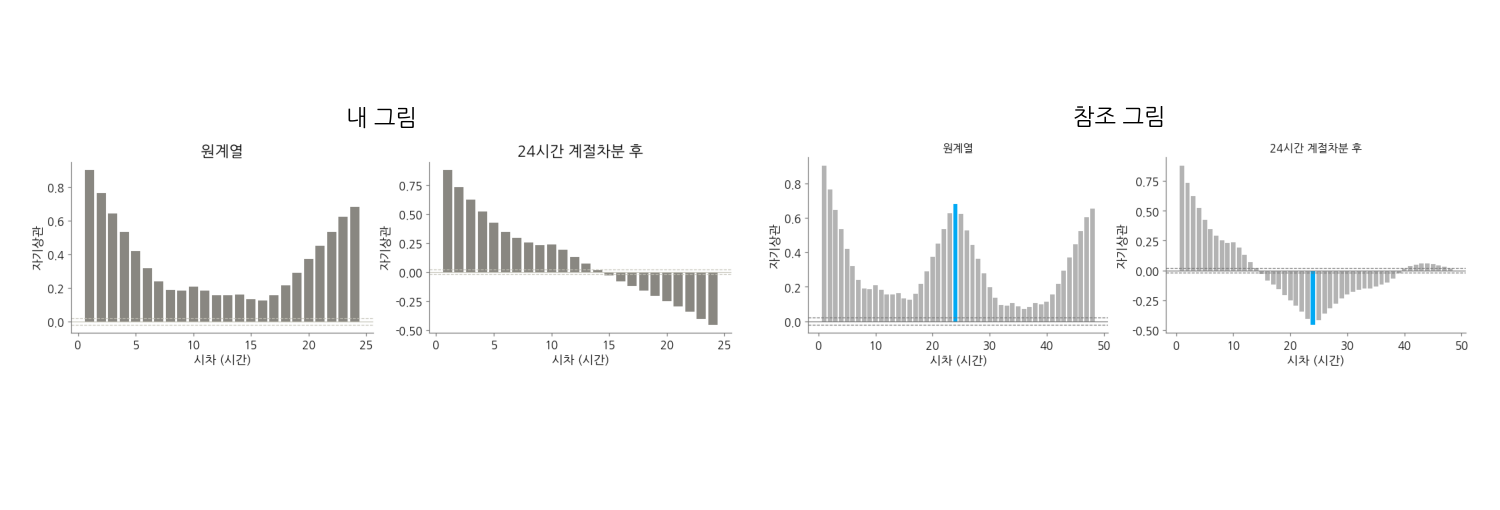

In [7]:
# 미션 3 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
일단 이 아래는 만들어져 있어서 안 만들어도 돼

* `hourly_c`	시간당 수요 8,760시간, 단위 대/시간
* `ALPHA`	유의수준	
* `autocorr(계열, 시차)`	그 시차의 자기상관 한 값을 반환하는 함수
* acf · adfuller · kpss	자기상관과 두 검정을 부르는 함수	


아래 항목들을 출력해줘

1. 계절차분 후 KPSS 검정통계량 — 무차원 · 소수점 아래 4자리 · 24시간 계절차분한 계열에 적용한 값. 통계량은 p 값이 아니라 반환값의 첫 값이야.
2. 차분 전 KPSS 검정통계량 — 같은 자릿수 · 시간당 수요 `hourly_c` 에 적용한 값.
3. 계절차분 후 시차 24 자기상관 — 무차원 · 소수점 아래 4자리 · 양수에도 부호가 함께 출력되도록 적어줘. 이 값은 크기가 아니라 방향이 요점이야.
4. 차분 전 시차 24 자기상관 — 같은 자릿수 · 같은 부호 표기 · 시간당 수요에서 측정한 값
5. 덧붙일 한 행 — 차분한 계열의 길이를 원계열 길이와 함께 적어줘. 
6. 그리고 그래프 한 장을 출력하고, 패널 2개 — 두 패널 모두 가로축은 시차(시간), 세로축은 자기상관인 막대 그래프
   * 왼쪽은 원계열이고 제목은 「원계열」, 오른쪽은 24시간 계절차분한 계열이고 제목은 「24시간 계절차분 후」
   * 막대는 패널마다 시차 1 부터 최소 24 까지이고, 늘 1 인 시차 0 은 제외해.
   * 0 에 가로선 하나와 판정선 ±1.96/√T 위치의 가로 점선 2개를 긋고, 가로축 이름은 「시차 (시간)」, 세로축 이름은 「자기상관」 이야.
"""
# --- 여기부터 AI 코드 ---
# 24시간 계절차분 계열
hourly_diff24 = hourly_c.diff(24).dropna()

# 1. 계절차분 후 KPSS 검정통계량 (반환값의 첫 값 — p값 아님)
kpss_stat_after = kpss(hourly_diff24, regression="c", nlags="auto")[0]
print(f"계절차분 후 KPSS 검정통계량 = {kpss_stat_after:.4f}")

# 2. 차분 전 KPSS 검정통계량
kpss_stat_before = kpss(hourly_c, regression="c", nlags="auto")[0]
print(f"차분 전 KPSS 검정통계량 = {kpss_stat_before:.4f}")

# 3. 계절차분 후 시차 24 자기상관 (부호 표기)
acf24_after = autocorr(hourly_diff24, 24)
print(f"계절차분 후 시차 24 자기상관 = {acf24_after:+.4f}")

# 4. 차분 전 시차 24 자기상관
acf24_before = autocorr(hourly_c, 24)
print(f"차분 전 시차 24 자기상관 = {acf24_before:+.4f}")

# 5. 계열 길이 비교
print(f"계열 길이 — 원계열 {len(hourly_c)}시간 · 24시간 계절차분 후 {len(hourly_diff24)}시간")

# 6. 두 패널 ACF 막대그래프 — 원계열 vs 24시간 계절차분 후
NLAGS = 24
막대색 = "#898781"
선색 = "#c3c2b7"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

for ax, y, title in (
    (ax1, hourly_c, "원계열"),
    (ax2, hourly_diff24, "24시간 계절차분 후"),
):
    r = acf(y, nlags=NLAGS)[1:]
    T = len(y)
    판정선 = 1.96 / np.sqrt(T)   # 계열마다 길이가 달라 T를 따로 계산
    ax.bar(np.arange(1, NLAGS + 1), r, color=막대색, width=0.8)
    ax.axhline(0, color=선색, lw=0.8)
    ax.axhline(판정선, color=선색, lw=0.8, ls="--")
    ax.axhline(-판정선, color=선색, lw=0.8, ls="--")
    ax.set_xlabel("시차 (시간)")
    ax.set_ylabel("자기상관")
    ax.set_title(title)

plt.tight_layout()
plt.show()

> **[문제] 미션 3 에서 작성한 코드가 계절차분 계열을 만드는 방식으로 맞는 것은?**
>
> 1. `.diff()` 를 스물네 번 겹쳐 부른 것과 같다 — 1차 차분을 24회 되풀이한 결과다
> 2. `.dropna()` 를 빼도 길이만 8,760 으로 남을 뿐 검정 결과는 그대로다
> 3. `.diff(24)` 가 24 행 전 값을 한 번 빼고, 맨 앞에 생긴 24개의 결측을 `.dropna()` 가 제거해 길이가 8,736 이 된다

## 4. 일 수요의 차분 횟수 결정과 배치 기준 브리핑

> **[과제] 과제 제출 — 일 수요의 차분 횟수 결정과 배치 기준 브리핑**
>
> - **무엇을** 다음 주 배치 근거 브리핑 세 문장과 차분 단계별 그림 한 장을 만듭니다.
> - **무엇으로** 오늘의 8,760시간 한 가지만 쓰고, 「준비 셀」이 일 수요와 시각·요일 프로파일까지 만들어 둡니다.
> - **인정** 채점이 값 4개와 그림을 모두 통과시킨 노트북에 브리핑 세 문장까지 채운 상태입니다.
> - **예** 값 행은 「일 계열 1차 차분 — 표준편차 = ○,○○○.○ 대/일」 형태입니다.
> 
> - 「PROMPT 셀」을 실행해 값 4개와 그림 한 장이 모두 채점을 통과한 상태로 남깁니다.
> - 그 셀의 PROMPT 는 지우지 말고 내가 쓴 그대로 둡니다.
> - 브리핑 세 문장을 아래 양식에 결론·위험·코드가 답을 만드는 방식 순으로 채웁니다.
>
> 마감: 2026-10-06T23:59+09:00
>
> **평가 기준**
>
> | 기준 | 이렇게 하면 충족 | 배점 |
> | --- | --- | --- |
> | 문제 정의 | 「PROMPT 셀」의 PROMPT 에 목표와 쓸 이름과 출력 형식이 내 말로 적혀 있다. | 25 |
> | 검증 설계 | 값 4개와 그림이 모두 채점을 통과했고 브리핑 세 문장이 채워져 있다. | 25 |
> | 오류 탐지 | 레벨 차분 2회에서 표준편차가 커지고 시차 1 자기상관이 더 음수가 된 것을 수치로 제시했고, 휴무 295시간 처리 선택의 이유가 위험 문장에 있다. | 25 |
> | 해석·보고 | 결론 문장이 배치 기준 하나를 고르고 계절 강도 2개를 측정 구간과 함께 근거로 제시했으며, 위험 문장이 시각 프로파일은 1년 평균이라는 단서를 밝혔다. | 25 |
>
> 제출은 LMS 레슨 화면의 과제 카드에서 GitHub 또는 Google Drive 링크로 합니다(이 파일에 적으면 제출되지 않습니다).

### 과제 — 일 수요의 차분 횟수 결정과 배치 기준 브리핑

#### 할 일 — 과제 (40분)

1. 아래 양식에 브리핑 세 문장을 결론·위험·코드가 답을 만드는 방식 순으로 채워 제출합니다.

미션 3 까지 오면서 팀장이 물은 두 가지에는 답을 냈습니다. 계절성은 시각에 있었고, 계열은 24시간 계절차분 1회로 예측 모형에 쓸 수 있는 상태가 되었습니다. 남은 것은 배치 회의가 실제로 받아 가는 하루 단위 계열입니다.

**이 과제의 질문** — 하루 단위 계열은 몇 회 차분해야 하고, 배치 기준은 무엇으로 삼아야 합니까?

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `daily_c` | 일 수요 365일, 단위 대/일. 미션 1 의 `daily` 와 같은 계열입니다 | 고정 |
| `ALPHA` | 유의수준 | 고정 |
| `autocorr(계열, 시차)` | 그 시차의 자기상관 한 값을 반환하는 함수 | 그대로 부른다 |
| `acf` · `adfuller` · `kpss` | 자기상관과 두 검정을 부르는 함수 | 그대로 부른다 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래 값 7개와 그림 한 장이 모두 출력되게 합니다.

| 출력 행 이름 | 무엇 | 자릿수·단위 | 읽는 곳 |
|---|---|---|---|
| **일 계열 1차 차분 — 시차 1 자기상관** | 레벨 차분 1회 계열의 시차 1 자기상관 | 무차원 · 소수점 아래 4자리 · 양수에도 부호 표기 | 채점 |
| **일 계열 1차 차분 — 표준편차** | 같은 계열의 표준편차 | 대/일 · 소수점 아래 1자리 | 채점 |
| **차분 전 일 계열 — KPSS 통계량** | 차분 전 일 계열에 적용한 반환값 첫 값 | 무차원 · 소수점 아래 4자리 | 채점 |
| **1차 차분 일 계열 — KPSS 통계량** | 레벨 차분 1회 계열에 적용한 같은 값 | 무차원 · 소수점 아래 4자리 | 채점 |
| **차분 전 일 계열 — ADF 검정통계량** | 차분 전 일 계열에 적용한 반환값 첫 값 | 무차원 · 소수점 아래 4자리 | 브리핑 근거 |
| **1차 차분 일 계열 — ADF 검정통계량** | 레벨 차분 1회 계열에 적용한 같은 값 | 무차원 · 소수점 아래 4자리 | 브리핑 근거 |
| **2차 차분 일 계열 — 표준편차와 시차 1 자기상관** | 레벨 차분 2회 계열의 두 값을 한 행에 | 대/일 소수점 아래 1자리 · 자기상관 소수점 아래 4자리 | 루브릭 |

굵은 이름은 출력 행의 이름입니다. 산문에서 **레벨 차분**이라고 부르는 연산이 그 이름에는 「1차 차분」 과 「2차 차분」 으로 적혀 있으므로 굵은 글자를 그대로 옮겨 적습니다. 레벨 차분은 바로 앞 값을 빼는 연산이고, 하루 단위 계열에서 바로 앞 값은 전날입니다.

ADF 두 행은 같은 차분 단계의 KPSS 행 바로 다음에 적고, KPSS·ADF 네 행에는 「어느 가설을 기각했는가」 를 값과 같은 행에 함께 적습니다. 「읽는 곳」 이 채점인 네 값만 통과 여부를 정하고, 브리핑 근거 두 값은 위험 문장에, 루브릭 값은 과차분 판정에 씁니다.

**그래프 한 장, 패널 3개** — 세 패널 모두 가로축은 날짜, 세로축은 대여 수요인 선 그래프

- 패널은 위에서부터 「차분 전」 · 「1차 차분」 · 「2차 차분」 이고 제목도 그대로 답니다
- 패널마다 계열 하나와 0 에 그은 가로선 하나를 두고, 가로축 이름은 「날짜」, 세로축 이름은 「대여 수요 (대/일)」 입니다

**출력 형식** — 값을 굵은 이름 그대로 「이름 = 값 단위」 형태로 한 행씩 `print` 합니다. 값은 모두 `daily_c` 에서 계산하며, 휴무를 채운 보정 계열로 교체하면 수치가 달라져 통과하지 못합니다.

**통과 기준** — 「읽는 곳」 이 채점인 네 값이 각각 자기 이름을 가진 행으로 출력되고 패널 3개 그림이 위 요구를 갖추면 통과입니다.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `daily_c` · `ALPHA` · `autocorr` 은 다시 만들지 말라고 적습니다.
- **세 단계를 같은 형식으로** — 차분 전 · 1차 차분 · 2차 차분을 같은 순서로 출력하고 같은 순서로 배치해 그리라고 적습니다.
- **검정 호출** — 「준비 셀」이 출력하는 「검정 도구 :」 행의 호출을 그대로 쓸 것. 인자를 바꾸면 통계량이 달라집니다.
- **출력과 그래프** — 값의 행 이름을 위의 굵은 이름 그대로 쓰고 단위·자릿수·부호를 지정하며, 패널 3개의 순서와 제목, 가로축·세로축 이름을 적을 것.

**막히면** — AI 튜터에게 「차분을 한 번 더 적용해야 할지 어떤 숫자로 판단하나요」 처럼 질문합니다.

#### 배경

<details class="lms-extra"><summary>배경 — 레벨 차분과 과차분</summary>

레벨 차분은 오차항이 누적되어 수준이 이동하는 비정상인 **확률적 추세**를 상대합니다. 이론의 「8. 차분: 비정상을 정상으로 바꾸는 변환」이 **과차분**도 함께 정의했습니다.

판정은 절대 수치가 아니라 방향으로 합니다. 차분 전 · 레벨 차분 1회 · 레벨 차분 2회 세 단계를 같은 두 지표로 측정해, 한 번 더 차분했을 때 표준편차가 커지고 시차 1 자기상관이 더 음수로 내려가면 그 마지막 한 번이 과차분입니다. 비정상이던 계열을 레벨 차분 1회로 정상으로 만들었을 때 시차 1 자기상관이 −0.5 에 가까운 값으로 나오는 것은 흔한 일이고, 그 값 하나가 과차분의 신호가 되지는 않습니다.

이론이 정한 기준은 셋입니다. 시차 1 자기상관이 +1 근처면 아직 비정상이고, 0 근처면 차수가 맞고, −0.5 근처면 한 번 더 뺀 상태입니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/usemployment3-1.png" width="640" height="352"/>
<p align="center"><em>▲ 미국 고용 계열에 계절차분과 레벨 차분을 잇달아 적용한 뒤의 모습 — 위는 두 번 차분한 계열, 아래 왼쪽은 자기상관, 오른쪽은 부분자기상관이고 파란 점선은 자기상관이 0 과 구별되는지를 판정하는 선이다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3판, 9.1 Stationarity and differencing)</em></p>

이 일 수요의 차분 횟수는 표준편차와 시차 1 자기상관 두 신호가 정합니다.

</details>

<details class="lms-extra"><summary>배경 — 브리핑 결론의 근거인 계절 강도 2개</summary>

브리핑의 결론 문장은 미션 1 이 측정한 **계절 강도 2개**를 근거로 씁니다. 「준비 셀」이 그 두 값을 다시 출력하므로 그대로 옮겨 적으면 됩니다. 두 값은 집계 단위가 다르므로 나누어 배수로 읽지 않고, 각각 그 단위에서 그 주기가 설명한 비중으로 읽습니다. 「준비 셀」이 출력하는 시각 프로파일은 트럭을 배치할 시각을 정하는 보조 근거입니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/multipleseasonplots2-1.png" width="640" height="384"/>
<p align="center"><em>▲ 호주 빅토리아주 전력 수요를 주 단위로 겹쳐 그린 그림 — 가로축은 월요일부터 일요일까지, 세로축은 30분당 수요이고 선 하나가 한 주다. 하루 최댓값은 7일 내내 같은 형태로 되풀이되는데 주말 두 자리만 뚜렷하게 낮다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3판, 2.4 Seasonal plots)</em></p>

</details>

In [8]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "df" not in globals():                 # 과제만 따로 열어도 이 셀만으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 탐색기에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 하루 합계가 24개씩 묶인다는 뜻이 된다

ALPHA = 0.05                              # 유의수준 — 미션 2 와 같은 값을 씁니다
daily_c = df["count"].resample("D").sum()   # 쓸 변수 1 — 하루 합계로 만든 일 계열 (대/일)


def autocorr(x, k):                       # 쓸 변수 2 — 시차 k 자기상관 한 값
    """statsmodels acf 로 시차 0 부터 k 까지를 구한 뒤 k 번째 자리만 돌려줍니다"""
    return float(acf(np.asarray(x, dtype=float), nlags=k)[k])


_hour_profile = df.groupby(df.index.hour)["count"].mean()        # 쓸 변수 3 — 시각 프로파일 (대/시간)
_wday_profile = df.groupby(df.index.dayofweek)["count"].mean()   # 쓸 변수 4 — 요일 프로파일 (월=0 … 일=6)
_wday_name = ["월", "화", "수", "목", "금", "토", "일"]
_seas_strength = [1 - r.resid.var() / (r.seasonal + r.resid).var() for r in    # 쓸 변수 5 — 미션 1 과 같은 STL 두 번
         (STL(df["count"].loc["2018-08"], period=24, robust=True).fit(),
          STL(daily_c, period=7, robust=True).fit())]

print(f"일 계열 {len(daily_c):,}일  평균 {daily_c.mean():,.1f} 대/일  "
      f"표준편차 {daily_c.std():,.1f}")
print(f"시각 프로파일 : 최저 {_hour_profile.idxmin()}시 {_hour_profile.min():.1f} · "
      f"최고 {_hour_profile.idxmax()}시 {_hour_profile.max():,.1f} (대/시간) → {_hour_profile.max() / _hour_profile.min():.1f}배")
print(f"요일 프로파일 : 최저 {_wday_name[_wday_profile.idxmin()]} {_wday_profile.min():.1f} · "
      f"최고 {_wday_name[_wday_profile.idxmax()]} {_wday_profile.max():.1f} (대/시간) → "
      f"{_wday_profile.max() / _wday_profile.min():.2f}배")
print(f"미션 1 이 잰 계절 강도 : 주기 24 {_seas_strength[0]:.4f} (8월 744시간)"
      f" · 주기 7 {_seas_strength[1]:.4f} (1년 365일)"
      "   (집계 단위가 다르니 두 값을 나누지 말고 각각 그 단위에서 설명한 비중으로 읽습니다)")
print(f"유의수준 ALPHA = {ALPHA}")
print()
print("ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거")
print("KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거")
print("검정 도구 : adfuller(계열, autolag=\"AIC\") · kpss(계열, regression=\"c\", nlags=\"auto\")"
      " — 반환값의 첫 값이 통계량")
print("차분 도구 : 계열.diff(k) 는 k 행 전 값을 한 번 뺍니다 — k 를 비우면 1 행(바로 앞 값)이고,")
print("            뺄 상대가 없어 결측으로 남은 맨 앞은 .dropna() 로 뗍니다")
print("쓸 수 있는 이름 : df (표 전체) · daily_c (일 계열, 대/일) · ALPHA (유의수준)"
      " · autocorr(계열, 시차) · acf · adfuller · kpss")

일 계열 365일  평균 16,910.4 대/일  표준편차 10,258.6
시각 프로파일 : 최저 4시 132.6 · 최고 18시 1,502.9 (대/시간) → 11.3배
요일 프로파일 : 최저 일 625.2 · 최고 금 747.1 (대/시간) → 1.20배
미션 1 이 잰 계절 강도 : 주기 24 0.6478 (8월 744시간) · 주기 7 0.0894 (1년 365일)   (집계 단위가 다르니 두 값을 나누지 말고 각각 그 단위에서 설명한 비중으로 읽습니다)
유의수준 ALPHA = 0.05

ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거
KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거
검정 도구 : adfuller(계열, autolag="AIC") · kpss(계열, regression="c", nlags="auto") — 반환값의 첫 값이 통계량
차분 도구 : 계열.diff(k) 는 k 행 전 값을 한 번 뺍니다 — k 를 비우면 1 행(바로 앞 값)이고,
            뺄 상대가 없어 결측으로 남은 맨 앞은 .dropna() 로 뗍니다
쓸 수 있는 이름 : df (표 전체) · daily_c (일 계열, 대/일) · ALPHA (유의수준) · autocorr(계열, 시차) · acf · adfuller · kpss


일 계열 1차 차분 — 시차 1 자기상관 = -0.4953
일 계열 1차 차분 — 표준편차 = 8622.4 대/일
/tmp/ipykernel_5124/1976404824.py:42: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_before = kpss(daily_c, regression="c", nlags="auto")[0]
차분 전 일 계열 — KPSS 통계량 = 1.8375
/tmp/ipykernel_5124/1976404824.py:46: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff1 = kpss(daily_diff1, regression="c", nlags="auto")[0]
1차 차분 일 계열 — KPSS 통계량 = 0.1023
차분 전 일 계열 — ADF 검정통계량 = -2.5966
1차 차분 일 계열 — ADF 검정통계량 = -13.6102
2차 차분 일 계열 — 표준편차와 시차 1 자기상관 = 14931.6 대/일, -0.6969

──────────────────────────────────────────────────────
◼ 과제 채점 결과
✅ 일 계열 1차 차분 — 시차 1 자기상관 — 출력에서 -0.4953 를 찾았습니다
✅ 일 계열 1차 차분 — 표준편차 — 출력에서 8,622.4 를 찾았습니다
✅ 차분 전 일 계열 — KPSS 통계량 — 출력에서 1.8375 를 찾았습니다
✅ 1차 차분 일 계열 — 

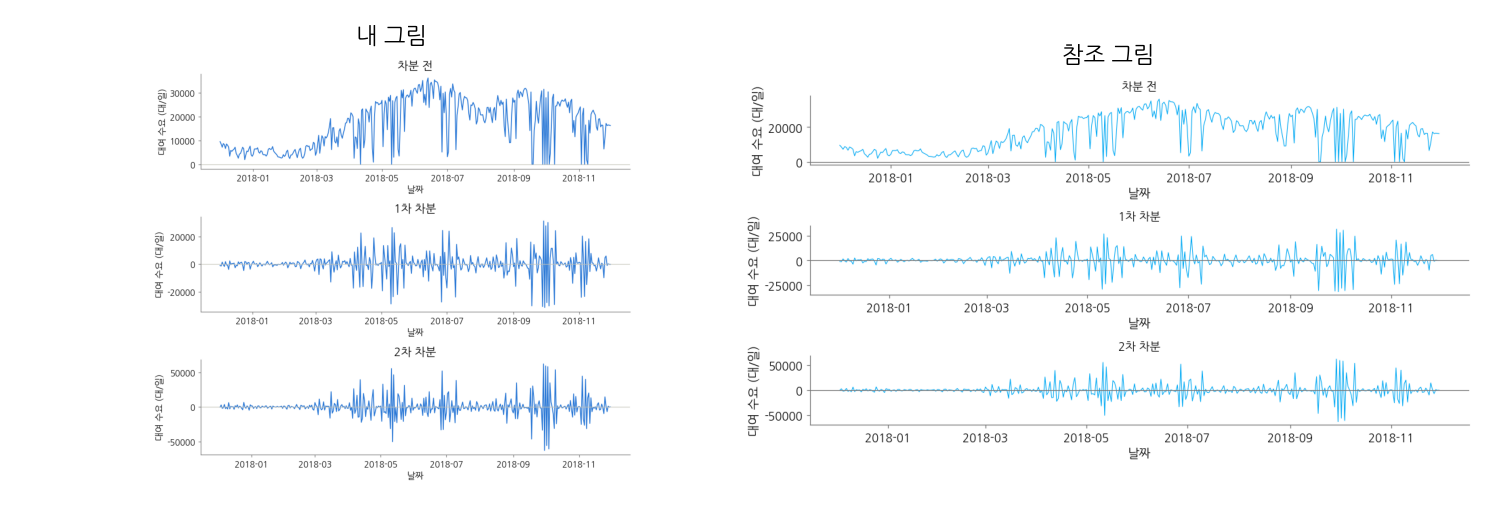

In [9]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
지금까지 오면서 계절성은 시각에 있었고, 계열은 24시간 계절차분 1회로 예측 모형에 쓸 수 있는 상태가 되었어 이제는 하루 단위 계열은 몇 회 차분해야 하고, 배치 기준은 무엇으로 삼아야 하는지를 정해야해 

먼저 아래 변수들은 다 만들어져 있으니까 만들필요가 없어

* `daily_c`	일 수요 365일, 단위 대/일. 미션 1 의 daily 와 같은 계열입니다
* `ALPHA`	유의수준
* `autocorr(계열, 시차)`	그 시차의 자기상관 한 값을 반환하는 함수
* `acf · adfuller · kpss`	자기상관과 두 검정을 부르는 함수


그리고 아래 7개를 만들어줘 `—` 왼쪽에 있는게 출력 행 이름이야

1. 일 계열 1차 차분 — 시차 1 자기상관	레벨 차분 1회 계열의 시차 1 자기상관	무차원 · 소수점 아래 4자리
2.  계열 1차 차분 — 표준편차	같은 계열의 표준편차	대/일 · 소수점 아래 1자리	
3.  차분 전 일 계열 — KPSS 통계량	차분 전 일 계열에 적용한 반환값 첫 값	무차원 · 소수점 아래 4자리	
4. 1차 차분 일 계열 — KPSS 통계량	레벨 차분 1회 계열에 적용한 같은 값	무차원 · 소수점 아래 4자리	
5. 차분 전 일 계열 — ADF 검정통계량	차분 전 일 계열에 적용한 반환값 첫 값	무차원 · 소수점 아래 4자리	
6. 1차 차분 일 계열 — ADF 검정통계량	레벨 차분 1회 계열에 적용한 같은 값	무차원 · 소수점 아래 4자리	
7. 2차 차분 일 계열 — 표준편차와 시차 1 자기상관	레벨 차분 2회 계열의 두  값을 한 행에 	대/일 소수점 아래 1자리 · 자기상관 소수점 아래 4자리

마지막은 그래프 한장이야. 패널 3개 — 세 패널 모두 가로축은 날짜, 세로축은 대여 수요인 선 그래프
- 패널은 위에서부터 「차분 전」 · 「1차 차분」 · 「2차 차분」 이고 제목도 그대로 답니다
- 패널마다 계열 하나와 0 에 그은 가로선 하나를 두고, 가로축 이름은 「날짜」, 세로축 이름은 「대여 수요 (대/일)」 입니다
"""
# --- 여기부터 AI 코드 ---
# ── 일 계열 차분 계열 만들기 ─────────────────────────────────
daily_diff1 = daily_c.diff(1).dropna()       # 레벨 차분 1회
daily_diff2 = daily_diff1.diff(1).dropna()   # 레벨 차분 2회 (1차 차분을 한 번 더)

# 1. 일 계열 1차 차분 — 시차 1 자기상관
acf1_diff1 = autocorr(daily_diff1, 1)
print(f"일 계열 1차 차분 — 시차 1 자기상관 = {acf1_diff1:.4f}")

# 2. 일 계열 1차 차분 — 표준편차
std_diff1 = daily_diff1.std()
print(f"일 계열 1차 차분 — 표준편차 = {std_diff1:.1f} 대/일")

# 3. 차분 전 일 계열 — KPSS 통계량
kpss_before = kpss(daily_c, regression="c", nlags="auto")[0]
print(f"차분 전 일 계열 — KPSS 통계량 = {kpss_before:.4f}")

# 4. 1차 차분 일 계열 — KPSS 통계량
kpss_diff1 = kpss(daily_diff1, regression="c", nlags="auto")[0]
print(f"1차 차분 일 계열 — KPSS 통계량 = {kpss_diff1:.4f}")

# 5. 차분 전 일 계열 — ADF 검정통계량
adf_before = adfuller(daily_c, autolag="AIC")[0]
print(f"차분 전 일 계열 — ADF 검정통계량 = {adf_before:.4f}")

# 6. 1차 차분 일 계열 — ADF 검정통계량
adf_diff1 = adfuller(daily_diff1, autolag="AIC")[0]
print(f"1차 차분 일 계열 — ADF 검정통계량 = {adf_diff1:.4f}")

# 7. 2차 차분 일 계열 — 표준편차와 시차 1 자기상관 (한 행)
std_diff2 = daily_diff2.std()
acf1_diff2 = autocorr(daily_diff2, 1)
print(f"2차 차분 일 계열 — 표준편차와 시차 1 자기상관 = {std_diff2:.1f} 대/일, {acf1_diff2:.4f}")

# ── 그래프 — 패널 3개(차분 전 · 1차 차분 · 2차 차분) ─────────────
선색 = "#2a78d6"
기준선색 = "#c3c2b7"

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=False)

for ax, y, title in (
    (axes[0], daily_c, "차분 전"),
    (axes[1], daily_diff1, "1차 차분"),
    (axes[2], daily_diff2, "2차 차분"),
):
    ax.plot(y.index, y.values, color=선색, lw=1.2)
    ax.axhline(0, color=기준선색, lw=0.8)
    ax.set_xlabel("날짜")
    ax.set_ylabel("대여 수요 (대/일)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

근거를 무엇으로 쓰는지는 위의 「배경 — 브리핑 결론의 근거인 계절 강도 2개」에 있습니다.

**브리핑 세 문장** — 아래 세 문장을 이 셀에 그대로 채워 제출합니다. 채점을 받기 전에 내 출력만 보고 먼저 채우고, 열린 완성본과 비교해 어긋난 곳만 수정합니다.

> **결론**: 배치 기준은 시각(하루 24시간 단위의 시간대별 패턴)입니다. 미션 1 이 측정한 계절 강도가 8월 744시간의 주기 24에서 0.6478(64.8%), 1년 365일 일 수요의 주기 7에서 **0.0894(8.9%)**로 나온 것이 근거입니다. 측정 구간이 달라 두 값을 나누어 배수로 읽지는 않습니다. 시각 프로파일 최고 18시 1,503대/시간에 이르기 전에 트럭을 배치합니다.
>
> **위험**: 1차 차분에서 2차 차분으로 한 번 더 차분하면 표준편차가 8,622.4대/일에서 14,931.6대/일로 오히려 커지고 시차 1 자기상관도 −0.4953에서 −0.6969로 더 음수 쪽으로 움직여 과차분의 신호를 보이는데, ADF·KPSS는 "단위근이 남았는가"만 판정할 뿐 "너무 많이 뺐는가"는 판정하지 못하므로 검정 결과만으로는 이 위험을 잡아내지 못합니다.
>
> 휴무 295시간은 실제 수요가 0이었던 게 아니라 운행을 하지 않아 기록 자체가 없는 시간이라, 그대로 0으로 두면 그 시각의 평균이 실제보다 낮게 왜곡됩니다. 삭제하면 1시간 간격이 깨지고 0 유지는 진짜 수요를 과소평가하므로, 시각별 프로파일이 실제 수요 패턴을 반영하도록 보정을 택했습니다.
>
> 시각별 프로파일은 1년 전체를 평균한 값이라 다음 주의 계절·강수 조건에 따라 실제 수준이 크게 달라질 수 있습니다 — 비가 온 528시간의 평균은 163.5대/시간, 비가 오지 않은 8,232시간의 평균은 739.3대/시간으로 4배 넘게 차이가 나고, 정점 시각(18시)의 관측값조차 자전거 품절 때문에 실제 수요의 아래쪽 경계일 뿐이라 진짜 수요는 이보다 더 클 수 있습니다.
>
> **코드가 답을 만드는 방식**: .diff(1)은 바로 하루 전 값을 빼 레벨 차분 계열을 만들고 .dropna()는 그 뺄셈으로 생긴 첫 행의 결측치를 제거하며, 시차 1 자기상관과 ADF·KPSS는 차분 전 일 계열(daily_c)·1차 차분 계열(daily_diff1)·2차 차분 계열(daily_diff2)에 각각 그대로 적용해 계산했습니다.

## 5. 오늘의 정리와 둘째 날로 전달할 설정값

## 오늘의 정리

수요예측 담당자로서 보낸 첫날을 마칩니다. 팀장이 물은 두 가지에 한 문장으로 답하면 **계절성은 요일이 아니라 시각에 있고, 계열은 24시간 계절차분을 1회 적용해야 예측 모형에 쓸 수 있습니다.**

| 오늘의 질문 | 오늘 얻은 답 |
|---|---|
| 다음 주 배치를 요일에 둘까 시각에 둘까 | 시각입니다. 근거는 이론의 「4. 계절 강도: 주기 24와 주기 7의 비교」가 1년 구간에서 측정한 주기 24 의 0.572 와 주기 7 의 0.089 이고, 주기 24 는 추세를 제외한 변동의 절반을 넘게 설명하는 한편 주기 7 은 0.1 에 못 미칩니다. 오늘 실습의 0.6478 은 휴무가 없는 8월 744시간으로 좁혀 측정한 값이고, 일 수요 쪽 0.0894 는 이론과 같은 1년 365일에서 측정한 값입니다 |
| 이 계열을 그대로 예측 모형에 쓸 수 있나 | 쓸 수 없습니다. ADF −6.9470 과 KPSS 8.0051 이 **둘 다 기각** 이므로 수준은 정상인데 다른 구조가 남았다는 뜻입니다 |
| 그러면 어떤 처리가 필요한가 | 레벨 차분이 아니라 **24시간 계절차분 1회**(D = 1)입니다. 적용한 뒤 KPSS 가 임계값 아래로 내려가고 시차 24 자기상관이 양수에서 음수로 바뀌어야 효과가 있었다는 뜻입니다 |
| 하루 단위 계열은 몇 회 차분하나 | 레벨 차분 1회입니다. 한 번 더 차분하면 표준편차가 오히려 커지고 시차 1 자기상관이 더 음수로 내려갑니다. 이것이 과차분의 두 신호입니다(과제) |

미션 2 의 함정은 두 검정의 **귀무가설이 서로 반대**라는 것이었습니다. 같은 `p값 < ALPHA` 를 같은 방향으로 읽으면 결론이 정확히 반대가 되고, 실행이 멈추지 않는 종류의 오류라 **값이 아니라 방향을 판정 문구에 명시하는 것**이 유일한 예방책이었습니다.

## 둘째 날 예고 — 다음 7일 168시간을 숫자로

둘째 날에는 오늘 정상성을 확보한 이 계열 위에 첫 예측 모형(ARIMA · SARIMA)을 적합해, 운영팀이 기다리는 **다음 7일 168시간**을 실제 숫자로 만듭니다. 둘째 날 「준비 셀」이 오늘과 같은 주소에서 같은 계열을 다시 만든 상태로 시작합니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/h02f-1.png" width="640" height="320"/>
<p align="center"><em>▲ 둘째 날 결과물의 형태 — 검은 선은 관측된 월별 약품 판매액, 오른쪽 끝 파란 선이 계절 ARIMA 모형의 예측이고, 그 선을 가운데 둔 진한 영역이 80% · 옅은 영역이 95% 예측구간이다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3판, 9.9 Seasonal ARIMA models)</em></p>

오늘 남긴 세 값이 그대로 둘째 날의 설정값이 됩니다. 계절 주기 m 은 계절 강도가 정한 24, 계절차분 횟수 D 는 오늘의 검정이 정한 1, 레벨 차분 횟수 d 는 ADF 가 단위근 가설을 기각했으므로 0 입니다. 남은 것은 자기회귀 차수와 이동평균 차수 둘뿐이고, 그 둘을 고르는 것이 둘째 날의 일입니다. 세 값은 1년 8,760시간 전체에서 측정한 것이라, 실무에서는 검증 구간을 떼어 낸 학습 구간에서 정하고 둘째 날 분할 뒤 학습 구간에서 같은 판정을 한 번 더 확인합니다.

오늘 계열을 정상으로 만든 것은 **모형에 쓸 준비가 되었다**는 뜻이지 **예측이 해결되었다**는 뜻이 아닙니다. 계절차분을 적용하고도 시차 24 의 자기상관이 판정선 바깥쪽에 음수로 남아 있었습니다. 그 남은 구조를 둘째 날 자기회귀 항과 이동평균 항이 설명합니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/usemployment5-1.png" width="640" height="384"/>
<p align="center"><em>▲ 모형을 만든 뒤 잔차로 하는 검사 — 위는 잔차를 시간 순으로, 아래 왼쪽은 잔차의 자기상관, 오른쪽은 잔차의 히스토그램이다. 잔차 막대가 파란 판정선 안쪽에 있으면 남은 구조가 없다는 뜻이다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3판, 9.9 Seasonal ARIMA models)</em></p>

마무리는 두 문장으로 합니다. 오늘 채점이 열어 준 완성본과 내 코드가 달랐던 곳 한 군데를 한 문장으로 쓰고, 거기에서 무엇을 배웠는지를 한 문장으로 적습니다. 그 두 문장을 팀 채널에 공유하고 다른 사람의 두 문장을 읽는 것으로 오늘 복습을 마칩니다. 함께 볼 팀이 없다면 둘째 날의 나에게 남기는 메모로 적어 두어도 효과는 같습니다.

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:16px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 8px 0">수고했습니다 — 시계열 첫날 완료</h2>
<div style="color:#656565">8,760시간에서 두 계절 주기의 크기를 측정하고, 두 검정으로 계열의 정상성을 판정하고, 계절차분의 효과까지 확인했습니다.<br/>둘째 날에는 이 계열 위에 첫 예측 모형을 만듭니다.</div>
</div>

> **[문제] 정상성을 확보했으면 예측 준비가 끝난 것인가**
>
> 오늘 24시간 계절차분을 1회 적용하자 두 검정이 정상 쪽에서 합의했습니다. 그런데 같은 차분 계열에서도 시차 24 의 자기상관은 크기 0.4 를 넘는 음수로 남았고, 미션 1 이 8월 744시간에서 측정한 주기 24 계절 강도는 0.6478 이었습니다. (가) "정상성을 확보했으니 예측 준비가 끝났다" 는 문장의 어디가 과한지, (나) 차분한 뒤에도 남아 있는 그 자기상관이 둘째 날 무엇을 설명하는 구조가 되는지, (다) 둘째 날 모형에 전달할 계절 주기 m 을 24 로 정한 근거가 어느 숫자였는지 세 문장으로 적어 보세요.